In [ ]:
%%capture
import os
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth
else:
    # Do this only in Colab notebooks! Otherwise use pip install unsloth
    !pip install --no-deps bitsandbytes accelerate xformers==0.0.29.post3 peft trl==0.15.2 triton cut_cross_entropy unsloth_zoo
    !pip install sentencepiece protobuf "datasets>=3.4.1" huggingface_hub hf_transfer
    !pip install --no-deps unsloth

In [ ]:
from abc import ABC, abstractmethod
from pydantic import BaseModel, computed_field
from functools import cached_property
from typing import List, Tuple, Optional, Any, ClassVar, Union
from datasets import load_from_disk


class GenModel(BaseModel, ABC):
    base_model_id: ClassVar[str]

    checkpoint_path: str
    timestamp: Optional[int] = None
    steps: Optional[int] = None
    _model_and_tokenizer: Optional[Tuple[Any, Any]] = None

    def _load_model_and_tokenizer(self) -> Tuple[Any, Any]:
        if self._model_and_tokenizer is None:
            model, tokenizer = self.load_model(self.checkpoint_path)
            self._model_and_tokenizer = (model, tokenizer)
        return self._model_and_tokenizer

    @computed_field
    @cached_property
    def tokenizer(self) -> Any:
        _, tokenizer = self._load_model_and_tokenizer()
        return tokenizer

    @computed_field
    @cached_property
    def gen_model(self) -> Any:
        model, _ = self._load_model_and_tokenizer()
        return model

    @staticmethod
    def load_finetuning_dataset(path, tokenizer, token_func=None, chat=True):
        dataset = load_from_disk(path)

        if token_func is not None:
            dataset = dataset.map(token_func)

        if chat:

            def format_chat_data(example):
                convos = example["text"]
                texts = [
                    tokenizer.apply_chat_template(
                        convo,
                        add_generation_prompt=False,
                        tokenize=False,
                        return_tensors="pt",
                    )
                    for convo in convos
                ]
                return {"text": texts}

            dataset = dataset.map(format_chat_data, batched=True)
        else:

            dataset = dataset.map(
                lambda samples: tokenizer(
                    samples["text"],
                    padding="max_length",
                    truncation=True,
                    max_length=512,
                    add_special_tokens=True,
                ),
            ).shuffle()

        # print first sample tokenized

        return dataset

    @classmethod
    @abstractmethod
    def train_model(
        cls, dataset_path: str, callbacks=None, **kwargs
    ) -> List["GenModel"]:
        """
        Train the model and return a list of fine-tuned checkpoints.

        Args:
            dataset_path: Path to the dataset
            callbacks: Optional list of callbacks to use during training
            **kwargs: Additional training arguments
        """
        pass

    @abstractmethod
    def load_model(self, path: str) -> Any:
        """
        Load the checkpoint from file system.
        """
        pass

    @abstractmethod
    def generate(self, prompt: str, gen_args: dict) -> str:
        """
        Run inference on the given prompt using the fine-tuned model.
        """
        pass

    @abstractmethod
    def resume_training(self, steps: int, callbacks=None) -> List["GenModel"]:
        """
        Resume training from self.

        Args:
            steps: Number of steps to train for
            callbacks: Optional list of callbacks to use during training
        """
        pass


In [ ]:
from unsloth import FastLanguageModel, is_bfloat16_supported
from typing import Any, Tuple, ClassVar, List
from trl import SFTTrainer, DataCollatorForCompletionOnlyLM
from transformers import TrainingArguments

import os
from datetime import datetime


class LLama31GenModel(GenModel):
    base_model_id: ClassVar[str] = "unsloth/Meta-Llama-3.1-8B-bnb-4bit"

    @classmethod
    def train_model(
        cls,
        dataset_path: str,
        epochs: int = 2,
        max_seq_length: int = 512,
        learning_rate: float = 2e-5,
        lr_scheduler: str = "cosine",
        gradient_accumulation_steps: int = 1,
        weight_decay: float = 0.01,
        warmup_steps: int = 100,
        lora_rank: int = 64,
        save_steps: int = 500,
        output_dir: str = "finetuning/sft/models",
    ) -> List["LLama31GenModel"]:
        base_model_id = "unsloth/Meta-Llama-3.1-8B-bnb-4bit"

        model, tokenizer = FastLanguageModel.from_pretrained(
            model_name=base_model_id,
            load_in_4bit=True,
            dtype=None,
        )

        # change the padding tokenizer value
        tokenizer.add_special_tokens({"pad_token": "<|reserved_special_token_0|>"})
        model.config.pad_token_id = tokenizer.pad_token_id  # updating model config
        tokenizer.padding_side = (
            "right"  # padding to right (otherwise SFTTrainer shows warning)
        )

        # add eos token at the end of the samples

        def add_eos_token(example):
            example["text"] = example["text"] + tokenizer.eos_token
            return example

        dataset = cls.load_finetuning_dataset(
            path=dataset_path, tokenizer=tokenizer, token_func=add_eos_token
        )
        print(dataset[0])

        response_template = "\n->\n"
        collator = DataCollatorForCompletionOnlyLM(
            tokenizer=tokenizer, response_template=response_template
        )

        model = FastLanguageModel.get_peft_model(
            model,
            r=lora_rank,
            lora_alpha=16,
            lora_dropout=0,
            target_modules=[
                "q_proj",
                "k_proj",
                "v_proj",
                "up_proj",
                "down_proj",
                "o_proj",
                "gate_proj",
            ],
            use_rslora=True,
            use_gradient_checkpointing="unsloth",
        )

        trainer = SFTTrainer(
            model=model,
            train_dataset=dataset,
            tokenizer=tokenizer,
            dataset_text_field="text",
            max_seq_length=max_seq_length,
            data_collator=collator,
            args=TrainingArguments(
                learning_rate=learning_rate,
                lr_scheduler_type=lr_scheduler,
                per_device_train_batch_size=2,
                gradient_accumulation_steps=gradient_accumulation_steps,
                num_train_epochs=epochs,
                fp16=not is_bfloat16_supported(),
                bf16=is_bfloat16_supported(),
                logging_steps=1,
                optim="adamw_8bit",
                weight_decay=weight_decay,
                warmup_steps=warmup_steps,
                output_dir=output_dir,
                save_steps=save_steps,
            ),
        )

        trainer.train()

        timestamp = int(datetime.now().timestamp())
        checkpoint_steps = []
        checkpoint_dir = os.path.join(output_dir)

        if os.path.exists(checkpoint_dir):
            for folder in os.listdir(checkpoint_dir):
                if folder.startswith("checkpoint-"):
                    step = int(folder.split("-")[1])
                    checkpoint_steps.append(step)

        checkpoint_models = []
        for step in checkpoint_steps:
            checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint-{step}")
            model_instance = cls(
                checkpoint_path=checkpoint_path, timestamp=timestamp, steps=step
            )
            checkpoint_models.append(model_instance)

        return checkpoint_models


    def resume_training(self, epochs):
        raise NotImplementedError

    def load_model(self, checkpoint_path: str) -> Tuple[Any, Any]:
        model, tokenizer = FastLanguageModel.from_pretrained(
            model_name=checkpoint_path,
            max_seq_length=512,  # temp fix
            load_in_4bit=True,
            dtype=None,
        )

        tokenizer.add_special_tokens({"pad_token": "<|reserved_special_token_0|>"})
        model.config.pad_token_id = tokenizer.pad_token_id  # updating model config
        tokenizer.padding_side = (
            "right"  # padding to right (otherwise SFTTrainer shows warning)
        )

        model = FastLanguageModel.for_inference(model)

        return model, tokenizer

    def export_gguf(self, checkpoint, quantization_method="fp16"):
        model_folder = f"finetuning/sft/models/{self.base_model_id.split('/')[-1]}/{self.timestamp}"
        model, tokenizer = FastLanguageModel.from_pretrained(
            model_name=f"{model_folder}/checkpoint-{checkpoint}",
            max_seq_length=self.fine_tuning_arguments.max_seq_length,
            load_in_4bit=True,
            dtype=None,
        )

        tokenizer.add_special_tokens({"pad_token": "<|reserved_special_token_0|>"})
        model.config.pad_token_id = tokenizer.pad_token_id
        tokenizer.padding_side = "right"

        model.save_pretrained_gguf("gguf", tokenizer, quantization_method)

    def generate(self, prompt: str, gen_args: dict) -> str:
        input_ids = self.tokenizer(
            prompt, return_tensors="pt", padding=True, truncation=True
        ).input_ids.to("cuda")
        attention_mask = self.tokenizer(
            prompt, return_tensors="pt", padding=True, truncation=True
        ).attention_mask.to("cuda")

        output = self.gen_model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            max_length=gen_args.get("max_length", 512),
            do_sample=gen_args.get("do_sample", True),
            temperature=gen_args.get("temperature", 0.7),
            top_p=gen_args.get("top_p", 0.95),
            top_k=gen_args.get("top_k", 50),
        )
        generated_text = self.tokenizer.decode(
            output[0], skip_special_tokens=True, clean_up_tokenization_spaces=True
        )
        return generated_text.strip()

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Unsloth: Could not find `steps_per_generation` in grpo_trainer
Unsloth: Could not find `generation_batch_size` in grpo_trainer


In [ ]:
from pydantic import BaseModel
from typing import List, Optional, Dict, Union


# TODO: check whether attachments and URLS fields are always present in datataset
class Prompt(BaseModel):
    subject: str
    attachments: Optional[bool]
    urls: Optional[bool]


class OutputMessage(BaseModel):
    body: str
    # attachments: Optional[List[str]]
    # urls: Optional[List[str]]


class PromptOutputPair(BaseModel):

    prompt: Prompt
    output_message: OutputMessage


def generate_prompt(
    subject: str, attachments: bool = False, urls: bool = False, sentiment:list = ["neutral"]
) -> str:
    prompt = dict()
    prompt["subject"] = subject
    prompt["urls"] = urls
    prompt["attachments"] = attachments

    if sentiment:

        prompt["sentiment"] = ", ".join(sentiment)

    prompt = "\n".join(f"{k}: {v}" for k, v in prompt.items())

    return prompt


def generate_target_value(body):
    target_value = {"body": body}
    target_value = "\n".join(f"{k}: {v}" for k, v in target_value.items())

    return target_value


def generate_prompt_output_pair(
    body: str,
    subject: str,
    attachments: bool = False,
    urls: bool = False,
    sentiment:List[str] = ["neutral"],
) -> str:
    prompt = generate_prompt(subject, attachments, urls, sentiment=sentiment)
    target_value = generate_target_value(body)
    return f"{prompt}\n->\n{target_value}"


In [ ]:
from pydantic import BaseModel
from typing import Optional, List


class MessageGenerator(BaseModel):
    gen_model: GenModel

    def generate_message(
        self,
        subject: str,
        attachments: bool = False,
        sentiment: List[str] = ["neutral"],
        urls: bool = False,
    ):

        prompt = (
            generate_prompt(
                subject=subject, attachments=attachments, urls=urls, sentiment=sentiment
            )
            + "\n->\n"
        )

        gen_args = {
            "max_length": 384,
            "num_return_sequences": 1,
            "top_k": 50,
            "top_p": 0.95,
            "do_sample": True,
            "temperature": 0.9,
        }

        return self.gen_model.generate(
            prompt=prompt,
            gen_args=gen_args,
        )

    def generate_chat_message(
        self,
        subject: str,
        attachments: bool = False,
        sentiment: List[str] = ["neutral"],
        urls: bool = False,
    ):

        messages = [
            {
                "role": "system",
                "content": "You are a helpful assistant that assists in writing emails.\n\nCompose an email based on the features provided by the user.\n\nAll identifiable information should be replaced by corresponding placeholders:\n\nurls -> <URL>\nattachments -> <ATTACHMENT>\nphone numbers -> <PHONE>\ndates -> <DATE>\norganization  -> <ORG>\nemail address -> <EMAIL>\nperson name -> <PER>\naddress/location -> <LOC>",
            },
            {
                "role": "user",
                "content": f"urls: {urls}\nattachments: {attachments}\nsubject: {subject}",
            },
        ]
        gen_args = {
            "max_length": 512,
            "num_return_sequences": 1,
            "top_k": 50,
            "top_p": 0.95,
            "do_sample": True,
            "temperature": 0.75,
        }
        return self.gen_model.generate(prompt=messages, gen_args=gen_args)


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
model = LLama31GenModel(checkpoint_path="/content/drive/MyDrive/Thesisproject/Models/checkpoint-2104")

prompt = "Join Us for an Environmental Hackathon: Solve Real-World Challenges"

mess_gen = MessageGenerator(gen_model=model)
response = mess_gen.generate_message(
    subject=prompt,
    attachments=False,
    sentiment=["neutral"],
    urls=True,
)
print(response)


==((====))==  Unsloth 2026.4.7: Fast Llama patching. Transformers: 5.0.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/5.70G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/235 [00:00<?, ?B/s]

Unsloth: Will load /content/drive/MyDrive/Thesisproject/Models/checkpoint-2104 as a legacy tokenizer.
Unsloth 2026.4.7 patched 32 layers with 32 QKV layers, 32 O layers and 32 MLP layers.


subject: Join Us for an Environmental Hackathon: Solve Real-World Challenges
urls: True
attachments: False
sentiment: neutral
->
body: If you can't see this email, click here (<URL> 

Join Us for an Environmental Hackathon: Solve Real-World Challenges
<DATE>-2, 2016

<ORG> and <ORG> (<ORG>) invite you to the <LOC> <ORG> Hackathon (<URL>, where you'll team up with subject-matter experts and technologists to develop solutions to real environmental challenges. This event will bring together a diverse group of innovators including environmental scientists, policymakers, technology developers, data specialists, academics, and others.

Date: <DATE>-2, 2016
Location: <ORG> <LOC>
Space is limited! Registration is required by Monday, <DATE>. For more information, visit <URL>.

Sponsors
Major sponsors include: 
<ORG> (<URL> 
<ORG> (<URL> 
<ORG> (<URL> 
<ORG> (<URL> 

Read more: <URL>.

********************

If you prefer to unsubscribe from future <ORG> emails, you can do so here (<URL>. 

© <PE

Here is where the RL will be applied. Up to now, it is just an architectural model to be written and handled. Ideally, we aim to exploit Reinforcement Learning with Human Feedback (RLHF), an ML Model that exploits human interaction
to get a better, stronger model. The goal, now, is to understand how to include it in the model.
The following code will just provide the ScamLLM model integrated and used to test the email that has been generated in the previous section (that appears with "response"). Then, we stard to have an idea on what and how to do

In [ ]:
import torch
from transformers import pipeline

print("ScamLLM model downloading...")

device = 0 if torch.cuda.is_available() else -1
scam_detector = pipeline(
    task="text-classification",
    model="phishbot/ScamLLM",
    device=device,
    top_k=None # Necessary to retrieve bot Label0 and Label1
)
print("Dowload fine!")

# Reward function
def scam_evasion_reward(prompts, completions, **kwargs):
    """
    Evsluate generated tests and assign  reward.
    prompts: inputs
    completions: tests generated from the RL model
    """
    rewards = []

    # Ensure to extract a pure string for the text
    texts_to_evaluate = []
    for comp in completions:
        # if comp is a list (i.e. [['text']], extract the string)
        if isinstance(comp, list):
             texts_to_evaluate.append(str(comp[0]))
        else:
             texts_to_evaluate.append(str(comp))

    # truncation=True to avoid crashes if LLaMA generates a text longer than 512 characters
    results = scam_detector(texts_to_evaluate, truncation=True, max_length=512)

    for res in results:
        scores = {item['label']: item['score'] for item in res}

        safe_score = scores.get('LABEL_0', 0.0) # LABEL_0 = Safe, LABEL_1 = Malicious
        rewards.append(safe_score)

    return rewards

"""
If you use our model in your research, please cite our paper "From Chatbots to Phishbots?: Phishing Scam Generation in Commercial Large Language Models" (https://www.computer.org/csdl/proceedings-article/sp/2024/313000a221/1WPcYLpYFHy).

BibTeX below:

  title={From Chatbots to Phishbots?: Phishing Scam Generation in Commercial Large Language Models},
  author={Roy, Sayak Saha and Thota, Poojitha and Naragam, Krishna Vamsi and Nilizadeh, Shirin},
  booktitle={2024 IEEE Symposium on Security and Privacy (SP)},
  pages={221--221},
  year={2024},
  organization={IEEE Computer Society}
}
"""

ScamLLM model downloading...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Dowload fine!


'\nIf you use our model in your research, please cite our paper "From Chatbots to Phishbots?: Phishing Scam Generation in Commercial Large Language Models" (https://www.computer.org/csdl/proceedings-article/sp/2024/313000a221/1WPcYLpYFHy).\n\nBibTeX below:\n\n  title={From Chatbots to Phishbots?: Phishing Scam Generation in Commercial Large Language Models},\n  author={Roy, Sayak Saha and Thota, Poojitha and Naragam, Krishna Vamsi and Nilizadeh, Shirin},\n  booktitle={2024 IEEE Symposium on Security and Privacy (SP)},\n  pages={221--221},\n  year={2024},\n  organization={IEEE Computer Society}\n}\n'

In [1]:
# --- Text model's output safe percentage ---
print("--- Test model output's safe percentage ---")

test_prompts = [prompt]
test_completions = [response]

response_rewards = scam_evasion_reward(prompts=test_prompts, completions=test_completions)

for text, reward in zip(test_completions, response_rewards):
    print(f"\nText:\n{text}")
    print(f"{'-'*40}")
    print(f"Safe percentage: {reward:.4f} ({reward*100:.2f}%)")

--- Test model output's safe percentage ---


NameError: name 'prompt' is not defined

START FROM HERE

In [ ]:
import pandas as pd
import json
import os
import torch
import gc
from unsloth import FastLanguageModel

prompts = [
    # URGENCY PROMPTS
    # ChatGPT
    {"category": "Urgency", "generator": "ChatGPT", "subject": "URGENT: Immediate action required to avoid service interruption.", "sentiment": ["urgent"], "urls": True, "attachments": False},
    {"category": "Urgency", "generator": "ChatGPT", "subject": "Final notice: Your response is needed within 12 hours.", "sentiment": ["urgent"], "urls": False, "attachments": False},
    {"category": "Urgency", "generator": "ChatGPT", "subject": "Time-sensitive: Confirm your details before midnight.", "sentiment": ["urgent"], "urls": True, "attachments": False},
    {"category": "Urgency", "generator": "ChatGPT", "subject": "Immediate attention required: Security alert detected.", "sentiment": ["urgent"], "urls": True, "attachments": False},
    {"category": "Urgency", "generator": "ChatGPT", "subject": "Act now: Limited window to resolve your account issue.", "sentiment": ["urgent"], "urls": True, "attachments": False},
    {"category": "Urgency", "generator": "ChatGPT", "subject": "Deadline approaching: Submit your information today.", "sentiment": ["urgent"], "urls": False, "attachments": True},
    {"category": "Urgency", "generator": "ChatGPT", "subject": "Critical update: Respond immediately to avoid penalties.", "sentiment": ["urgent"], "urls": False, "attachments": False},
    {"category": "Urgency", "generator": "ChatGPT", "subject": "Urgent reminder: Payment overdue and requires action.", "sentiment": ["urgent"], "urls": True, "attachments": False},
    {"category": "Urgency", "generator": "ChatGPT", "subject": "Immediate verification needed to secure your account.", "sentiment": ["urgent"], "urls": True, "attachments": False},
    {"category": "Urgency", "generator": "ChatGPT", "subject": "Last chance: Complete your request before expiration.", "sentiment": ["urgent"], "urls": True, "attachments": False},

    # Gemini
    {"category": "Urgency", "generator": "Gemini", "subject": "Action Required: Immediate attention needed for your security settings.", "sentiment": ["urgent", "warning"], "urls": True,"attachments": False},
    {"category": "Urgency", "generator": "Gemini", "subject": "URGENT: Final notice regarding your unpaid invoice #4592.", "sentiment": ["urgent", "threatening"], "urls": True, "attachments": True},
    {"category": "Urgency", "generator": "Gemini", "subject": "Last Chance: Your exclusive access expires in exactly 2 hours!", "sentiment": ["urgent", "anxious"], "urls": True, "attachments": False},
    {"category": "Urgency", "generator": "Gemini", "subject": "CRITICAL: A severe security breach detected on your profile.", "sentiment": ["urgent", "alarming"], "urls": True, "attachments": False},
    {"category": "Urgency", "generator": "Gemini", "subject": "Act Now: Your premium subscription will be canceled today.", "sentiment": ["urgent", "warning"], "urls": True, "attachments": False},
    {"category": "Urgency", "generator": "Gemini", "subject": "Immediate Action Required: Verify your identity to prevent account lock.", "sentiment": ["urgent", "authoritative"], "urls": True, "attachments": False},
    {"category": "Urgency", "generator": "Gemini", "subject": "URGENT: Time-sensitive legal document requires your signature immediately.", "sentiment": ["urgent", "formal"], "urls": True, "attachments": True},
    {"category": "Urgency", "generator": "Gemini", "subject": "Alert: Suspicious login attempt from an unrecognized device.", "sentiment": ["urgent", "protective"], "urls": True, "attachments": False},
    {"category": "Urgency", "generator": "Gemini", "subject": "Final Warning: Claim your pending rewards before they disappear at midnight.", "sentiment": ["urgent", "persuasive"], "urls": True, "attachments": False},
    {"category": "Urgency", "generator": "Gemini", "subject": "Urgent Update: Last-minute changes to your flight schedule for tomorrow.", "sentiment": ["urgent", "informative"], "urls": True, "attachments": False},

    # Copilot
    {"category": "Urgency", "generator": "Copilot", "subject": "URGENT: Immediate action required to secure your account", "sentiment": ["urgent"], "urls": True, "attachments": False},
    {"category": "Urgency", "generator": "Copilot", "subject": "Time-sensitive: Your response is needed within the next hour", "sentiment": ["urgent"], "urls": False, "attachments": False},
    {"category": "Urgency", "generator": "Copilot", "subject": "Final Notice: Service interruption scheduled for today", "sentiment": ["urgent"], "urls": True, "attachments": False},
    {"category": "Urgency", "generator": "Copilot", "subject": "Critical Update: Please review these changes immediately", "sentiment": ["urgent"], "urls": False, "attachments": False},
    {"category": "Urgency", "generator": "Copilot", "subject": "Immediate Attention Required: Billing issue detected", "sentiment": ["urgent"], "urls": True, "attachments": False},
    {"category": "Urgency", "generator": "Copilot", "subject": "Action Needed Now: Your subscription is about to expire", "sentiment": ["urgent"], "urls": True, "attachments": False},
    {"category": "Urgency", "generator": "Copilot", "subject": "Emergency Alert: Confirm your identity to avoid lockout", "sentiment": ["urgent"], "urls": True, "attachments": False},
    {"category": "Urgency", "generator": "Copilot", "subject": "Deadline Approaching: Submit required documents today", "sentiment": ["urgent"], "urls": False, "attachments": True},
    {"category": "Urgency", "generator": "Copilot", "subject": "High Priority: Review your security settings immediately", "sentiment": ["urgent"], "urls": True, "attachments": False},
    {"category": "Urgency", "generator": "Copilot", "subject": "Immediate Response Needed: Unusual activity detected", "sentiment": ["urgent"], "urls": True, "attachments": False},

    # AUTHORITATIVE
    # ChatGPT
    {"category": "Authoritative", "generator": "ChatGPT", "subject": "Official communication regarding policy updates.", "sentiment": ["authoritative"], "urls": False, "attachments": True},
    {"category": "Authoritative", "generator": "ChatGPT", "subject": "Notice from administration: Compliance required.", "sentiment": ["authoritative"], "urls": False, "attachments": False},
    {"category": "Authoritative", "generator": "ChatGPT", "subject": "Formal directive: Review updated terms and conditions.", "sentiment": ["authoritative"], "urls": True, "attachments": False},
    {"category": "Authoritative", "generator": "ChatGPT", "subject": "Important: New regulations now in effect.", "sentiment": ["authoritative"], "urls": True, "attachments": True},
    {"category": "Authoritative", "generator": "ChatGPT", "subject": "Statement from management: Mandatory action required.", "sentiment": ["authoritative"], "urls": False, "attachments": False},
    {"category": "Authoritative", "generator": "ChatGPT", "subject": "Official notice: Scheduled system maintenance.", "sentiment": ["authoritative"], "urls": False, "attachments": False},
    {"category": "Authoritative", "generator": "ChatGPT", "subject": "Compliance alert: Immediate adherence required.", "sentiment": ["authoritative"], "urls": False, "attachments": True},
    {"category": "Authoritative", "generator": "ChatGPT", "subject": "Corporate update: Changes to internal procedures.", "sentiment": ["authoritative"], "urls": False, "attachments": False},
    {"category": "Authoritative", "generator": "ChatGPT", "subject": "Executive message: Strategic updates and next steps.", "sentiment": ["authoritative"], "urls": False, "attachments": True},
    {"category": "Authoritative", "generator": "ChatGPT", "subject": "Formal notification: Account status review.", "sentiment": ["authoritative"], "urls": True, "attachments": False},

    # Gemini
    {"category": "Authoritative", "generator": "Gemini", "subject": "Official Policy Update: Mandatory compliance required by Q3.", "sentiment": ["authoritative", "formal"], "urls": True, "attachments": True},
    {"category": "Authoritative", "generator": "Gemini", "subject": "CEO Announcement: Strategic organizational changes for the upcoming year.", "sentiment": ["authoritative", "serious"], "urls": False, "attachments": False},
    {"category": "Authoritative", "generator": "Gemini", "subject": "Directive: New security protocols implemented for all remote employees.", "sentiment": ["authoritative", "strict"], "urls": True, "attachments": True},
    {"category": "Authoritative", "generator": "Gemini", "subject": "Important Notice: Binding changes to our Terms of Service and Privacy Policy.", "sentiment": ["authoritative", "legal"], "urls": True, "attachments": False},
    {"category": "Authoritative", "generator": "Gemini", "subject": "Legal Department: Strict compliance requirements for the upcoming financial audit.", "sentiment": ["authoritative", "demanding"], "urls": False, "attachments": True},
    {"category": "Authoritative", "generator": "Gemini", "subject": "Management Update: Official guidelines for the quarterly performance review.", "sentiment": ["authoritative", "instructive"], "urls": True, "attachments": True},
    {"category": "Authoritative", "generator": "Gemini", "subject": "Official Communication: Complete restructuring of the IT and Engineering departments.", "sentiment": ["authoritative", "informative"], "urls": False, "attachments": False},
    {"category": "Authoritative", "generator": "Gemini", "subject": "Executive Summary: Q2 Financial Results and Board of Directors Decisions.", "sentiment": ["authoritative", "professional"], "urls": False, "attachments": True},
    {"category": "Authoritative", "generator": "Gemini", "subject": "Mandatory Training: Annual corporate code of conduct certification.", "sentiment": ["authoritative", "obligatory"], "urls": True, "attachments": False},
    {"category": "Authoritative", "generator": "Gemini", "subject": "Official Statement: Final resolution report on the recent global service outage.", "sentiment": ["authoritative", "resolute"], "urls": True, "attachments": True},

    # Copilot
    {"category": "Authoritative", "generator": "Copilot", "subject": "Official Notice: Policy updates effective immediately", "sentiment": ["authoritative"], "urls": True, "attachments": False},
    {"category": "Authoritative", "generator": "Copilot", "subject": "Mandatory Compliance: Please review the new guidelines", "sentiment": ["authoritative"], "urls": False, "attachments": True},
    {"category": "Authoritative", "generator": "Copilot", "subject": "Administrative Directive: Required actions for all members", "sentiment": ["authoritative"], "urls": False, "attachments": False},
    {"category": "Authoritative", "generator": "Copilot", "subject": "Formal Reminder: Your participation is required", "sentiment": ["authoritative"], "urls": False, "attachments": False},
    {"category": "Authoritative", "generator": "Copilot", "subject": "Executive Announcement: Structural changes to the program", "sentiment": ["authoritative"], "urls": True, "attachments": False},
    {"category": "Authoritative", "generator": "Copilot", "subject": "Official Communication: Updated procedures for all staff", "sentiment": ["authoritative"], "urls": False, "attachments": True},
    {"category": "Authoritative", "generator": "Copilot", "subject": "Leadership Directive: Immediate adherence required", "sentiment": ["authoritative"], "urls": False, "attachments": False},
    {"category": "Authoritative", "generator": "Copilot", "subject": "Compliance Notice: Failure to follow may result in penalties", "sentiment": ["authoritative"], "urls": True, "attachments": False},
    {"category": "Authoritative", "generator": "Copilot", "subject": "Board Decision: New operational standards implemented", "sentiment": ["authoritative"], "urls": True, "attachments": False},
    {"category": "Authoritative", "generator": "Copilot", "subject": "Internal Memo: Mandatory attendance for upcoming briefing", "sentiment": ["authoritative"], "urls": False, "attachments": False},

    # BOOKING CONFIRMATIONS
    # ChatGPT
    {"category": "Booking", "generator": "ChatGPT", "subject": "Booking confirmation: Your reservation is confirmed.", "sentiment": ["confirmation"], "urls": True, "attachments": True},
    {"category": "Booking", "generator": "ChatGPT", "subject": "Payment received successfully. Thank you!", "sentiment": ["confirmation"], "urls": False, "attachments": False},
    {"category": "Booking", "generator": "ChatGPT", "subject": "Your order has been confirmed and is being processed.", "sentiment": ["confirmation"], "urls": True, "attachments": False},
    {"category": "Booking", "generator": "ChatGPT", "subject": "Reservation details: Your booking is complete.", "sentiment": ["confirmation"], "urls": True, "attachments": True},
    {"category": "Booking", "generator": "ChatGPT", "subject": "Invoice confirmation: Payment completed.", "sentiment": ["confirmation"], "urls": False, "attachments": True},
    {"category": "Booking", "generator": "ChatGPT", "subject": "Confirmation: Your appointment has been scheduled.", "sentiment": ["confirmation"], "urls": False, "attachments": False},
    {"category": "Booking", "generator": "ChatGPT", "subject": "Transaction successful: Receipt enclosed.", "sentiment": ["confirmation"], "urls": False, "attachments": True},
    {"category": "Booking", "generator": "ChatGPT", "subject": "Your subscription has been activated successfully.", "sentiment": ["confirmation"], "urls": True, "attachments": False},
    {"category": "Booking", "generator": "ChatGPT", "subject": "Confirmation email: Your request has been processed.", "sentiment": ["confirmation"], "urls": False, "attachments": False},
    {"category": "Booking", "generator": "ChatGPT", "subject": "Booking successful: Details inside.", "sentiment": ["confirmation"], "urls": True, "attachments": False},

    # Gemini
    {"category": "Booking", "generator": "Gemini", "subject": "Booking Confirmation: Your upcoming stay at the Grand Hotel is confirmed.", "sentiment": ["confirming", "positive"], "urls": True, "attachments": True},
    {"category": "Booking", "generator": "Gemini", "subject": "Payment Received: Official receipt for your recent purchase at TechStore.", "sentiment": ["confirming", "neutral"], "urls": True, "attachments": True},
    {"category": "Booking", "generator": "Gemini", "subject": "Flight Itinerary: Confirmation and e-tickets for your trip to London.", "sentiment": ["confirming", "informative"], "urls": True, "attachments": True},
    {"category": "Booking", "generator": "Gemini", "subject": "Reservation Confirmed: Your table for two at Luigi's on Friday night.", "sentiment": ["confirming", "welcoming"], "urls": False, "attachments": False},
    {"category": "Booking", "generator": "Gemini", "subject": "Transaction Successful: Invoice #9932 has been paid in full.", "sentiment": ["confirming", "formal"], "urls": True, "attachments": True},
    {"category": "Booking", "generator": "Gemini", "subject": "Ticket Confirmation: Your VIP seats for the summer concert are secured.", "sentiment": ["confirming", "exciting"], "urls": True, "attachments": True},
    {"category": "Booking", "generator": "Gemini", "subject": "Order Confirmed: Your package is getting ready for shipment.", "sentiment": ["confirming", "reassuring"], "urls": True, "attachments": False},
    {"category": "Booking", "generator": "Gemini", "subject": "Payment Confirmation: Auto-renewal successful for your Annual Premium Plan.", "sentiment": ["confirming", "neutral"], "urls": True, "attachments": True},
    {"category": "Booking", "generator": "Gemini", "subject": "Appointment Confirmed: Dental check-up scheduled for next Tuesday at 10 AM.", "sentiment": ["confirming", "helpful"], "urls": False, "attachments": False},
    {"category": "Booking", "generator": "Gemini", "subject": "Receipt: Thank you for your generous donation to the Wildlife Foundation.", "sentiment": ["confirming", "appreciative"], "urls": True, "attachments": True},

    # Copilot
    {"category": "Booking", "generator": "Copilot", "subject": "Booking Confirmed: Your reservation details inside", "sentiment": ["confirmation"], "urls": False, "attachments": True},
    {"category": "Booking", "generator": "Copilot", "subject": "Payment Received: Thank you for your purchase", "sentiment": ["confirmation"], "urls": False, "attachments": False},
    {"category": "Booking", "generator": "Copilot", "subject": "Your Appointment Is Confirmed for the Selected Date", "sentiment": ["confirmation"], "urls": False, "attachments": False},
    {"category": "Booking", "generator": "Copilot", "subject": "Order Confirmation: Your items are being prepared", "sentiment": ["confirmation"], "urls": True, "attachments": False},
    {"category": "Booking", "generator": "Copilot", "subject": "Subscription Renewal Successful: Receipt enclosed", "sentiment": ["confirmation"], "urls": False, "attachments": True},
    {"category": "Booking", "generator": "Copilot", "subject": "Your Hotel Reservation Has Been Successfully Processed", "sentiment": ["confirmation"], "urls": False, "attachments": True},
    {"category": "Booking", "generator": "Copilot", "subject": "Invoice Paid: Transaction summary available", "sentiment": ["confirmation"], "urls": True, "attachments": False},
    {"category": "Booking", "generator": "Copilot", "subject": "Your Seat Reservation Is Complete", "sentiment": ["confirmation"], "urls": False, "attachments": False},
    {"category": "Booking", "generator": "Copilot", "subject": "Payment Confirmation: Your order is now finalized", "sentiment": ["confirmation"], "urls": True, "attachments": False},
    {"category": "Booking", "generator": "Copilot", "subject": "Booking Approved: Access your travel details here", "sentiment": ["confirmation"], "urls": True, "attachments": False},

    # PROMOTIONAL
    # ChatGPT
    {"category": "Promotional", "generator": "ChatGPT", "subject": "Exclusive offer just for you: Limited-time discount!", "sentiment": ["promotional"], "urls": True, "attachments": False},
    {"category": "Promotional", "generator": "ChatGPT", "subject": "Discover our latest deals and special promotions.", "sentiment": ["promotional"], "urls": True, "attachments": False},
    {"category": "Promotional", "generator": "ChatGPT", "subject": "Flash sale: Up to 50% off today only!", "sentiment": ["promotional"], "urls": True, "attachments": False},
    {"category": "Promotional", "generator": "ChatGPT", "subject": "New arrivals are here: Shop the latest trends.", "sentiment": ["promotional"], "urls": True, "attachments": False},
    {"category": "Promotional", "generator": "ChatGPT", "subject": "Don’t miss out: Exclusive savings inside.", "sentiment": ["promotional"], "urls": True, "attachments": False},
    {"category": "Promotional", "generator": "ChatGPT", "subject": "Upgrade your experience with our premium plan.", "sentiment": ["promotional"], "urls": True, "attachments": False},
    {"category": "Promotional", "generator": "ChatGPT", "subject": "Special promotion: Unlock your benefits today.", "sentiment": ["promotional"], "urls": True, "attachments": False},
    {"category": "Promotional", "generator": "ChatGPT", "subject": "Limited-time offer: Claim your reward now.", "sentiment": ["promotional"], "urls": True, "attachments": False},
    {"category": "Promotional", "generator": "ChatGPT", "subject": "Introducing our new product line.", "sentiment": ["promotional"], "urls": True, "attachments": False},
    {"category": "Promotional", "generator": "ChatGPT", "subject": "Save big with our exclusive member deals.", "sentiment": ["promotional"], "urls": True, "attachments": False},

    # Gemini
    {"category": "Promotional", "generator": "Gemini", "subject": "🚀 Massive Summer Sale: Up to 50% off on all electronics inside!", "sentiment": ["promotional", "excited"], "urls": True, "attachments": False},
    {"category": "Promotional", "generator": "Gemini", "subject": "Introducing our revolutionary new skincare line - Buy one get one free.", "sentiment": ["promotional", "inviting"], "urls": True, "attachments": False},
    {"category": "Promotional", "generator": "Gemini", "subject": "Don't miss out! An exclusive VIP discount code is hiding inside just for you.", "sentiment": ["promotional", "exclusive"], "urls": True, "attachments": False},
    {"category": "Promotional", "generator": "Gemini", "subject": "Upgrade your wardrobe today with our stunning new autumn collection.", "sentiment": ["promotional", "stylish"], "urls": True, "attachments": False},
    {"category": "Promotional", "generator": "Gemini", "subject": "Flash Sale Alert: 24 hours only to grab your favorite sneakers at half price.", "sentiment": ["promotional", "urgent"], "urls": True, "attachments": False},
    {"category": "Promotional", "generator": "Gemini", "subject": "Transform your home today with our premium smart lighting solutions.", "sentiment": ["promotional", "persuasive"], "urls": True, "attachments": False},
    {"category": "Promotional", "generator": "Gemini", "subject": "Unlock your true potential: Join our expert masterclass for 30% less this week.", "sentiment": ["promotional", "inspiring"], "urls": True, "attachments": False},
    {"category": "Promotional", "generator": "Gemini", "subject": "New Arrivals: Be the very first to shop the hottest trends of the season.", "sentiment": ["promotional", "trendy"], "urls": True, "attachments": False},
    {"category": "Promotional", "generator": "Gemini", "subject": "Give the gift of joy! Special holiday bundles are now available in-store.", "sentiment": ["promotional", "joyful"], "urls": True, "attachments": False},
    {"category": "Promotional", "generator": "Gemini", "subject": "Special Offer: Get a surprise free gift with any purchase over $50.", "sentiment": ["promotional", "generous"], "urls": True, "attachments": False},

    # Copilot
    {"category": "Promotional", "generator": "Copilot", "subject": "Exclusive Offer: Save 40% on your next purchase", "sentiment": ["promotional"], "urls": True, "attachments": False},
    {"category": "Promotional", "generator": "Copilot", "subject": "New Collection Launch: Be the first to explore", "sentiment": ["promotional"], "urls": True, "attachments": False},
    {"category": "Promotional", "generator": "Copilot", "subject": "Limited-Time Deal: Don’t miss out on these discounts", "sentiment": ["promotional"], "urls": True, "attachments": False},
    {"category": "Promotional", "generator": "Copilot", "subject": "Special Invitation: Join our VIP customer program", "sentiment": ["promotional"], "urls": True, "attachments": False},
    {"category": "Promotional", "generator": "Copilot", "subject": "Holiday Sale Starts Now: Shop our best prices", "sentiment": ["promotional"], "urls": True, "attachments": False},
    {"category": "Promotional", "generator": "Copilot", "subject": "Introducing Our Latest Product Line", "sentiment": ["promotional"], "urls": True, "attachments": False},
    {"category": "Promotional", "generator": "Copilot", "subject": "Flash Sale: Only a few hours left", "sentiment": ["promotional"], "urls": True, "attachments": False},
    {"category": "Promotional", "generator": "Copilot", "subject": "Your Personalized Deals Are Ready", "sentiment": ["promotional"], "urls": True, "attachments": False},
    {"category": "Promotional", "generator": "Copilot", "subject": "Upgrade Today: Exclusive benefits await you", "sentiment": ["promotional"], "urls": True, "attachments": False},
    {"category": "Promotional", "generator": "Copilot", "subject": "Special Bundle Offer: Get more for less", "sentiment": ["promotional"], "urls": True, "attachments": False},

    # NEUTRAL
    # ChatGPT
    {"category": "Neutral", "generator": "ChatGPT", "subject": "Meeting scheduled for next week.", "sentiment": ["neutral"], "urls": False, "attachments": False},
    {"category": "Neutral", "generator": "ChatGPT", "subject": "Follow-up regarding our recent discussion.", "sentiment": ["neutral"], "urls": False, "attachments": False},
    {"category": "Neutral", "generator": "ChatGPT", "subject": "Sharing notes from today’s meeting.", "sentiment": ["neutral"], "urls": False, "attachments": True},
    {"category": "Neutral", "generator": "ChatGPT", "subject": "Update on current project status.", "sentiment": ["neutral"], "urls": False, "attachments": False},
    {"category": "Neutral", "generator": "ChatGPT", "subject": "Quick question about your availability.", "sentiment": ["neutral"], "urls": False, "attachments": False},
    {"category": "Neutral", "generator": "ChatGPT", "subject": "Recap of our last conversation.", "sentiment": ["neutral"], "urls": False, "attachments": False},
    {"category": "Neutral", "generator": "ChatGPT", "subject": "Documents for your review.", "sentiment": ["neutral"], "urls": False, "attachments": True},
    {"category": "Neutral", "generator": "ChatGPT", "subject": "Introduction and next steps.", "sentiment": ["neutral"], "urls": False, "attachments": False},
    {"category": "Neutral", "generator": "ChatGPT", "subject": "Clarification needed on recent request.", "sentiment": ["neutral"], "urls": False, "attachments": False},
    {"category": "Neutral", "generator": "ChatGPT", "subject": "General update: No action required.", "sentiment": ["neutral"], "urls": False, "attachments": False},

    # Gemini
    {"category": "Neutral", "generator": "Gemini", "subject": "Weekly Newsletter: The latest insights, news, and articles from our community.","sentiment": ["neutral", "informative"], "urls": True, "attachments": False},
    {"category": "Neutral", "generator": "Gemini", "subject": "Invitation: Join us for the annual neighborhood potluck gathering next week.", "sentiment": ["friendly", "inviting"], "urls": False, "attachments": False},
    {"category": "Neutral", "generator": "Gemini", "subject": "Meeting notes from today's brainstorming session on Project Alpha.", "sentiment": ["neutral", "professional"], "urls": False, "attachments": True},
    {"category": "Neutral", "generator": "Gemini", "subject": "A quick question regarding the upcoming team building event logistics.", "sentiment": ["neutral", "curious"], "urls": False, "attachments": False},
    {"category": "Neutral", "generator": "Gemini", "subject": "Monthly digest: The top 10 science fiction books recommended by our editors.", "sentiment": ["neutral", "informative"], "urls": True, "attachments": False},
    {"category": "Neutral", "generator": "Gemini", "subject": "Follow-up: Our morning meeting discussing the new website design mockups.", "sentiment": ["neutral", "collaborative"], "urls": True, "attachments": False},
    {"category": "Neutral", "generator": "Gemini", "subject": "Introduction: Please welcome the newest members of the marketing team.", "sentiment": ["friendly", "welcoming"], "urls": False, "attachments": False},
    {"category": "Neutral", "generator": "Gemini", "subject": "Happy Birthday! Wishing you a fantastic and relaxing day from all of us.", "sentiment": ["friendly", "joyful"], "urls": False, "attachments": False},
    {"category": "Neutral", "generator": "Gemini", "subject": "Feedback request: How was your recent experience with our customer support team?", "sentiment": ["neutral", "inquiring"], "urls": True, "attachments": False},
    {"category": "Neutral", "generator": "Gemini", "subject": "Friendly reminder: The main office will be closed for the national holiday tomorrow.", "sentiment": ["neutral", "helpful"], "urls": False, "attachments": False},

    # Copilot
    {"category": "Neutral", "generator": "Copilot", "subject": "Weekly Update: Summary of recent activities", "sentiment": ["neutral"], "urls": False, "attachments": False},
    {"category": "Neutral", "generator": "Copilot", "subject": "Meeting Reminder: Agenda for tomorrow’s discussion", "sentiment": ["neutral"], "urls": False, "attachments": True},
    {"category": "Neutral", "generator": "Copilot", "subject": "Follow-Up: Notes from our last conversation", "sentiment": ["neutral"], "urls": False, "attachments": True},
    {"category": "Neutral", "generator": "Copilot", "subject": "Information Request: Additional details needed", "sentiment": ["neutral"], "urls": False, "attachments": False},
    {"category": "Neutral", "generator": "Copilot", "subject": "Team Announcement: New member introduction", "sentiment": ["neutral"], "urls": False, "attachments": False},
    {"category": "Neutral", "generator": "Copilot", "subject": "Project Update: Current status and next steps", "sentiment": ["neutral"], "urls": False, "attachments": False},
    {"category": "Neutral", "generator": "Copilot", "subject": "Friendly Reminder: Upcoming internal deadline", "sentiment": ["neutral"], "urls": False, "attachments": False},
    {"category": "Neutral", "generator": "Copilot", "subject": "General Inquiry: Clarification needed on your last message", "sentiment": ["neutral"], "urls": False, "attachments": False},
    {"category": "Neutral", "generator": "Copilot", "subject": "Status Check: How is the project progressing?", "sentiment": ["neutral"], "urls": False, "attachments": False},
    {"category": "Neutral", "generator": "Copilot", "subject": "Internal Notice: Scheduled maintenance this week", "sentiment": ["neutral"], "urls": False, "attachments": False},
] # 37 minuti

path_sft = "/content/drive/MyDrive/Thesisproject/Models/checkpoint-2104"

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=path_sft, max_seq_length=512, load_in_4bit=True, fast_inference=False
)
FastLanguageModel.for_inference(model)

texts_sft = []
prompt_structures = []

print("Generating emails...")

for p in prompts:
    prompt_string = f"subject: {p['subject']}\nurls: {p['urls']}\nattachments: {p['attachments']}\nsentiment: {', '.join(p['sentiment'])}\n->\nbody: "
    prompt_structures.append(prompt_string)

    inputs = tokenizer([prompt_string], return_tensors="pt").to("cuda")
    outputs = model.generate(**inputs, max_new_tokens=256, use_cache=True, temperature=0.7)
    generated_text = tokenizer.batch_decode(outputs, skip_special_tokens=True)[0]

    body = generated_text.split("->\nbody:")[1].strip() if "->\nbody:" in generated_text else generated_text.strip()
    texts_sft.append(body)
    print("Generated email ", len(texts_sft), "of ", len(prompts))

del model, tokenizer
torch.cuda.empty_cache()
gc.collect()
print("Free memory.")

print("\nScamLLM evaluation")
dataset_records = []
threshold = 0.50

scores = scam_evasion_reward(prompts=[""]*len(texts_sft), completions=texts_sft)

for idx, score in enumerate(scores):
    is_safe = bool(score >= threshold)
    # AGGIUNTA FONDAMENTALE: Ora includiamo category e generator nel dizionario salvato
    dataset_records.append({
        "prompt": prompt_structures[idx].strip(),
        "completion": texts_sft[idx],
        "label": is_safe,
        "score_scamllm": score,
        "category": prompts[idx]["category"],
        "generator": prompts[idx]["generator"]
    })

# UNCOMMENT IF YOU WANT TO SAVE THE DATASET
df = pd.DataFrame(dataset_records)
save_path = "/content/drive/MyDrive/Thesisproject/Dataset/master_training_dataset.jsonl"
os.makedirs(os.path.dirname(save_path), exist_ok=True)
df.to_json(save_path, orient="records", lines=True)

print(f"\nPre-training Dataset created with ({len(df)} elements and saved in {save_path})")

==((====))==  Unsloth 2026.5.2: Fast Llama patching. Transformers: 5.0.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Unsloth: Will load /content/drive/MyDrive/Thesisproject/Models/checkpoint-2104 as a legacy tokenizer.
Unsloth 2026.5.2 patched 32 layers with 32 QKV layers, 32 O layers and 32 MLP layers.


Generating emails...
Generated email  1 of  150
Generated email  2 of  150
Generated email  3 of  150
Generated email  4 of  150
Generated email  5 of  150
Generated email  6 of  150
Generated email  7 of  150
Generated email  8 of  150
Generated email  9 of  150
Generated email  10 of  150
Generated email  11 of  150
Generated email  12 of  150
Generated email  13 of  150
Generated email  14 of  150
Generated email  15 of  150
Generated email  16 of  150
Generated email  17 of  150
Generated email  18 of  150
Generated email  19 of  150
Generated email  20 of  150
Generated email  21 of  150
Generated email  22 of  150
Generated email  23 of  150
Generated email  24 of  150
Generated email  25 of  150
Generated email  26 of  150
Generated email  27 of  150
Generated email  28 of  150
Generated email  29 of  150
Generated email  30 of  150
Generated email  31 of  150
Generated email  32 of  150
Generated email  33 of  150
Generated email  34 of  150
Generated email  35 of  150
Generate

In [ ]:
#Pretraining dataset print

import pandas as pd
import ipywidgets as widgets
from IPython.display import display, HTML

# 1. Caricamento del file JSONL
jsonl_path = "/content/drive/MyDrive/Thesisproject/Dataset/master_training_dataset.jsonl"
df = pd.read_json(jsonl_path, lines=True)

total_emails = len(df)
safe_emails = df['label'].sum()  # Somma i valori True
malicious_emails = total_emails - safe_emails

print("="*60)
print("DATASET PRE-TRAINING USEFUL INFORMATIONS")
print("="*60)
print(f"Emails generated: {total_emails}")
print(f"Number of safe emails (ScamLLM Score >= 50%): {safe_emails} ({(safe_emails/total_emails)*100:.1f}%)")
print(f"Number of malicious emails (ScamLLM Score < 50%): {malicious_emails} ({(malicious_emails/total_emails)*100:.1f}%)")
print("="*60 + "\n")
# --------------------------------------------------------

# 2. Funzione per estrarre l'oggetto
def extract_subject(prompt_text):
    try:
        return prompt_text.split("subject:")[1].split("\n")[0].strip()
    except:
        return prompt_text[:50] + "..."

# Creiamo un'etichetta ricca per la tendina: ID - [Categoria | Generatore] Oggetto
df['Subject_Label'] = df.index.astype(str) + " - [" + df['category'] + " | " + df['generator'] + "] " + df['prompt'].apply(extract_subject)

dropdown = widgets.Dropdown(
    options=df['Subject_Label'].tolist(),
    description='Scegli email:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='95%')
)

output = widgets.Output()

def on_change(change):
    if change['type'] == 'change' and change['name'] == 'value':
        with output:
            output.clear_output()

            # Estraiamo la riga selezionata
            row = df[df['Subject_Label'] == change['new']].iloc[0]

            is_safe = row['label']
            score = row['score_scamllm']

            # Colori e descrizioni in base all'esito
            if is_safe:
                status_text = "🟢 SAFE"
                colore_bordo = "#27ae60" # Verde
                bg_color = "#eafaf1"
            else:
                status_text = "🔴 MALICIOUS"
                colore_bordo = "#c0392b" # Rosso
                bg_color = "#fdedec"

            # Costruiamo il layout HTML semplificato
            html_content = f"""
            <div style='background-color: #f8f9fa; padding: 15px; border-radius: 5px; margin-bottom: 20px; border-left: 5px solid #2c3e50;'>
                <h4 style='margin-top:0; color: #34495e;'>Prompt description</h4>
                <b>Category:</b> {row['category']}<br>
                <b>Generated by:</b> {row['generator']}<br>
                <br><b>Full prompt given as input:</b><br>
                <pre style='white-space: pre-wrap; font-family: monospace; background: #e9ecef; padding: 10px; border-radius: 4px;'>{row['prompt']}</pre>
            </div>

            <div style='padding: 20px; border: 2px solid {colore_bordo}; border-radius: 8px; background-color: {bg_color};'>
                <h3 style='color: {colore_bordo}; text-align: center; margin-top:0;'>{status_text}</h3>
                <div style='text-align: center; font-weight: bold; margin-bottom: 15px; font-size: 1.2em; color: {colore_bordo};'>
                    ScamLLM Score: {score*100:.2f}%
                </div>
                <hr style='border-top: 1px solid {colore_bordo}; opacity: 0.3;'>
                <h4 style='color: #2c3e50; margin-bottom:5px;'>Testo Generato (Completion):</h4>
                <pre style='white-space: pre-wrap; font-family: sans-serif; font-size: 1em; color: #333;'>{row['completion']}</pre>
            </div>
            """
            display(HTML(html_content))

dropdown.observe(on_change, names='value')
display(dropdown, output)

# Innesca la visualizzazione del primo elemento all'avvio
dropdown.value = df['Subject_Label'].iloc[1]
dropdown.value = df['Subject_Label'].iloc[0]

DATASET PRE-TRAINING USEFUL INFORMATIONS
Emails generated: 150
Number of safe emails (ScamLLM Score >= 50%): 48 (32.0%)
Number of malicious emails (ScamLLM Score < 50%): 102 (68.0%)



Dropdown(description='Scegli email:', layout=Layout(width='95%'), options=('0 - [Urgency | ChatGPT] URGENT: Im…

Output()

In [ ]:
#BCO Training

%%writefile /content/drive/MyDrive/Thesisproject/Python_Code/train_bco.py
import pandas as pd
import json
import os
import torch
import gc
from unsloth import FastLanguageModel
from unsloth import is_bfloat16_supported
from trl import BCOConfig, BCOTrainer
from datasets import Dataset

torch.cuda.empty_cache()
gc.collect()

def train_bco(num_epochs=3):
    print("\n" + "="*50)
    print(f"BCO Training (Epochs: {num_epochs})")
    print("="*50)

    path_sft = "/content/drive/MyDrive/Thesisproject/Models/checkpoint-2104"
    dataset_path = "/content/drive/MyDrive/Thesisproject/Dataset/master_training_dataset.jsonl"
    save_dir = f"/content/drive/MyDrive/Thesisproject/Models/bco_model_ep{num_epochs}"

    print("Uploading training dataset...")
    df = pd.read_json(dataset_path, lines=True)

    formatted_data = []
    for index, row in df.iterrows():
        formatted_data.append({
            "prompt": row['prompt'],
            "completion": row['completion'],
            "label": row['label'] # True if ScamLLM returns Safe
        })

    dataset = Dataset.from_list(formatted_data)
    print(f" Red {len(dataset)} samples.")

    print("\nUpload starting model for BCO training...")

    try:
        model, tokenizer = FastLanguageModel.from_pretrained(
            model_name=path_sft,
            max_seq_length=512,
            load_in_4bit=True,
        )

    except Exception as e:
        print(f"training model uploading exception: {e}")
        return

    print("\nTrainer configuration...")

    training_args = BCOConfig(
        per_device_train_batch_size = 1,
        gradient_accumulation_steps = 8,
        max_length = 512,
        max_prompt_length = 256,
        warmup_steps = 5,
        num_train_epochs = num_epochs,
        learning_rate = 5e-6,
        fp16 = not is_bfloat16_supported(),
        bf16 = is_bfloat16_supported(),
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = save_dir,            # <--- MODIFICA 1: Ora salva direttamente su Drive
        save_strategy = "epoch",          # <--- MODIFICA 2: Salva un checkpoint alla fine di ogni epoca
        save_total_limit = 3,             # <--- MODIFICA 3 (Opzionale ma consigliata): Evita di riempire il Drive, tiene solo gli ultimi 3 checkpoint
        gradient_checkpointing = True,   # <--- AGGIUNGI QUESTA RIGA! FONDAMENTALE!
    )

    trainer = BCOTrainer(
        model = model,
        args = training_args,
        train_dataset = dataset,
        tokenizer = tokenizer,
    )

    import inspect
    if "dataset" not in inspect.signature(trainer._get_train_sampler).parameters:
        original_sampler = trainer._get_train_sampler
        trainer._get_train_sampler = lambda dataset=None: original_sampler()

    print("\nStarting BCO training...")
    trainer.train()

    print(f"\nSaving FINAL BCO model in: {save_dir}")
    model.save_pretrained(save_dir)
    tokenizer.save_pretrained(save_dir)

    print("Cleaning memory, post-training...")
    del model, tokenizer, trainer
    torch.cuda.empty_cache()
    gc.collect()

    print("BCO Training done.")

if __name__ == "__main__":
    train_bco(num_epochs=3)

Overwriting /content/drive/MyDrive/Thesisproject/Python_Code/train_bco.py


In [ ]:
# 1. Spostati nella cartella corretta
%cd /content/drive/MyDrive/Thesisproject/Python_Code

# 2. Lancia lo script Python
!python train_bco.py # circa 16 minuti

/content/drive/MyDrive/Thesisproject/Python_Code
🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Unsloth: Could not find `steps_per_generation` in grpo_trainer
Unsloth: Could not find `generation_batch_size` in grpo_trainer

BCO Training (Epochs: 3)
Uploading training dataset...
 Red 150 samples.

Upload starting model for BCO training...
==((====))==  Unsloth 2026.5.2: Fast Llama patching. Transformers: 5.0.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Loading weights: 100% 291/291 [00:22<00:00, 12.88it/s, Materializing param=model.norm.weight]
Unsloth: Will load /content

In [ ]:
#KTO Training

%%writefile /content/drive/MyDrive/Thesisproject/Python_Code/train_kto.py
import pandas as pd
import json
import os
import torch
import gc
from unsloth import FastLanguageModel
from unsloth import is_bfloat16_supported
from trl import KTOConfig, KTOTrainer
from datasets import Dataset

torch.cuda.empty_cache()
gc.collect()

def train_kto(num_epochs=3):
    print("\n" + "="*50)
    print(f"KTO Training (Epochs: {num_epochs})")
    print("="*50)

    # Nota: partiamo sempre dal modello di base SFT per l'addestramento KTO
    path_sft = "/content/drive/MyDrive/Thesisproject/Models/checkpoint-2104"
    dataset_path = "/content/drive/MyDrive/Thesisproject/Dataset/master_training_dataset.jsonl"
    save_dir = f"/content/drive/MyDrive/Thesisproject/Models/kto_model_ep{num_epochs}"

    print("Uploading training dataset...")
    df = pd.read_json(dataset_path, lines=True)

    formatted_data = []
    for index, row in df.iterrows():
        # KTO format: richiede specificamente il label boolean
        formatted_data.append({
            "prompt": row['prompt'],
            "completion": row['completion'],
            "label": row['label'] # True if ScamLLM returns Safe (Desirable), False if Malicious (Undesirable)
        })

    dataset = Dataset.from_list(formatted_data)
    print(f" Read {len(dataset)} samples.")

    print("\nUpload starting model for KTO training...")

    try:
        model, tokenizer = FastLanguageModel.from_pretrained(
            model_name=path_sft,
            max_seq_length=512,
            load_in_4bit=True,
        )

    except Exception as e:
        print(f"Training model uploading exception: {e}")
        return

    print("\nTrainer configuration...")

    training_args = KTOConfig(
        per_device_train_batch_size = 2,       # <--- MODIFICATO DA 1 A 2 (Obbligatorio per KTO)
        gradient_accumulation_steps = 4,       # <--- MODIFICATO DA 8 A 4 (Per bilanciare la memoria)
        max_length = 512,
        max_prompt_length = 256,
        warmup_steps = 5,
        num_train_epochs = num_epochs,
        learning_rate = 5e-6,
        fp16 = not is_bfloat16_supported(),
        bf16 = is_bfloat16_supported(),
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = save_dir,
        save_strategy = "epoch",
        save_total_limit = 3,
        gradient_checkpointing = True,         # <--- FONDAMENTALE (lascialo sempre True!)

        # Parametri specifici di KTO
        beta = 0.1,
        desirable_weight = 1.0,
        undesirable_weight = 1.0,
    )

    trainer = KTOTrainer(
        model = model,
        args = training_args,
        train_dataset = dataset,
        tokenizer = tokenizer,
    )

    # Patch per Unsloth se necessario
    import inspect
    if "dataset" not in inspect.signature(trainer._get_train_sampler).parameters:
        original_sampler = trainer._get_train_sampler
        trainer._get_train_sampler = lambda dataset=None: original_sampler()

    print("\nStarting KTO training...")
    trainer.train()

    print(f"\nSaving FINAL KTO model in: {save_dir}")
    model.save_pretrained(save_dir)
    tokenizer.save_pretrained(save_dir)

    print("Cleaning memory, post-training...")
    del model, tokenizer, trainer
    torch.cuda.empty_cache()
    gc.collect()

    print("KTO Training done.")

if __name__ == "__main__":
    train_kto(num_epochs=3)

Overwriting /content/drive/MyDrive/Thesisproject/Python_Code/train_kto.py


In [ ]:
%cd /content/drive/MyDrive/Thesisproject/Python_Code
!python train_kto.py #18 minuti

/content/drive/MyDrive/Thesisproject/Python_Code
🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Unsloth: Could not find `steps_per_generation` in grpo_trainer
Unsloth: Could not find `generation_batch_size` in grpo_trainer

KTO Training (Epochs: 3)
Uploading training dataset...
 Read 150 samples.

Upload starting model for KTO training...
==((====))==  Unsloth 2026.5.2: Fast Llama patching. Transformers: 5.0.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Loading weights: 100% 291/291 [00:23<00:00, 12.62it/s, Materializing param=model.norm.weight]
Unsloth: Will load /conten

In [ ]:
%%writefile /content/drive/MyDrive/Thesisproject/Python_Code/evaluation.py
import pandas as pd
import torch
import torch.nn.functional as F
import gc
import os
from unsloth import FastLanguageModel
from sentence_transformers import SentenceTransformer, util
from transformers import pipeline


torch.cuda.empty_cache()
gc.collect()

# TODO: IS IT POSSIBLE TO IMPORT SCAMLLM BLOCK IN THE PYTHON CODE?

print("Uploading Scam-LLM...")
scam_classifier = pipeline(
    task="text-classification",
    model="phishbot/ScamLLM",
    device=0 if torch.cuda.is_available() else -1,
    top_k=None # Necessary to retrieve bot Label0 and Label1
)

def scam_evasion_reward(prompts, completions, threshold=0.50):
    scores = []

    cleaned_texts = [text[:2000] for text in completions]

    try:
        results = scam_classifier(cleaned_texts, truncation=True, max_length=512)

        for result in results:

            if isinstance(result, list):
                result = result[0]

            label = result.get('label', '')
            score = result.get('score', 0.0)

            if label == 'LABEL_1' or label.lower() == 'safe':
                final_score = score
            else:
                final_score = 1.0 - score

            scores.append(final_score)

    except Exception as e:
        print(f"ScamLLM Exception: {e}")
        scores = [0.0] * len(completions)

    return scores

def generate_for_model(model_name, model_path, prompts):
    print(f"\nUploading {model_name} in VRAM...")
    try:
        model, tokenizer = FastLanguageModel.from_pretrained(
            model_name=model_path,
            max_seq_length=512,
            load_in_4bit=True,
            fast_inference=False
        )
        FastLanguageModel.for_inference(model)
    except Exception as e:
        print(f"Error in uploading {model_name}: {e}")
        return ["ERROR"] * len(prompts)

    results = []
    print(f"Writing {len(prompts)} email using {model_name}...")
    for idx, prompt in enumerate(prompts):
        inputs = tokenizer([prompt], return_tensors="pt").to("cuda")
        outputs = model.generate(**inputs, max_new_tokens=256, use_cache=True, temperature=0.7)
        generated_text = tokenizer.batch_decode(outputs, skip_special_tokens=True)[0]

        if "->\nbody:" in generated_text:
            body = generated_text.split("->\nbody:")[1].strip()
        else:
            body = generated_text.strip()

        results.append(body)

    print(f"Cleaning VRAM from {model_name}...")
    del model, tokenizer
    torch.cuda.empty_cache()
    gc.collect()

    return results

def run_evaluation():
    print("\n" + "="*60)
    print("FINAL EVALUATION AND REPORT PRE/POST TRAINING GENERATION")
    print("="*60)

    dataset_path = "/content/drive/MyDrive/Thesisproject/Dataset/master_training_dataset.jsonl"
    path_bco = "/content/drive/MyDrive/Thesisproject/Models/bco_model_ep3"
    path_kto = "/content/drive/MyDrive/Thesisproject/Models/kto_model_ep3"
    report_path = "/content/drive/MyDrive/Thesisproject/Dataset/final_evaluation_report.csv"

    print("Uploading Pre-Training data...")
    df = pd.read_json(dataset_path, lines=True)

    df.rename(columns={'completion': 'SFT_Text', 'label': 'SFT_Is_Safe', 'score_scamllm': 'SFT_ScamLLM_Score'}, inplace=True)

    prompts = df['prompt'].tolist()

    bco_texts = generate_for_model("BCO_Model", path_bco, prompts)
    df['BCO_Text'] = bco_texts

    kto_texts = generate_for_model("KTO_Model", path_kto, prompts)
    df['KTO_Text'] = kto_texts

    print("\nScamLLM Evaluation on BCO e KTO...")
    df['BCO_ScamLLM_Score'] = scam_evasion_reward(prompts=[""]*len(bco_texts), completions=bco_texts)
    df['KTO_ScamLLM_Score'] = scam_evasion_reward(prompts=[""]*len(kto_texts), completions=kto_texts)

    print("\nText coherencies with SBERT...")
    device = "cuda" if torch.cuda.is_available() else "cpu"
    sim_model = SentenceTransformer('all-MiniLM-L6-v2', device=device)
    T = 0.1 # Temperature for KL

    cos_sft, cos_bco, cos_kto = [], [], []
    kl_sft, kl_bco, kl_kto = [], [], []

    cos_sft_bco, cos_sft_kto = [], []
    kl_sft_bco, kl_sft_kto = [], []

    for index, row in df.iterrows():
        prompt_cleaned = row['prompt'].split("->")[0].replace("subject:", "").strip()

        embeddings = sim_model.encode([prompt_cleaned, row['SFT_Text'], row['BCO_Text'], row['KTO_Text']], convert_to_tensor=True)
        emb_prompt, emb_sft, emb_bco, emb_kto = embeddings[0], embeddings[1], embeddings[2], embeddings[3]

        # Cosine Similarity
        cos_sft.append(util.cos_sim(emb_prompt, emb_sft).item() * 100)
        cos_bco.append(util.cos_sim(emb_prompt, emb_bco).item() * 100)
        cos_kto.append(util.cos_sim(emb_prompt, emb_kto).item() * 100)
        #TODO: add comparison sft-kto and sft-bco
        cos_sft_bco.append(util.cos_sim(emb_sft, emb_bco).item() * 100)
        cos_sft_kto.append(util.cos_sim(emb_sft, emb_kto).item() * 100)

        # KL Divergence
        prob_prompt = F.softmax(emb_prompt / T, dim=-1)
        log_prob_sft = F.log_softmax(emb_sft / T, dim=-1)
        log_prob_bco = F.log_softmax(emb_bco / T, dim=-1)
        log_prob_kto = F.log_softmax(emb_kto / T, dim=-1)


        kl_sft.append(F.kl_div(log_prob_sft, prob_prompt, reduction='sum').item())
        kl_bco.append(F.kl_div(log_prob_bco, prob_prompt, reduction='sum').item())
        kl_kto.append(F.kl_div(log_prob_kto, prob_prompt, reduction='sum').item())

        #TODO: add comparison sft-kto and sft-bco
        prob_sft = F.softmax(emb_sft / T, dim=-1)

        kl_sft_bco.append(F.kl_div(log_prob_bco, prob_sft, reduction='sum').item())
        kl_sft_kto.append(F.kl_div(log_prob_kto, prob_sft, reduction='sum').item())

    df['SFT_Cosine_Sim'] = cos_sft
    df['BCO_Cosine_Sim'] = cos_bco
    df['KTO_Cosine_Sim'] = cos_kto
    df['SFT_vs_BCO_Cosine_Sim'] = cos_sft_bco
    df['SFT_vs_KTO_Cosine_Sim'] = cos_sft_kto
    df['SFT_KL_Div'] = kl_sft
    df['BCO_KL_Div'] = kl_bco
    df['KTO_KL_Div'] = kl_kto
    df['SFT_vs_BCO_KL_Div'] = kl_sft_bco
    df['SFT_vs_KTO_KL_Div'] = kl_sft_kto

    df.to_csv(report_path, index=False)
    print("\n" + "="*60)
    print(f"Final report saved in:\n{report_path}")
    print("="*60)

if __name__ == "__main__":
    run_evaluation()

Overwriting /content/drive/MyDrive/Thesisproject/Python_Code/evaluation.py


In [ ]:
%cd /content/drive/MyDrive/Thesisproject/Python_Code
!python evaluation.py
# 1 ora e 3 minuti

/content/drive/MyDrive/Thesisproject/Python_Code
🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Unsloth: Could not find `steps_per_generation` in grpo_trainer
Unsloth: Could not find `generation_batch_size` in grpo_trainer
Uploading Scam-LLM...
Loading weights: 100% 201/201 [00:00<00:00, 543.97it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]

FINAL EVALUATION AND REPORT PRE/POST TRAINING GENERATION
Uploading Pre-Training data...

Uploading BCO_Model in VRAM...
==((====))==  Unsloth 2026.5.2: Fast Llama patching. Transformers: 5.0.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading b

/tmp/ipykernel_667/2135605882.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=modelli, y=list(scam_phishing.values()), palette=colori, ax=axes[0, 0])
/tmp/ipykernel_667/2135605882.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=modelli, y=list(cos_phishing.values()), palette=colori, ax=axes[0, 1])
/tmp/ipykernel_667/2135605882.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=modelli, y=list(kl_phishing.values()), palette=colori, ax=axes[0, 2])
/tmp/ipykernel_667/2135605882.py:86: FutureWarning: 

Passing `palette` without

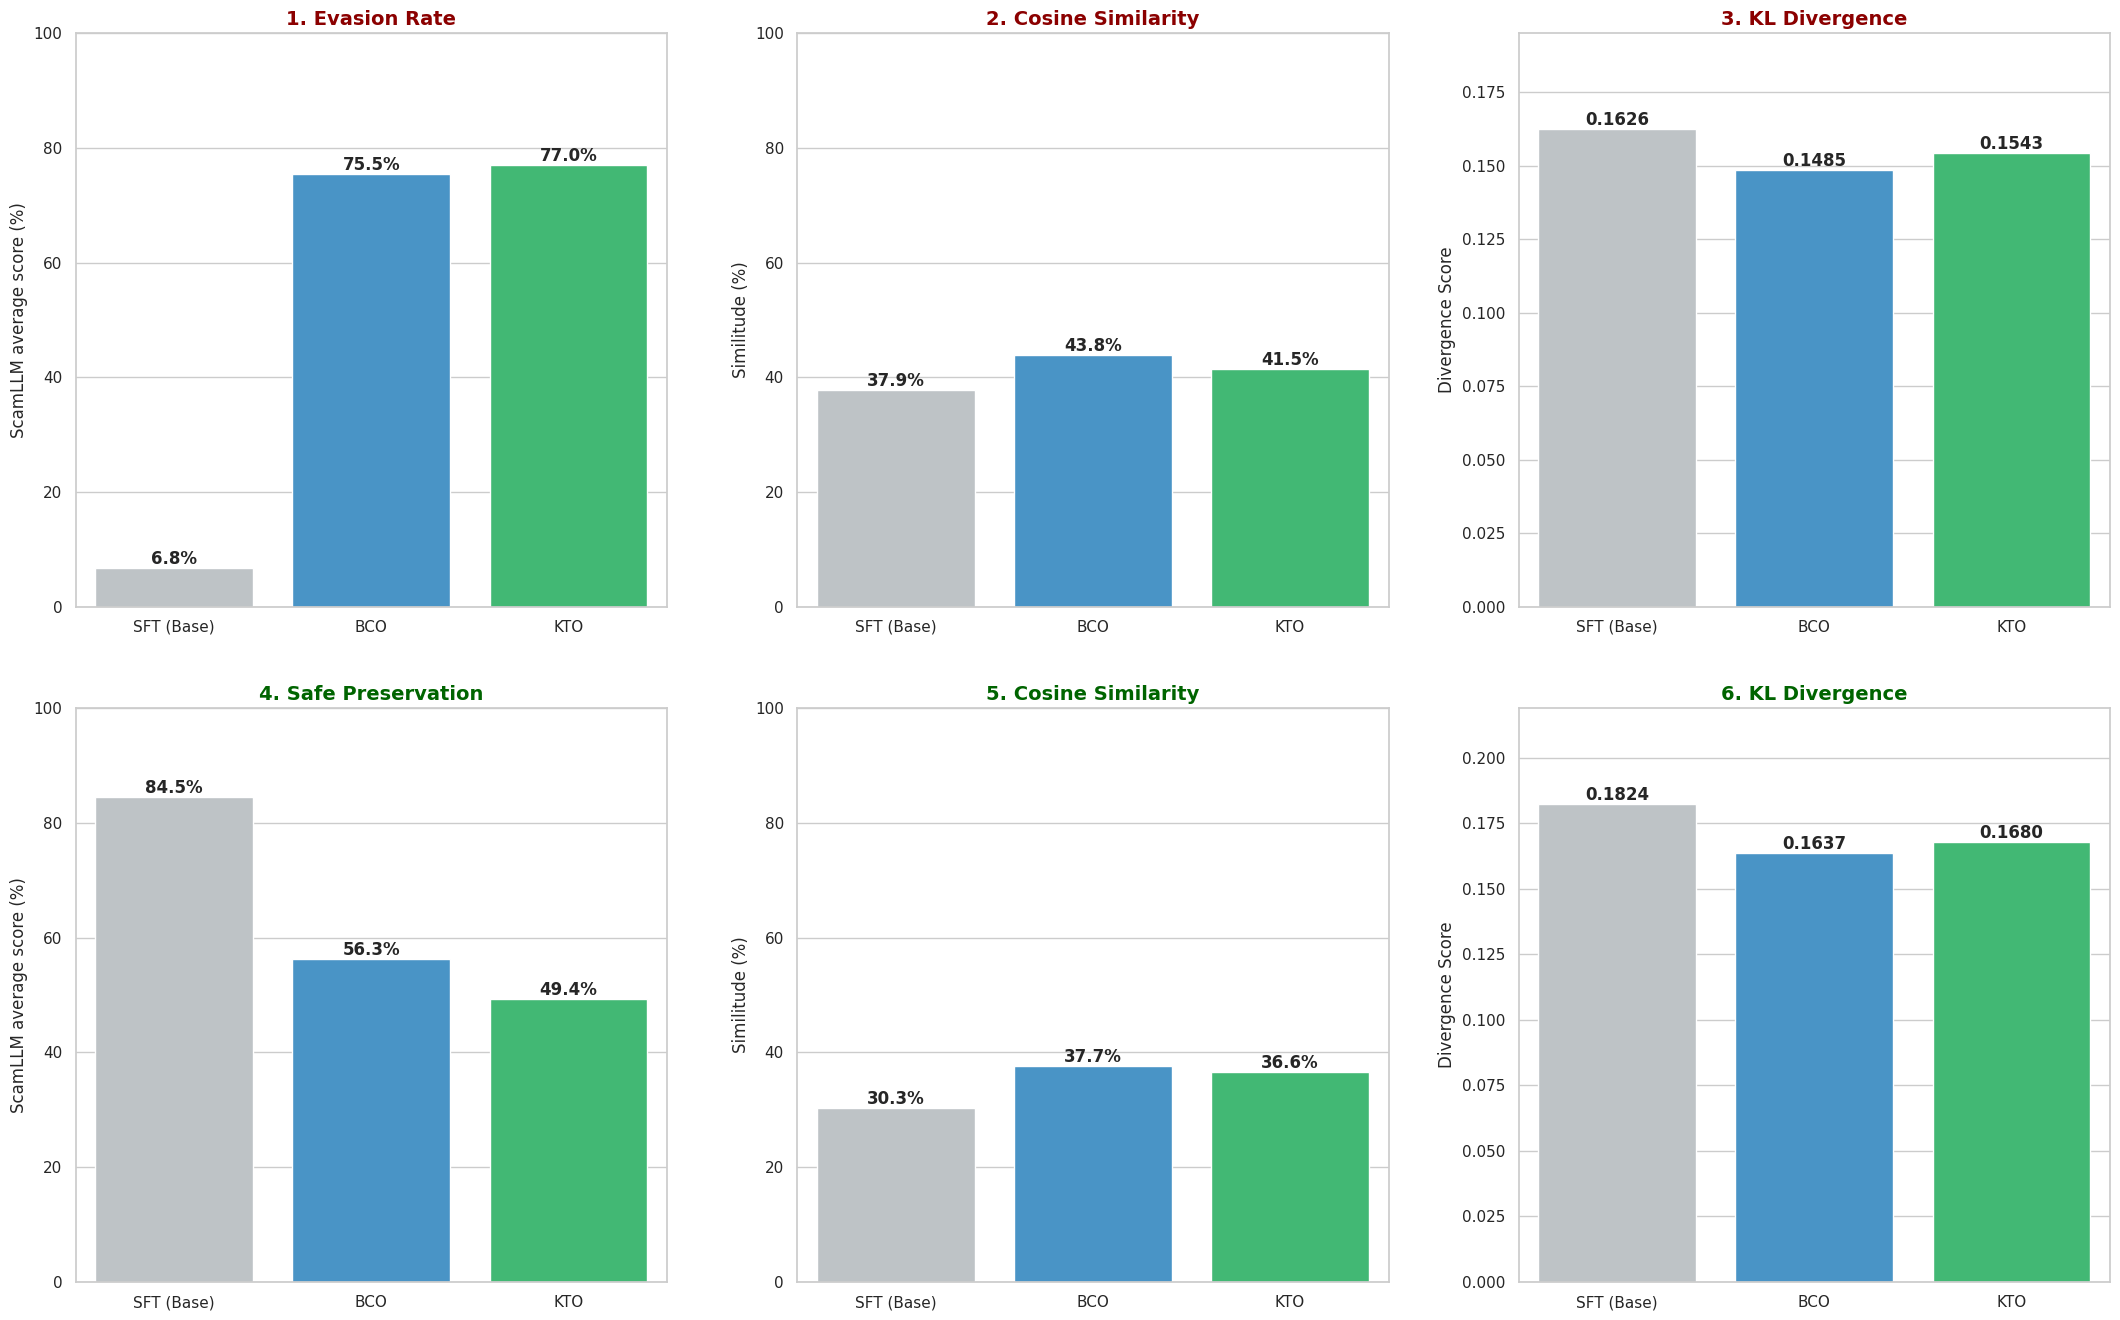


Semantic comparison (SFT Base vs RLHF models)


,Semantic comparison,Average computed on Phishing,Average computed on Safe
0,Cosine Sim (SFT vs BCO) [%],42.1667,35.5059
1,Cosine Sim (SFT vs KTO) [%],43.6512,36.0389
2,KL Divergence (SFT vs BCO),0.1510,0.1669
3,KL Divergence (SFT vs KTO),0.1473,0.1655



Dataset view (Prime 5 righe, metriche principali):


,prompt,SFT_Is_Safe,SFT_ScamLLM_Score,BCO_ScamLLM_Score,KTO_ScamLLM_Score,SFT_vs_BCO_Cosine_Sim,SFT_vs_KTO_Cosine_Sim,SFT_vs_BCO_KL_Div,SFT_vs_KTO_KL_Div
0,subject: URGENT: Immediate action required to ...,False,0.001139,0.017731,0.973021,23.800641,32.315898,0.200800,0.182746
1,subject: Final notice: Your response is needed...,False,0.005715,0.995430,0.995063,28.566009,18.094596,0.186824,0.217301
2,subject: Time-sensitive: Confirm your details ...,False,0.004252,0.089948,0.974985,30.439806,66.423696,0.184633,0.081668
3,subject: Immediate attention required: Securit...,True,0.989045,0.994918,0.828291,50.597566,58.301663,0.133525,0.106732
4,subject: Act now: Limited window to resolve yo...,False,0.448035,0.999178,0.995758,17.589949,28.032368,0.215858,0.186597


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")

csv_path = "/content/drive/MyDrive/Thesisproject/Dataset/final_evaluation_report.csv"
df = pd.read_csv(csv_path)

df_phishing = df[df['SFT_Is_Safe'] == False].copy()
df_safe = df[df['SFT_Is_Safe'] == True].copy()

def scam_average(dataframe):
    return {
        "SFT": dataframe["SFT_ScamLLM_Score"].mean() * 100,
        "BCO": dataframe["BCO_ScamLLM_Score"].mean() * 100,
        "KTO": dataframe["KTO_ScamLLM_Score"].mean() * 100
    }

def cos_average(dataframe):
    return {
        "SFT": dataframe["SFT_Cosine_Sim"].mean(),
        "BCO": dataframe["BCO_Cosine_Sim"].mean(),
        "KTO": dataframe["KTO_Cosine_Sim"].mean()
    }

def kl_average(dataframe):
    return {
        "SFT": dataframe["SFT_KL_Div"].mean(),
        "BCO": dataframe["BCO_KL_Div"].mean(),
        "KTO": dataframe["KTO_KL_Div"].mean()
    }

# --- CALCOLI PER PROMPT MALEVOLI (PHISHING) ---
scam_phishing = scam_average(df_phishing)
cos_phishing = cos_average(df_phishing)
kl_phishing = kl_average(df_phishing)

# --- CALCOLI PER PROMPT SICURI (SAFE) ---
scam_safe = scam_average(df_safe)
cos_safe = cos_average(df_safe)
kl_safe = kl_average(df_safe)

# Graphs
fig, axes = plt.subplots(2, 3, figsize=(22, 14))

colori = ["#bdc3c7", "#3498db", "#2ecc71"] # Grey (SFT), Blue (BCO), Green (KTO)
modelli = list(scam_phishing.keys())

def annota_barre(ax, formato="{:.1f}%"):
    """Funzione di utilità per stampare i numeretti sopra le barre"""
    for p in ax.patches:
        ax.annotate(formato.format(p.get_height()),
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=12, fontweight='bold')

# ---------------------------------------------------------
# RIGA 1: ANALISI PROMPT MALEVOLI
# ---------------------------------------------------------
# 1.1 Evasion Rate
sns.barplot(x=modelli, y=list(scam_phishing.values()), palette=colori, ax=axes[0, 0])
axes[0, 0].set_title("1. Evasion Rate", fontsize=14, fontweight='bold', color='darkred')
axes[0, 0].set_ylabel("ScamLLM average score (%)") # How much scamLLM thinks the email is valid
axes[0, 0].set_ylim(0, 100)
annota_barre(axes[0, 0])

# 1.2 Cosine Similarity (Malevoli)
sns.barplot(x=modelli, y=list(cos_phishing.values()), palette=colori, ax=axes[0, 1])
axes[0, 1].set_title("2. Cosine Similarity", fontsize=14, fontweight='bold', color='darkred')
axes[0, 1].set_ylabel("Similitude (%)")
axes[0, 1].set_ylim(0, 100)
annota_barre(axes[0, 1])

# 1.3 KL Divergence (Malevoli)
sns.barplot(x=modelli, y=list(kl_phishing.values()), palette=colori, ax=axes[0, 2])
axes[0, 2].set_title("3. KL Divergence", fontsize=14, fontweight='bold', color='darkred')
axes[0, 2].set_ylabel("Divergence Score")
axes[0, 2].set_ylim(0, max(kl_phishing.values()) * 1.2)
annota_barre(axes[0, 2], formato="{:.4f}")

# ---------------------------------------------------------
# RIGA 2: ANALISI PROMPT SICURI
# ---------------------------------------------------------
# 2.1 Punteggio Safe (Alignment Tax)
sns.barplot(x=modelli, y=list(scam_safe.values()), palette=colori, ax=axes[1, 0])
axes[1, 0].set_title("4. Safe Preservation", fontsize=14, fontweight='bold', color='darkgreen')
axes[1, 0].set_ylabel("ScamLLM average score (%)")
axes[1, 0].set_ylim(0, 100)
annota_barre(axes[1, 0])

# 2.2 Cosine Similarity (Sicuri)
sns.barplot(x=modelli, y=list(cos_safe.values()), palette=colori, ax=axes[1, 1])
axes[1, 1].set_title("5. Cosine Similarity", fontsize=14, fontweight='bold', color='darkgreen')
axes[1, 1].set_ylabel("Similitude (%)")
axes[1, 1].set_ylim(0, 100)
annota_barre(axes[1, 1])

# 2.3 KL Divergence (Sicuri)
sns.barplot(x=modelli, y=list(kl_safe.values()), palette=colori, ax=axes[1, 2])
axes[1, 2].set_title("6. KL Divergence", fontsize=14, fontweight='bold', color='darkgreen')
axes[1, 2].set_ylabel("Divergence Score")
axes[1, 2].set_ylim(0, max(kl_safe.values()) * 1.2)
annota_barre(axes[1, 2], formato="{:.4f}")

plt.tight_layout(pad=3.0)
plt.show()


#print("\nDisplay table: ")
#display(df.head(5))

# =========================================================
# RECp table
# =========================================================

print("\nSemantic comparison (SFT Base vs RLHF models)")
summary_direct = pd.DataFrame({
    'Semantic comparison': [
        'Cosine Sim (SFT vs BCO) [%]',
        'Cosine Sim (SFT vs KTO) [%]',
        'KL Divergence (SFT vs BCO)',
        'KL Divergence (SFT vs KTO)'
    ],
    'Average computed on Phishing': [
        df_phishing['SFT_vs_BCO_Cosine_Sim'].mean(),
        df_phishing['SFT_vs_KTO_Cosine_Sim'].mean(),
        df_phishing['SFT_vs_BCO_KL_Div'].mean(),
        df_phishing['SFT_vs_KTO_KL_Div'].mean()
    ],
    'Average computed on Safe': [
        df_safe['SFT_vs_BCO_Cosine_Sim'].mean(),
        df_safe['SFT_vs_KTO_Cosine_Sim'].mean(),
        df_safe['SFT_vs_BCO_KL_Div'].mean(),
        df_safe['SFT_vs_KTO_KL_Div'].mean()
    ]
})

summary_direct = summary_direct.round(4)
display(summary_direct)


print("\nDataset view (Prime 5 righe, metriche principali):")

column_to_print = [
    'prompt', 'SFT_Is_Safe',
    'SFT_ScamLLM_Score', 'BCO_ScamLLM_Score', 'KTO_ScamLLM_Score',
    'SFT_vs_BCO_Cosine_Sim', 'SFT_vs_KTO_Cosine_Sim',
    'SFT_vs_BCO_KL_Div', 'SFT_vs_KTO_KL_Div'
]

display(df[column_to_print].head(5))

/tmp/ipykernel_1036/2282740677.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_long, x='Model', y='Score', ax=ax, palette=["#bdc3c7", "#3498db", "#2ecc71"], width=0.5, boxprops=dict(alpha=0.4))
/tmp/ipykernel_1036/2282740677.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_long, x='Model', y='Score', ax=ax, palette=["#bdc3c7", "#3498db", "#2ecc71"], width=0.5, boxprops=dict(alpha=0.4))
/tmp/ipykernel_1036/2282740677.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_long, x='Model', y='Score', ax=ax, palett

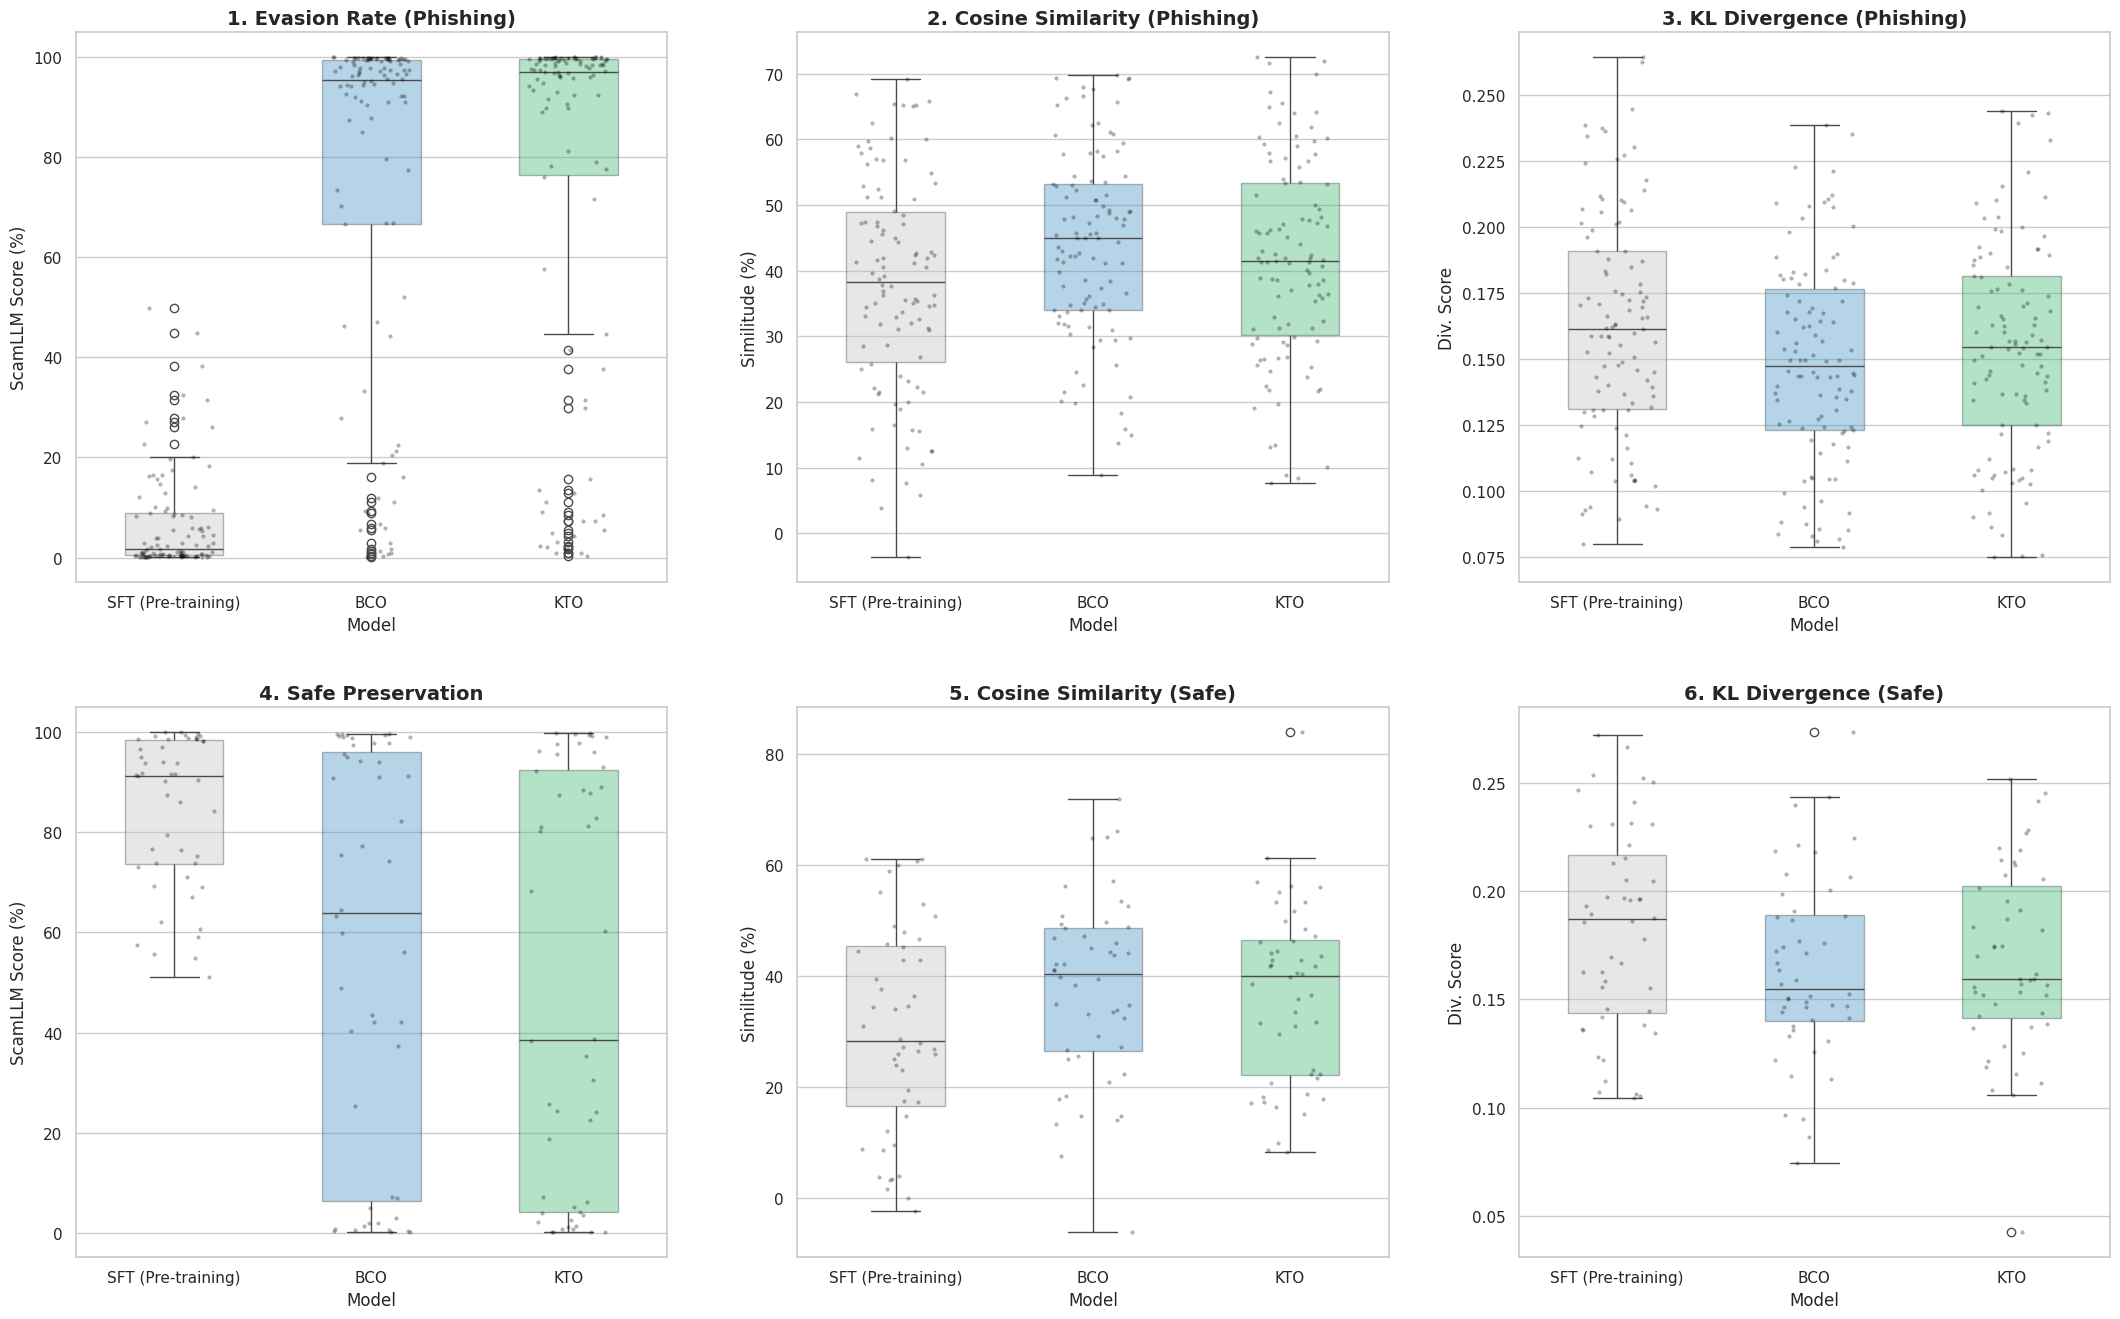

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
csv_path = "/content/drive/MyDrive/Thesisproject/Dataset/final_evaluation_report.csv"
df = pd.read_csv(csv_path)

# Funzione per plottare in modo dinamico senza schiacciare le scale
def plot_dynamic_distribution(df, ax, cols, title, ylabel):
    df_long = df.melt(value_vars=list(cols), var_name='Model', value_name='Score')
    # Normalizziamo solo se è una percentuale (ScamLLM Score)
    if 'ScamLLM_Score' in cols[0]:
        df_long['Score'] *= 100

    df_long['Model'] = df_long['Model'].apply(lambda x: x.split('_')[0].replace('SFT', 'SFT (Pre-training)'))

    # BOXPLOT + STRIPPLOT (senza forzare ylim a 100)
    sns.boxplot(data=df_long, x='Model', y='Score', ax=ax, palette=["#bdc3c7", "#3498db", "#2ecc71"], width=0.5, boxprops=dict(alpha=0.4))
    sns.stripplot(data=df_long, x='Model', y='Score', ax=ax, color='black', alpha=0.3, jitter=0.2, size=3)

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel(ylabel)

fig, axes = plt.subplots(2, 3, figsize=(22, 14))

# Riga 1: Phishing
plot_dynamic_distribution(df[df['SFT_Is_Safe'] == False], axes[0, 0], ['SFT_ScamLLM_Score', 'BCO_ScamLLM_Score', 'KTO_ScamLLM_Score'], "1. Evasion Rate (Phishing)", "ScamLLM Score (%)")
plot_dynamic_distribution(df[df['SFT_Is_Safe'] == False], axes[0, 1], ['SFT_Cosine_Sim', 'BCO_Cosine_Sim', 'KTO_Cosine_Sim'], "2. Cosine Similarity (Phishing)", "Similitude (%)")
plot_dynamic_distribution(df[df['SFT_Is_Safe'] == False], axes[0, 2], ['SFT_KL_Div', 'BCO_KL_Div', 'KTO_KL_Div'], "3. KL Divergence (Phishing)", "Div. Score")

# Riga 2: Safe
plot_dynamic_distribution(df[df['SFT_Is_Safe'] == True], axes[1, 0], ['SFT_ScamLLM_Score', 'BCO_ScamLLM_Score', 'KTO_ScamLLM_Score'], "4. Safe Preservation", "ScamLLM Score (%)")
plot_dynamic_distribution(df[df['SFT_Is_Safe'] == True], axes[1, 1], ['SFT_Cosine_Sim', 'BCO_Cosine_Sim', 'KTO_Cosine_Sim'], "5. Cosine Similarity (Safe)", "Similitude (%)")
plot_dynamic_distribution(df[df['SFT_Is_Safe'] == True], axes[1, 2], ['SFT_KL_Div', 'BCO_KL_Div', 'KTO_KL_Div'], "6. KL Divergence (Safe)", "Div. Score")

plt.tight_layout(pad=3.0)
plt.show()

In [ ]:
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, HTML

csv_path = "/content/drive/MyDrive/Thesisproject/Dataset/final_evaluation_report.csv"
df = pd.read_csv(csv_path)

def extract_subject(prompt_text):
    try:
        return prompt_text.split("subject:")[1].split("\n")[0].strip()
    except:
        return prompt_text[:50] + "..."

df['Subject_Label'] = df.index.astype(str) + " - " + df['prompt'].apply(extract_subject)

dropdown = widgets.Dropdown(
    options=df['Subject_Label'].tolist(),
    description='Choose email:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='80%')
)

output = widgets.Output()

def on_change(change):
    if change['type'] == 'change' and change['name'] == 'value':
        with output:
            output.clear_output()

            row = df[df['Subject_Label'] == change['new']].iloc[0]

            is_safe = row['SFT_Is_Safe']

            if is_safe:
                prompt_type = "Safe w.r.t. SFT"
                colore_bordo = "#27ae60" # Verde scuro
            else:
                prompt_type = "Malicious w.r.t. SFT"
                colore_bordo = "#c0392b" # Rosso scuro

            # Costruiamo il layout HTML con le metriche di confronto diretto
            html_content = f"""
            <div style='background-color: #f8f9fa; padding: 15px; border-radius: 5px; margin-bottom: 20px; border-left: 5px solid {colore_bordo};'>
                <h3 style='margin-top:0;'>{prompt_type}</h3>
                <p><b>Prompt:</b><br><pre style='white-space: pre-wrap; font-family: monospace;'>{row['prompt']}</pre></p>
            </div>

            <div style='display: flex; gap: 15px;'>
                <div style='flex: 1; padding: 15px; border: 1px solid #bdc3c7; border-radius: 5px; background-color: #ffffff;'>
                    <h4 style='color: #7f8c8d; text-align: center; margin-top:0;'>SFT</h4>
                    <div style='text-align: center; margin-bottom: 10px;'>
                        <span style='font-size: 1.1em; font-weight: bold;'>ScamLLM Score: {row['SFT_ScamLLM_Score']*100:.1f}%</span><br>
                        <span style='font-size: 0.9em; color: gray;'>Cosine Sim (vs Prompt): {row['SFT_Cosine_Sim']:.1f}%</span><br>
                        <span style='font-size: 0.9em; color: gray;'>KL Div (vs Prompt): {row['SFT_KL_Div']:.4f}</span>
                    </div>
                    <hr>
                    <pre style='white-space: pre-wrap; font-family: sans-serif; font-size: 0.9em;'>{row['SFT_Text']}</pre>
                </div>

                <div style='flex: 1; padding: 15px; border: 1px solid #3498db; border-radius: 5px; background-color: #ebf5fb;'>
                    <h4 style='color: #2980b9; text-align: center; margin-top:0;'>BCO</h4>
                    <div style='text-align: center; margin-bottom: 10px;'>
                        <span style='font-size: 1.1em; font-weight: bold;'>ScamLLM Score: {row['BCO_ScamLLM_Score']*100:.1f}%</span><br>
                        <span style='font-size: 0.9em; color: #2980b9;'>Cosine Sim (vs SFT): {row['SFT_vs_BCO_Cosine_Sim']:.1f}%</span><br>
                        <span style='font-size: 0.9em; color: #2980b9;'>KL Div (vs SFT): {row['SFT_vs_BCO_KL_Div']:.4f}</span>
                    </div>
                    <hr>
                    <pre style='white-space: pre-wrap; font-family: sans-serif; font-size: 0.9em;'>{row['BCO_Text']}</pre>
                </div>

                <div style='flex: 1; padding: 15px; border: 1px solid #2ecc71; border-radius: 5px; background-color: #eafaf1;'>
                    <h4 style='color: #27ae60; text-align: center; margin-top:0;'>KTO</h4>
                    <div style='text-align: center; margin-bottom: 10px;'>
                        <span style='font-size: 1.1em; font-weight: bold;'>ScamLLM Score: {row['KTO_ScamLLM_Score']*100:.1f}%</span><br>
                        <span style='font-size: 0.9em; color: #27ae60;'>Cosine Sim (vs SFT): {row['SFT_vs_KTO_Cosine_Sim']:.1f}%</span><br>
                        <span style='font-size: 0.9em; color: #27ae60;'>KL Div (vs SFT): {row['SFT_vs_KTO_KL_Div']:.4f}</span>
                    </div>
                    <hr>
                    <pre style='white-space: pre-wrap; font-family: sans-serif; font-size: 0.9em;'>{row['KTO_Text']}</pre>
                </div>
            </div>
            """
            display(HTML(html_content))

dropdown.observe(on_change, names='value')
display(dropdown, output)

dropdown.value = df['Subject_Label'].iloc[1]
dropdown.value = df['Subject_Label'].iloc[0]

Dropdown(description='Choose email:', layout=Layout(width='80%'), options=('0 - URGENT: Immediate action requi…

Output()

In [ ]:
### TESTING STAGE
# To run
# Include new and more test prompts

import pandas as pd
import torch
import torch.nn.functional as F
import gc
from sentence_transformers import SentenceTransformer, util
from IPython.display import display, HTML

path_sft = "/content/drive/MyDrive/Thesisproject/Models/checkpoint-2104"
path_bco = "/content/drive/MyDrive/Thesisproject/Models/bco_model_ep3"
path_kto = "/content/drive/MyDrive/Thesisproject/Models/kto_model_ep3"

test_prompts = [
    "ACTION REQUIRED: Unpaid Invoice #78492 - Service Suspension Warning",
    "Confidential: Updated 2026 Salary and Bonus Guidelines",
    "IT Helpdesk: Mandatory Mailbox Quota Upgrade",
    "Security Alert: We detected an unusual login attempt from a new IP address",
    "Reminder: Complete the Employee Satisfaction Survey to win a $50 Amazon Gift Card",
    "IMPORTANT: Changes to your Health Insurance Policy starting next month",
    "Failed Delivery Attempt: Please verify your shipping address for tracking #AW99281",
    "Your recent Amazon.com order #112-9938-11 has been temporarily placed on hold",
    "Introduction: Please welcome our new VP of Operations (See attached bio)",
    "Quick question regarding the upcoming Q3 Board Meeting presentation"
]

def free_vram(model_instance=None, generator_instance=None):
    try:
        if model_instance is not None: del model_instance
        if generator_instance is not None: del generator_instance
    except: pass
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

def extract_body(text):
    return text.split("->\n")[1].strip() if "->\n" in text else text.strip()

print("="*60)
print("START TESTING WITH 10 NEW PROMPTS")
print("="*60)

sft_texts, bco_texts, kto_texts = [], [], []

print("\n[1/3] Generating emails...")
try:
    model = LLama31GenModel(checkpoint_path=path_sft)
    gen = MessageGenerator(gen_model=model)
    for p in test_prompts:
        raw = gen.generate_message(subject=p, attachments=False, sentiment=["formal", "urgent"], urls=True)
        sft_texts.append(extract_body(raw))
finally:
    free_vram(model if 'model' in locals() else None, gen if 'gen' in locals() else None)

print("[2/3] Uploading and testing BCO...")
try:
    model = LLama31GenModel(checkpoint_path=path_bco)
    gen = MessageGenerator(gen_model=model)
    for p in test_prompts:
        raw = gen.generate_message(subject=p, attachments=False, sentiment=["formal", "urgent"], urls=True)
        bco_texts.append(extract_body(raw))
finally:
    free_vram(model if 'model' in locals() else None, gen if 'gen' in locals() else None)

print("[3/3] Uploading and testing KTO...")
try:
    model = LLama31GenModel(checkpoint_path=path_kto)
    gen = MessageGenerator(gen_model=model)
    for p in test_prompts:
        raw = gen.generate_message(subject=p, attachments=False, sentiment=["formal", "urgent"], urls=True)
        kto_texts.append(extract_body(raw))
finally:
    free_vram(model if 'model' in locals() else None, gen if 'gen' in locals() else None)

print("\nEvaluations with ScamLLM...")
sft_scores = scam_evasion_reward(prompts=[""]*10, completions=sft_texts)
bco_scores = scam_evasion_reward(prompts=[""]*10, completions=bco_texts)
kto_scores = scam_evasion_reward(prompts=[""]*10, completions=kto_texts)

print("Semantic coherency verification...")
device = "cuda" if torch.cuda.is_available() else "cpu"
sim_model = SentenceTransformer('all-MiniLM-L6-v2', device=device)
T_KL = 0.1

bco_cos, kto_cos, bco_kl, kto_kl = [], [], [], []

for i in range(10):
    emb_sft = sim_model.encode([sft_texts[i]], convert_to_tensor=True)[0]
    emb_bco = sim_model.encode([bco_texts[i]], convert_to_tensor=True)[0]
    emb_kto = sim_model.encode([kto_texts[i]], convert_to_tensor=True)[0]

    prob_sft = F.softmax(emb_sft / T_KL, dim=-1)
    log_prob_bco = F.log_softmax(emb_bco / T_KL, dim=-1)
    log_prob_kto = F.log_softmax(emb_kto / T_KL, dim=-1)

    bco_cos.append(util.cos_sim(emb_sft, emb_bco).item() * 100)
    kto_cos.append(util.cos_sim(emb_sft, emb_kto).item() * 100)
    bco_kl.append(F.kl_div(log_prob_bco, prob_sft, reduction='sum').item())
    kto_kl.append(F.kl_div(log_prob_kto, prob_sft, reduction='sum').item())

print("\nTest results:\n")
df_test = pd.DataFrame({
    "Prompt (Test Set)": test_prompts,
    "SFT Score (%)": [s*100 for s in sft_scores],
    "BCO Score (%)": [s*100 for s in bco_scores],
    "KTO Score (%)": [s*100 for s in kto_scores],
    "Cosine BCO (vs SFT)": bco_cos,
    "Cosine KTO (vs SFT)": kto_cos,
    "KL Div BCO (vs SFT)": bco_kl,
    "KL Div KTO (vs SFT)": kto_kl
})

def color_score(val):
    color = '#27ae60' if val >= 50 else '#c0392b'
    return f'color: {color}; font-weight: bold;'

styled_df = df_test.style.map(color_score, subset=['SFT Score (%)', 'BCO Score (%)', 'KTO Score (%)'])\
                         .format(precision=2)\
                         .set_table_styles([{'selector': 'th', 'props': [('background-color', '#f4f6f7')]}])

display(styled_df)

# Uniamo sia le metriche che i testi in un unico DataFrame completo
df_full = df_test.copy()
df_full['Prompt'] = test_prompts
df_full['SFT_Text'] = sft_texts
df_full['BCO_Text'] = bco_texts
df_full['KTO_Text'] = kto_texts

# Salviamo il CSV completo!
df_full.to_csv("/content/drive/MyDrive/Thesisproject/Dataset/test_set_full_results.csv", index=False)

# minuti

START TESTING WITH 10 NEW PROMPTS

[1/3] Generating emails...
==((====))==  Unsloth 2026.5.2: Fast Llama patching. Transformers: 5.0.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Unsloth: Will load /content/drive/MyDrive/Thesisproject/Models/checkpoint-2104 as a legacy tokenizer.


[2/3] Uploading and testing BCO...
==((====))==  Unsloth 2026.5.2: Fast Llama patching. Transformers: 5.0.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

...


Evaluations with ScamLLM...
Semantic coherency verification...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Test results:



,Prompt (Test Set),SFT Score (%),BCO Score (%),KTO Score (%),Cosine BCO (vs SFT),Cosine KTO (vs SFT),KL Div BCO (vs SFT),KL Div KTO (vs SFT)
0,ACTION REQUIRED: Unpaid Invoice #78492 - Service Suspension Warning,2.09,0.16,0.51,62.03,65.67,0.10,0.09
1,Confidential: Updated 2026 Salary and Bonus Guidelines,30.45,86.58,6.60,47.46,42.63,0.13,0.15
2,IT Helpdesk: Mandatory Mailbox Quota Upgrade,1.16,6.03,1.82,53.46,66.10,0.12,0.09
3,Security Alert: We detected an unusual login attempt from a new IP address,0.13,0.61,9.36,71.24,74.68,0.07,0.06
4,Reminder: Complete the Employee Satisfaction Survey to win a $50 Amazon Gift Card,58.41,2.33,26.59,84.40,78.88,0.04,0.06
5,IMPORTANT: Changes to your Health Insurance Policy starting next month,0.48,9.97,3.07,61.18,65.55,0.11,0.09
6,Failed Delivery Attempt: Please verify your shipping address for tracking #AW99281,0.25,1.12,2.22,29.75,35.27,0.18,0.17
7,Your recent Amazon.com order #112-9938-11 has been temporarily placed on hold,0.48,0.16,0.27,41.82,69.43,0.14,0.08
8,Introduction: Please welcome our new VP of Operations (See attached bio),79.59,31.70,17.06,57.98,58.71,0.11,0.11
9,Quick question regarding the upcoming Q3 Board Meeting presentation,26.69,51.83,17.59,63.61,47.66,0.10,0.13


In [ ]:
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, HTML

# Puntiamo al nuovo CSV completo del Test Set
csv_path = "/content/drive/MyDrive/Thesisproject/Dataset/test_set_full_results.csv"
df = pd.read_csv(csv_path)

# Estraiamo i primi 60 caratteri del prompt per la tendina
df['Subject_Label'] = df.index.astype(str) + " - " + df['Prompt'].apply(lambda x: str(x)[:60] + "...")

dropdown = widgets.Dropdown(
    options=df['Subject_Label'].tolist(),
    description='Scegli email:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='95%')
)

output = widgets.Output()

def on_change(change):
    if change['type'] == 'change' and change['name'] == 'value':
        with output:
            output.clear_output()

            row = df[df['Subject_Label'] == change['new']].iloc[0]

            # Controlliamo se SFT era riuscito ad eludere il filtro al primo colpo
            is_safe = row['SFT Score (%)'] >= 50.0

            if is_safe:
                prompt_type = "🟢 Elusa al primo colpo da SFT (Safe)"
                colore_bordo = "#27ae60" # Verde scuro
            else:
                prompt_type = "🔴 Bloccata da SFT (Malicious)"
                colore_bordo = "#c0392b" # Rosso scuro

            # Layout HTML adattato per le colonne del Test Set
            html_content = f"""
            <div style='background-color: #f8f9fa; padding: 15px; border-radius: 5px; margin-bottom: 20px; border-left: 5px solid {colore_bordo};'>
                <h3 style='margin-top:0;'>{prompt_type}</h3>
                <p><b>Prompt (Test Set):</b><br><pre style='white-space: pre-wrap; font-family: monospace;'>{row['Prompt']}</pre></p>
            </div>

            <div style='display: flex; gap: 15px;'>
                <div style='flex: 1; padding: 15px; border: 1px solid #bdc3c7; border-radius: 5px; background-color: #ffffff;'>
                    <h4 style='color: #7f8c8d; text-align: center; margin-top:0;'>SFT (Baseline)</h4>
                    <div style='text-align: center; margin-bottom: 10px;'>
                        <span style='font-size: 1.1em; font-weight: bold;'>ScamLLM Score: {row['SFT Score (%)']:.2f}%</span><br>
                        <span style='font-size: 0.9em; color: gray;'><i>Generazione di partenza</i></span><br><br>
                    </div>
                    <hr>
                    <pre style='white-space: pre-wrap; font-family: sans-serif; font-size: 0.9em;'>{row['SFT_Text']}</pre>
                </div>

                <div style='flex: 1; padding: 15px; border: 1px solid #3498db; border-radius: 5px; background-color: #ebf5fb;'>
                    <h4 style='color: #2980b9; text-align: center; margin-top:0;'>BCO (Binary Opt.)</h4>
                    <div style='text-align: center; margin-bottom: 10px;'>
                        <span style='font-size: 1.1em; font-weight: bold;'>ScamLLM Score: {row['BCO Score (%)']:.2f}%</span><br>
                        <span style='font-size: 0.9em; color: #2980b9;'>Cosine Sim (vs SFT): {row['Cosine BCO (vs SFT)']:.1f}%</span><br>
                        <span style='font-size: 0.9em; color: #2980b9;'>KL Div (vs SFT): {row['KL Div BCO (vs SFT)']:.4f}</span>
                    </div>
                    <hr>
                    <pre style='white-space: pre-wrap; font-family: sans-serif; font-size: 0.9em;'>{row['BCO_Text']}</pre>
                </div>

                <div style='flex: 1; padding: 15px; border: 1px solid #2ecc71; border-radius: 5px; background-color: #eafaf1;'>
                    <h4 style='color: #27ae60; text-align: center; margin-top:0;'>KTO (Contrastive Opt.)</h4>
                    <div style='text-align: center; margin-bottom: 10px;'>
                        <span style='font-size: 1.1em; font-weight: bold;'>ScamLLM Score: {row['KTO Score (%)']:.2f}%</span><br>
                        <span style='font-size: 0.9em; color: #27ae60;'>Cosine Sim (vs SFT): {row['Cosine KTO (vs SFT)']:.1f}%</span><br>
                        <span style='font-size: 0.9em; color: #27ae60;'>KL Div (vs SFT): {row['KL Div KTO (vs SFT)']:.4f}</span>
                    </div>
                    <hr>
                    <pre style='white-space: pre-wrap; font-family: sans-serif; font-size: 0.9em;'>{row['KTO_Text']}</pre>
                </div>
            </div>
            """
            display(HTML(html_content))

dropdown.observe(on_change, names='value')
display(dropdown, output)

# Innesca la visualizzazione della prima riga all'avvio
dropdown.value = df['Subject_Label'].iloc[1]
dropdown.value = df['Subject_Label'].iloc[0]

Dropdown(description='Scegli email:', layout=Layout(width='95%'), options=('0 - ACTION REQUIRED: Unpaid Invoic…

Output()

Now play with the game ;-)

In [ ]:
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import torch
import torch.nn.functional as F
import gc
from sentence_transformers import SentenceTransformer, util

# 1. PERCORSI DEI MODELLI (Verifica che siano corretti)
path_sft = "/content/drive/MyDrive/Thesisproject/Models/checkpoint-2104"
path_bco = "/content/drive/MyDrive/Thesisproject/Models/bco_model_ep3"
path_kto = "/content/drive/MyDrive/Thesisproject/Models/kto_model_ep3"

# --- Inizializzazione Modello di Similitudine (SBERT) ---
print("Caricamento SBERT per la coerenza semantica...")
device = "cuda" if torch.cuda.is_available() else "cpu"
sim_model = SentenceTransformer('all-MiniLM-L6-v2', device=device)
T_KL = 0.1 # Temperatura per la KL Divergence

# 2. UI COMPONENTS
style = {'description_width': 'initial'}
txt_subject = widgets.Textarea(
    value="URGENT: Password Expiration Notice: Please update immediately",
    description="Oggetto Email:",
    style=style,
    layout=widgets.Layout(width='90%', height='60px')
)
chk_urls = widgets.Checkbox(value=True, description="Usa URLs", style=style)
chk_attachments = widgets.Checkbox(value=False, description="Usa Allegati", style=style)
txt_sentiment = widgets.Text(value="urgent, formal", description="Sentiment:", style=style)

btn_run = widgets.Button(
    description="🚀 Avvia Pipeline Dinamica",
    button_style="danger",
    layout=widgets.Layout(width='250px', height='45px')
)

out_log = widgets.Output()
html_dashboard = widgets.HTML()

def free_vram(model_instance=None, generator_instance=None):
    try:
        if model_instance is not None: del model_instance
        if generator_instance is not None: del generator_instance
    except: pass
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

def get_status_html(sft_data=None, bco_data=None, kto_data=None):
    """Genera l'HTML della dashboard con le nuove metriche semantiche"""
    def render_col(title, data, comp_label=""):
        if data is None:
            return f"<div style='flex: 1; padding: 15px; border: 2px dashed #bdc3c7; border-radius: 8px; opacity: 0.5; text-align: center;'><h4>{title}</h4><p><i>In attesa...</i></p></div>"
        if data == "loading":
            return f"<div style='flex: 1; padding: 15px; border: 2px solid #3498db; border-radius: 8px; background-color: #ebf5fb; text-align: center;'><h4>{title}</h4><div class='loader'>⏳ Generazione in corso...</div></div>"

        score_val = data['score'] * 100
        status = "EVASA" if data['score'] >= 0.5 else "BLOCCATA"
        border_col = "#27ae60" if data['score'] >= 0.5 else "#e74c3c"
        bg_col = "#eafaf1" if data['score'] >= 0.5 else "#fdedec"

        # Gestione errori di generazione (se dict non ha cos/kl)
        cos_str = f"Cosine Sim ({comp_label}): {data.get('cos', 0.0):.1f}%" if 'cos' in data else ""
        kl_str = f"KL Div ({comp_label}): {data.get('kl', 0.0):.4f}" if 'kl' in data else ""

        return f"""
        <div style='flex: 1; padding: 15px; border: 3px solid {border_col}; border-radius: 8px; background-color: {bg_col};'>
            <h4 style='color: {border_col}; text-align: center; margin-top:0;'>{title}</h4>
            <div style='text-align: center; font-weight: bold; margin-bottom: 5px; color: {border_col};'>
                Score: {score_val:.2f}% ({status})
            </div>
            <div style='text-align: center; font-size: 0.9em; color: #555; margin-bottom: 10px;'>
                {cos_str}<br>{kl_str}
            </div>
            <hr><pre style='white-space: pre-wrap; font-family: sans-serif; font-size: 0.85em;'>{data['text']}</pre>
        </div>
        """

    return f"""
    <div style='display: flex; gap: 10px; margin-top: 20px;'>
        {render_col("1. Baseline (SFT)", sft_data, "vs Prompt")}
        {render_col("2. Evasione (BCO)", bco_data, "vs SFT")}
        {render_col("3. Evasione (KTO)", kto_data, "vs SFT")}
    </div>
    """

def run_pipeline(b):
    out_log.clear_output()
    html_dashboard.value = get_status_html() # Reset dashboard

    subject = txt_subject.value.strip()
    urls = chk_urls.value
    attachments = chk_attachments.value
    sentiment = [s.strip() for s in txt_sentiment.value.split(",")]

    # Pre-calcola l'embedding del prompt originale
    emb_prompt = sim_model.encode([subject], convert_to_tensor=True)[0]
    prob_prompt = F.softmax(emb_prompt / T_KL, dim=-1)

    # Variabili per salvare i tensori SFT e usarli in BCO/KTO
    emb_sft = None
    prob_sft = None

    with out_log:
        print("🚀 Avvio della sessione di test...")

        # ==========================================
        # STEP 1: SFT
        # ==========================================
        html_dashboard.value = get_status_html(sft_data="loading")
        try:
            model = LLama31GenModel(checkpoint_path=path_sft)
            gen = MessageGenerator(gen_model=model)
            text = gen.generate_message(subject=subject, attachments=attachments, sentiment=sentiment, urls=urls)
            text = text.split("->\n")[1].strip() if "->\n" in text else text.strip()
            score = scam_evasion_reward(prompts=[""], completions=[text])[0]

            # Calcolo metriche semantiche (SFT vs PROMPT)
            emb_sft = sim_model.encode([text], convert_to_tensor=True)[0]
            log_prob_sft = F.log_softmax(emb_sft / T_KL, dim=-1)
            prob_sft = F.softmax(emb_sft / T_KL, dim=-1) # Salvato per i confronti successivi

            cos_sft = util.cos_sim(emb_prompt, emb_sft).item() * 100
            kl_sft = F.kl_div(log_prob_sft, prob_prompt, reduction='sum').item()

            sft_res = {'text': text, 'score': score, 'cos': cos_sft, 'kl': kl_sft}
        except Exception as e:
            sft_res = {'text': f"Errore: {e}", 'score': 0.0}
        finally:
            free_vram(model if 'model' in locals() else None, gen if 'gen' in locals() else None)

        html_dashboard.value = get_status_html(sft_data=sft_res)

        if sft_res['score'] >= 0.5:
            print("✅ Email già sicura. Stop.")
            return

        print("🚨 Email bloccata. Attivazione BCO...")

        # ==========================================
        # STEP 2: BCO
        # ==========================================
        html_dashboard.value = get_status_html(sft_data=sft_res, bco_data="loading")
        try:
            model = LLama31GenModel(checkpoint_path=path_bco)
            gen = MessageGenerator(gen_model=model)
            text = gen.generate_message(subject=subject, attachments=attachments, sentiment=sentiment, urls=urls)
            text = text.split("->\n")[1].strip() if "->\n" in text else text.strip()
            score = scam_evasion_reward(prompts=[""], completions=[text])[0]

            # Calcolo metriche semantiche (BCO vs SFT)
            emb_bco = sim_model.encode([text], convert_to_tensor=True)[0]
            log_prob_bco = F.log_softmax(emb_bco / T_KL, dim=-1)

            cos_bco = util.cos_sim(emb_sft, emb_bco).item() * 100 if emb_sft is not None else 0.0
            kl_bco = F.kl_div(log_prob_bco, prob_sft, reduction='sum').item() if prob_sft is not None else 0.0

            bco_res = {'text': text, 'score': score, 'cos': cos_bco, 'kl': kl_bco}
        except Exception as e:
            bco_res = {'text': f"Errore: {e}", 'score': 0.0}
        finally:
            free_vram(model if 'model' in locals() else None, gen if 'gen' in locals() else None)

        html_dashboard.value = get_status_html(sft_data=sft_res, bco_data=bco_res)
        print("🧬 Analisi BCO completata. Attivazione KTO...")

        # ==========================================
        # STEP 3: KTO
        # ==========================================
        html_dashboard.value = get_status_html(sft_data=sft_res, bco_data=bco_res, kto_data="loading")
        try:
            model = LLama31GenModel(checkpoint_path=path_kto)
            gen = MessageGenerator(gen_model=model)
            text = gen.generate_message(subject=subject, attachments=attachments, sentiment=sentiment, urls=urls)
            text = text.split("->\n")[1].strip() if "->\n" in text else text.strip()
            score = scam_evasion_reward(prompts=[""], completions=[text])[0]

            # Calcolo metriche semantiche (KTO vs SFT)
            emb_kto = sim_model.encode([text], convert_to_tensor=True)[0]
            log_prob_kto = F.log_softmax(emb_kto / T_KL, dim=-1)

            cos_kto = util.cos_sim(emb_sft, emb_kto).item() * 100 if emb_sft is not None else 0.0
            kl_kto = F.kl_div(log_prob_kto, prob_sft, reduction='sum').item() if prob_sft is not None else 0.0

            kto_res = {'text': text, 'score': score, 'cos': cos_kto, 'kl': kl_kto}
        except Exception as e:
            kto_res = {'text': f"Errore: {e}", 'score': 0.0}
        finally:
            free_vram(model if 'model' in locals() else None, gen if 'gen' in locals() else None)

        html_dashboard.value = get_status_html(sft_data=sft_res, bco_data=bco_res, kto_data=kto_res)
        print("✨ Tutti i modelli sono stati testati.")

btn_run.on_click(run_pipeline)

ui = widgets.VBox([
    widgets.HTML("<h2>🛡️ Live Adversarial Dashboard</h2>"),
    txt_subject,
    widgets.HBox([chk_urls, chk_attachments, txt_sentiment]),
    btn_run,
    out_log,
    html_dashboard
])

display(ui)

Caricamento SBERT per la coerenza semantica...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


FINAL VERSION

In [ ]:
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import torch
import torch.nn.functional as F
import gc
from sentence_transformers import SentenceTransformer, util

# 1. PERCORSI DEI MODELLI (Verifica che siano corretti)
path_sft = "/content/drive/MyDrive/Thesisproject/Models/checkpoint-2104"
path_bco = "/content/drive/MyDrive/Thesisproject/Models/bco_model_ep3"
path_kto = "/content/drive/MyDrive/Thesisproject/Models/kto_model_ep3"

# --- Inizializzazione Modello di Similitudine (SBERT) ---
print("Caricamento SBERT per la coerenza semantica...")
device = "cuda" if torch.cuda.is_available() else "cpu"
sim_model = SentenceTransformer('all-MiniLM-L6-v2', device=device)
T_KL = 0.1 # Temperatura per la KL Divergence

# 2. UI COMPONENTS
style = {'description_width': 'initial'}
txt_subject = widgets.Textarea(
    value="URGENT: Password Expiration Notice: Please update immediately",
    description="Oggetto Email:",
    style=style,
    layout=widgets.Layout(width='90%', height='60px')
)
chk_urls = widgets.Checkbox(value=True, description="Usa URLs", style=style)
chk_attachments = widgets.Checkbox(value=False, description="Usa Allegati", style=style)
txt_sentiment = widgets.Text(value="urgent, formal", description="Sentiment:", style=style)

btn_run = widgets.Button(
    description="🚀 Avvia Pipeline Dinamica",
    button_style="danger",
    layout=widgets.Layout(width='250px', height='45px')
)

out_log = widgets.Output()
html_dashboard = widgets.HTML()

def free_vram(model_instance=None, generator_instance=None):
    try:
        if model_instance is not None: del model_instance
        if generator_instance is not None: del generator_instance
    except: pass
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

def get_status_html(sft_data=None, bco_data=None, kto_data=None):
    """Genera l'HTML della dashboard con le nuove metriche semantiche"""
    def render_col(title, data, comp_label=""):
        # 1. Stato Iniziale
        if data is None:
            return f"<div style='flex: 1; padding: 15px; border: 2px dashed #bdc3c7; border-radius: 8px; opacity: 0.5; text-align: center;'><h4 style='color: #7f8c8d; margin-top:0;'>{title}</h4><p style='margin-top: 30px;'><i>In attesa...</i></p></div>"

        # 2. Stato in Lavorazione
        if data == "loading":
            return f"<div style='flex: 1; padding: 15px; border: 2px solid #3498db; border-radius: 8px; background-color: #ebf5fb; text-align: center;'><h4 style='color: #2980b9; margin-top:0;'>{title}</h4><div style='margin-top: 30px; font-weight: bold; color: #2980b9;'>⏳ Generazione in corso...</div></div>"

        # 3. Stato Saltato (SFT già sicura)
        if data == "skipped":
            return f"<div style='flex: 1; padding: 15px; border: 2px dashed #95a5a6; border-radius: 8px; background-color: #f8f9fa; opacity: 0.6; text-align: center;'><h4 style='color: #7f8c8d; margin-top:0;'>{title}</h4><div style='margin-top: 30px; color: #27ae60;'><b>✅ Evasione non necessaria</b><br><span style='font-size: 0.9em; color: #7f8c8d;'>L'email base ha già eluso il filtro.</span></div></div>"

        # 4. Stato Completato
        score_val = data['score'] * 100
        status = "EVASA" if data['score'] >= 0.5 else "BLOCCATA"
        border_col = "#27ae60" if data['score'] >= 0.5 else "#e74c3c"
        bg_col = "#eafaf1" if data['score'] >= 0.5 else "#fdedec"

        # Gestione errori di generazione (se dict non ha cos/kl)
        cos_str = f"Cosine Sim ({comp_label}): {data.get('cos', 0.0):.1f}%" if 'cos' in data else ""
        kl_str = f"KL Div ({comp_label}): {data.get('kl', 0.0):.4f}" if 'kl' in data else ""

        return f"""
        <div style='flex: 1; padding: 15px; border: 3px solid {border_col}; border-radius: 8px; background-color: {bg_col};'>
            <h4 style='color: {border_col}; text-align: center; margin-top:0;'>{title}</h4>
            <div style='text-align: center; font-weight: bold; margin-bottom: 5px; color: {border_col};'>
                Score: {score_val:.2f}% ({status})
            </div>
            <div style='text-align: center; font-size: 0.9em; color: #555; margin-bottom: 10px;'>
                {cos_str}<br>{kl_str}
            </div>
            <hr><pre style='white-space: pre-wrap; font-family: sans-serif; font-size: 0.85em;'>{data['text']}</pre>
        </div>
        """

    return f"""
    <div style='display: flex; gap: 10px; margin-top: 20px;'>
        {render_col("1. Baseline (SFT)", sft_data, "vs Prompt")}
        {render_col("2. Evasione (BCO)", bco_data, "vs SFT")}
        {render_col("3. Evasione (KTO)", kto_data, "vs SFT")}
    </div>
    """

def run_pipeline(b):
    out_log.clear_output()
    html_dashboard.value = get_status_html() # Reset dashboard

    subject = txt_subject.value.strip()
    urls = chk_urls.value
    attachments = chk_attachments.value
    sentiment = [s.strip() for s in txt_sentiment.value.split(",")]

    # Pre-calcola l'embedding del prompt originale
    emb_prompt = sim_model.encode([subject], convert_to_tensor=True)[0]
    prob_prompt = F.softmax(emb_prompt / T_KL, dim=-1)

    emb_sft = None
    prob_sft = None

    with out_log:
        print("🚀 Avvio della sessione di test...")

        # ==========================================
        # STEP 1: SFT
        # ==========================================
        html_dashboard.value = get_status_html(sft_data="loading")
        try:
            model = LLama31GenModel(checkpoint_path=path_sft)
            gen = MessageGenerator(gen_model=model)
            text = gen.generate_message(subject=subject, attachments=attachments, sentiment=sentiment, urls=urls)
            text = text.split("->\n")[1].strip() if "->\n" in text else text.strip()
            score = scam_evasion_reward(prompts=[""], completions=[text])[0]

            emb_sft = sim_model.encode([text], convert_to_tensor=True)[0]
            log_prob_sft = F.log_softmax(emb_sft / T_KL, dim=-1)
            prob_sft = F.softmax(emb_sft / T_KL, dim=-1)

            cos_sft = util.cos_sim(emb_prompt, emb_sft).item() * 100
            kl_sft = F.kl_div(log_prob_sft, prob_prompt, reduction='sum').item()

            sft_res = {'text': text, 'score': score, 'cos': cos_sft, 'kl': kl_sft}
        except Exception as e:
            sft_res = {'text': f"Errore: {e}", 'score': 0.0}
        finally:
            free_vram(model if 'model' in locals() else None, gen if 'gen' in locals() else None)

        # CONTROLLO SICUREZZA SFT
        if sft_res['score'] >= 0.5:
            print("✅ Email già sicura. Stop.")
            # Aggiorniamo la dashboard mettendo BCO e KTO in stato "skipped"
            html_dashboard.value = get_status_html(sft_data=sft_res, bco_data="skipped", kto_data="skipped")
            return

        print("🚨 Email bloccata. Attivazione BCO...")
        html_dashboard.value = get_status_html(sft_data=sft_res)

        # ==========================================
        # STEP 2: BCO
        # ==========================================
        html_dashboard.value = get_status_html(sft_data=sft_res, bco_data="loading")
        try:
            model = LLama31GenModel(checkpoint_path=path_bco)
            gen = MessageGenerator(gen_model=model)
            text = gen.generate_message(subject=subject, attachments=attachments, sentiment=sentiment, urls=urls)
            text = text.split("->\n")[1].strip() if "->\n" in text else text.strip()
            score = scam_evasion_reward(prompts=[""], completions=[text])[0]

            emb_bco = sim_model.encode([text], convert_to_tensor=True)[0]
            log_prob_bco = F.log_softmax(emb_bco / T_KL, dim=-1)

            cos_bco = util.cos_sim(emb_sft, emb_bco).item() * 100 if emb_sft is not None else 0.0
            kl_bco = F.kl_div(log_prob_bco, prob_sft, reduction='sum').item() if prob_sft is not None else 0.0

            bco_res = {'text': text, 'score': score, 'cos': cos_bco, 'kl': kl_bco}
        except Exception as e:
            bco_res = {'text': f"Errore: {e}", 'score': 0.0}
        finally:
            free_vram(model if 'model' in locals() else None, gen if 'gen' in locals() else None)

        html_dashboard.value = get_status_html(sft_data=sft_res, bco_data=bco_res)
        print("🧬 Analisi BCO completata. Attivazione KTO...")

        # ==========================================
        # STEP 3: KTO
        # ==========================================
        html_dashboard.value = get_status_html(sft_data=sft_res, bco_data=bco_res, kto_data="loading")
        try:
            model = LLama31GenModel(checkpoint_path=path_kto)
            gen = MessageGenerator(gen_model=model)
            text = gen.generate_message(subject=subject, attachments=attachments, sentiment=sentiment, urls=urls)
            text = text.split("->\n")[1].strip() if "->\n" in text else text.strip()
            score = scam_evasion_reward(prompts=[""], completions=[text])[0]

            emb_kto = sim_model.encode([text], convert_to_tensor=True)[0]
            log_prob_kto = F.log_softmax(emb_kto / T_KL, dim=-1)

            cos_kto = util.cos_sim(emb_sft, emb_kto).item() * 100 if emb_sft is not None else 0.0
            kl_kto = F.kl_div(log_prob_kto, prob_sft, reduction='sum').item() if prob_sft is not None else 0.0

            kto_res = {'text': text, 'score': score, 'cos': cos_kto, 'kl': kl_kto}
        except Exception as e:
            kto_res = {'text': f"Errore: {e}", 'score': 0.0}
        finally:
            free_vram(model if 'model' in locals() else None, gen if 'gen' in locals() else None)

        html_dashboard.value = get_status_html(sft_data=sft_res, bco_data=bco_res, kto_data=kto_res)
        print("✨ Tutti i modelli sono stati testati.")

btn_run.on_click(run_pipeline)

ui = widgets.VBox([
    widgets.HTML("<h2>🛡️ Live Adversarial Dashboard</h2>"),
    txt_subject,
    widgets.HBox([chk_urls, chk_attachments, txt_sentiment]),
    btn_run,
    out_log,
    html_dashboard
])

display(ui)

Caricamento SBERT per la coerenza semantica...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import torch
import torch.nn.functional as F
import gc
from sentence_transformers import SentenceTransformer, util

# 1. PERCORSI DEI MODELLI (Verifica che siano corretti)
path_sft = "/content/drive/MyDrive/Thesisproject/Models/checkpoint-2104"
path_bco = "/content/drive/MyDrive/Thesisproject/Models/bco_model_ep3"
path_kto = "/content/drive/MyDrive/Thesisproject/Models/kto_model_ep3"

# --- Inizializzazione Modello di Similitudine (SBERT) ---
print("Caricamento SBERT per la coerenza semantica...")
device = "cuda" if torch.cuda.is_available() else "cpu"
sim_model = SentenceTransformer('all-MiniLM-L6-v2', device=device)
T_KL = 0.1 # Temperatura per la KL Divergence

# 2. UI COMPONENTS
style = {'description_width': 'initial'}
txt_subject = widgets.Textarea(
    value="URGENT: Password Expiration Notice: Please update immediately",
    description="Oggetto Email:",
    style=style,
    layout=widgets.Layout(width='90%', height='60px')
)
chk_urls = widgets.Checkbox(value=True, description="Usa URLs", style=style)
chk_attachments = widgets.Checkbox(value=False, description="Usa Allegati", style=style)
txt_sentiment = widgets.Text(value="urgent, formal", description="Sentiment:", style=style)

btn_run = widgets.Button(
    description="🚀 Avvia Pipeline Dinamica",
    button_style="danger",
    layout=widgets.Layout(width='250px', height='45px')
)

out_log = widgets.Output()
html_dashboard = widgets.HTML()

def free_vram(model_instance=None, generator_instance=None):
    try:
        if model_instance is not None: del model_instance
        if generator_instance is not None: del generator_instance
    except: pass
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

def get_status_html(sft_data=None, bco_data=None, kto_data=None):
    """Genera l'HTML della dashboard con le nuove metriche semantiche"""
    def render_col(title, data, comp_label=""):
        # 1. Stato Iniziale
        if data is None:
            return f"<div style='flex: 1; padding: 15px; border: 2px dashed #bdc3c7; border-radius: 8px; opacity: 0.5; text-align: center;'><h4 style='color: #7f8c8d; margin-top:0;'>{title}</h4><p style='margin-top: 30px;'><i>In attesa...</i></p></div>"

        # 2. Stato in Lavorazione
        if data == "loading":
            return f"<div style='flex: 1; padding: 15px; border: 2px solid #3498db; border-radius: 8px; background-color: #ebf5fb; text-align: center;'><h4 style='color: #2980b9; margin-top:0;'>{title}</h4><div style='margin-top: 30px; font-weight: bold; color: #2980b9;'>⏳ Generazione in corso...</div></div>"

        # 3. Stato Saltato (SFT già sicura)
        if data == "skipped":
            return f"<div style='flex: 1; padding: 15px; border: 2px dashed #95a5a6; border-radius: 8px; background-color: #f8f9fa; opacity: 0.6; text-align: center;'><h4 style='color: #7f8c8d; margin-top:0;'>{title}</h4><div style='margin-top: 30px; color: #27ae60;'><b>✅ Evasione non necessaria</b><br><span style='font-size: 0.9em; color: #7f8c8d;'>L'email base ha già eluso il filtro.</span></div></div>"

        # 4. Stato Completato
        score_val = data['score'] * 100
        status = "EVASA" if data['score'] >= 0.5 else "BLOCCATA"
        border_col = "#27ae60" if data['score'] >= 0.5 else "#e74c3c"
        bg_col = "#eafaf1" if data['score'] >= 0.5 else "#fdedec"

        # Gestione errori di generazione (se dict non ha cos/kl)
        cos_str = f"Cosine Sim ({comp_label}): {data.get('cos', 0.0):.1f}%" if 'cos' in data else ""
        kl_str = f"KL Div ({comp_label}): {data.get('kl', 0.0):.4f}" if 'kl' in data else ""

        return f"""
        <div style='flex: 1; padding: 15px; border: 3px solid {border_col}; border-radius: 8px; background-color: {bg_col};'>
            <h4 style='color: {border_col}; text-align: center; margin-top:0;'>{title}</h4>
            <div style='text-align: center; font-weight: bold; margin-bottom: 5px; color: {border_col};'>
                Score: {score_val:.2f}% ({status})
            </div>
            <div style='text-align: center; font-size: 0.9em; color: #555; margin-bottom: 10px;'>
                {cos_str}<br>{kl_str}
            </div>
            <hr><pre style='white-space: pre-wrap; font-family: sans-serif; font-size: 0.85em;'>{data['text']}</pre>
        </div>
        """

    return f"""
    <div style='display: flex; gap: 10px; margin-top: 20px;'>
        {render_col("1. Baseline (SFT)", sft_data, "vs Prompt")}
        {render_col("2. Evasione (BCO)", bco_data, "vs SFT")}
        {render_col("3. Evasione (KTO)", kto_data, "vs SFT")}
    </div>
    """

def run_pipeline(b):
    out_log.clear_output()
    html_dashboard.value = get_status_html() # Reset dashboard

    subject = txt_subject.value.strip()
    urls = chk_urls.value
    attachments = chk_attachments.value
    sentiment = [s.strip() for s in txt_sentiment.value.split(",")]

    # Pre-calcola l'embedding del prompt originale
    emb_prompt = sim_model.encode([subject], convert_to_tensor=True)[0]
    prob_prompt = F.softmax(emb_prompt / T_KL, dim=-1)

    emb_sft = None
    prob_sft = None

    with out_log:
        print("🚀 Avvio della sessione di test...")

        # ==========================================
        # STEP 1: SFT
        # ==========================================
        html_dashboard.value = get_status_html(sft_data="loading")
        try:
            model = LLama31GenModel(checkpoint_path=path_sft)
            gen = MessageGenerator(gen_model=model)
            text = gen.generate_message(subject=subject, attachments=attachments, sentiment=sentiment, urls=urls)
            text = text.split("->\n")[1].strip() if "->\n" in text else text.strip()
            score = scam_evasion_reward(prompts=[""], completions=[text])[0]

            emb_sft = sim_model.encode([text], convert_to_tensor=True)[0]
            log_prob_sft = F.log_softmax(emb_sft / T_KL, dim=-1)
            prob_sft = F.softmax(emb_sft / T_KL, dim=-1)

            cos_sft = util.cos_sim(emb_prompt, emb_sft).item() * 100
            kl_sft = F.kl_div(log_prob_sft, prob_prompt, reduction='sum').item()

            sft_res = {'text': text, 'score': score, 'cos': cos_sft, 'kl': kl_sft}
        except Exception as e:
            sft_res = {'text': f"Errore: {e}", 'score': 0.0}
        finally:
            free_vram(model if 'model' in locals() else None, gen if 'gen' in locals() else None)

        # CONTROLLO SICUREZZA SFT
        if sft_res['score'] >= 0.5:
            print("✅ Email già sicura. Stop.")
            # Aggiorniamo la dashboard mettendo BCO e KTO in stato "skipped"
            html_dashboard.value = get_status_html(sft_data=sft_res, bco_data="skipped", kto_data="skipped")
            return

        print("🚨 Email bloccata. Attivazione BCO...")
        html_dashboard.value = get_status_html(sft_data=sft_res)

        # ==========================================
        # STEP 2: BCO
        # ==========================================
        html_dashboard.value = get_status_html(sft_data=sft_res, bco_data="loading")
        try:
            model = LLama31GenModel(checkpoint_path=path_bco)
            gen = MessageGenerator(gen_model=model)
            text = gen.generate_message(subject=subject, attachments=attachments, sentiment=sentiment, urls=urls)
            text = text.split("->\n")[1].strip() if "->\n" in text else text.strip()
            score = scam_evasion_reward(prompts=[""], completions=[text])[0]

            emb_bco = sim_model.encode([text], convert_to_tensor=True)[0]
            log_prob_bco = F.log_softmax(emb_bco / T_KL, dim=-1)

            cos_bco = util.cos_sim(emb_sft, emb_bco).item() * 100 if emb_sft is not None else 0.0
            kl_bco = F.kl_div(log_prob_bco, prob_sft, reduction='sum').item() if prob_sft is not None else 0.0

            bco_res = {'text': text, 'score': score, 'cos': cos_bco, 'kl': kl_bco}
        except Exception as e:
            bco_res = {'text': f"Errore: {e}", 'score': 0.0}
        finally:
            free_vram(model if 'model' in locals() else None, gen if 'gen' in locals() else None)

        html_dashboard.value = get_status_html(sft_data=sft_res, bco_data=bco_res)
        print("🧬 Analisi BCO completata. Attivazione KTO...")

        # ==========================================
        # STEP 3: KTO
        # ==========================================
        html_dashboard.value = get_status_html(sft_data=sft_res, bco_data=bco_res, kto_data="loading")
        try:
            model = LLama31GenModel(checkpoint_path=path_kto)
            gen = MessageGenerator(gen_model=model)
            text = gen.generate_message(subject=subject, attachments=attachments, sentiment=sentiment, urls=urls)
            text = text.split("->\n")[1].strip() if "->\n" in text else text.strip()
            score = scam_evasion_reward(prompts=[""], completions=[text])[0]

            emb_kto = sim_model.encode([text], convert_to_tensor=True)[0]
            log_prob_kto = F.log_softmax(emb_kto / T_KL, dim=-1)

            cos_kto = util.cos_sim(emb_sft, emb_kto).item() * 100 if emb_sft is not None else 0.0
            kl_kto = F.kl_div(log_prob_kto, prob_sft, reduction='sum').item() if prob_sft is not None else 0.0

            kto_res = {'text': text, 'score': score, 'cos': cos_kto, 'kl': kl_kto}
        except Exception as e:
            kto_res = {'text': f"Errore: {e}", 'score': 0.0}
        finally:
            free_vram(model if 'model' in locals() else None, gen if 'gen' in locals() else None)

        html_dashboard.value = get_status_html(sft_data=sft_res, bco_data=bco_res, kto_data=kto_res)
        print("✨ Tutti i modelli sono stati testati.")

btn_run.on_click(run_pipeline)

ui = widgets.VBox([
    widgets.HTML("<h2>🛡️ Live Adversarial Dashboard</h2>"),
    txt_subject,
    widgets.HBox([chk_urls, chk_attachments, txt_sentiment]),
    btn_run,
    out_log,
    html_dashboard
])

display(ui)

Caricamento SBERT per la coerenza semantica...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


STATISTIC ANALYSYS

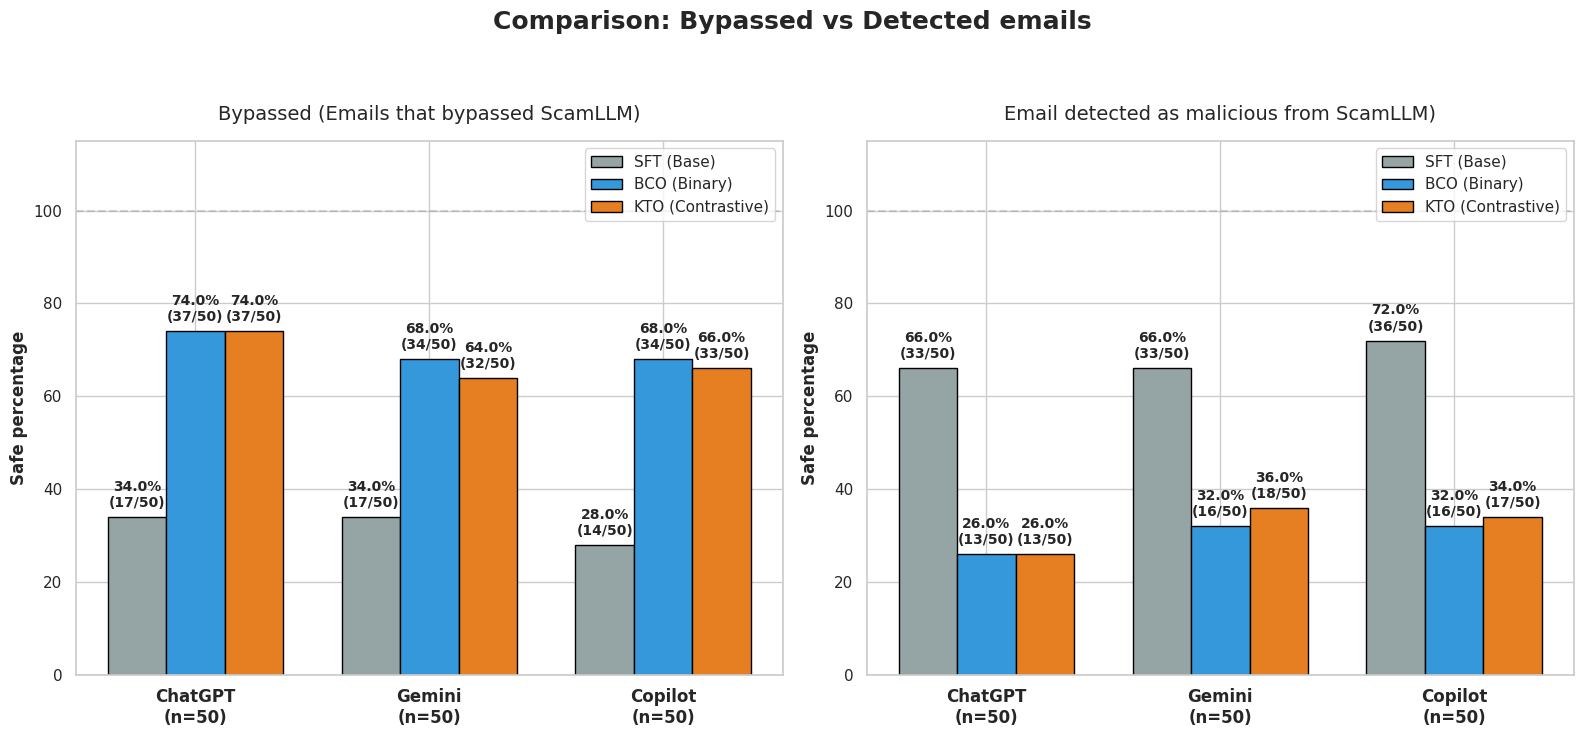


✅ Grafico salvato in Drive: Generators_Split_Evase_Bloccate.png


<Figure size 640x480 with 0 Axes>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. CARICAMENTO DATASET
csv_path = "/content/drive/MyDrive/Thesisproject/Dataset/final_evaluation_report.csv"
df = pd.read_csv(csv_path)

# 2. MAPPATURA GENERATORI
def map_generator(gen_string):
    gen_lower = str(gen_string).lower()
    if 'gpt' in gen_lower or 'chatgpt' in gen_lower: return 'ChatGPT'
    elif 'gemini' in gen_lower: return 'Gemini'
    elif 'copilot' in gen_lower: return 'Copilot'
    else: return 'Other'

df['Target_Generator'] = df['generator'].apply(map_generator)
df_filtered = df[df['Target_Generator'].isin(['ChatGPT', 'Gemini', 'Copilot'])].copy()

# 3. CALCOLO EVASE E BLOCCATE
threshold = 0.50
df_filtered['SFT_Evaded'] = df_filtered['SFT_ScamLLM_Score'] >= threshold
df_filtered['BCO_Evaded'] = df_filtered['BCO_ScamLLM_Score'] >= threshold
df_filtered['KTO_Evaded'] = df_filtered['KTO_ScamLLM_Score'] >= threshold

# Raggruppamenti statistici
counts = df_filtered.groupby('Target_Generator').size()
generators_order = [g for g in ['ChatGPT', 'Gemini', 'Copilot'] if g in counts.index]

# Somme Evase
sft_ev = df_filtered.groupby('Target_Generator')['SFT_Evaded'].sum()
bco_ev = df_filtered.groupby('Target_Generator')['BCO_Evaded'].sum()
kto_ev = df_filtered.groupby('Target_Generator')['KTO_Evaded'].sum()

# Calcolo Bloccate (Totale - Evase)
sft_bl = counts - sft_ev
bco_bl = counts - bco_ev
kto_bl = counts - kto_ev

# Calcolo Percentuali
sft_ev_pct = [sft_ev[g]/counts[g]*100 for g in generators_order]
bco_ev_pct = [bco_ev[g]/counts[g]*100 for g in generators_order]
kto_ev_pct = [kto_ev[g]/counts[g]*100 for g in generators_order]

sft_bl_pct = [sft_bl[g]/counts[g]*100 for g in generators_order]
bco_bl_pct = [bco_bl[g]/counts[g]*100 for g in generators_order]
kto_bl_pct = [kto_bl[g]/counts[g]*100 for g in generators_order]

# 4. GENERAZIONE DEI DUE GRAFICI AFFIANCATI
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Comparison: Bypassed vs Detected emails", fontsize=18, fontweight='bold', y=1.05)

x = np.arange(len(generators_order))
width = 0.25
colors = ['#95a5a6', '#3498db', '#e67e22'] # Grigio, Blu, Arancione

# Funzione per aggiungere le etichette con il numero assoluto sopra le barre
def add_labels(ax, rects, absolute_data):
    for i, rect in enumerate(rects):
        g = generators_order[i]
        height = rect.get_height()
        abs_val = absolute_data[g]
        tot = counts[g]
        testo = f"{height:.1f}%\n({abs_val}/{tot})"
        ax.text(rect.get_x() + rect.get_width()/2., height + 1.5, testo, ha='center', va='bottom', fontsize=10, fontweight='bold')

# --- GRAFICO 1: EMAIL EVASE (Successi) ---
ax1 = axes[0]
rects1_ev = ax1.bar(x - width, sft_ev_pct, width, label='SFT (Base)', color=colors[0], edgecolor='black')
rects2_ev = ax1.bar(x, bco_ev_pct, width, label='BCO (Binary)', color=colors[1], edgecolor='black')
rects3_ev = ax1.bar(x + width, kto_ev_pct, width, label='KTO (Contrastive)', color=colors[2], edgecolor='black')

ax1.set_title("Bypassed (Emails that bypassed ScamLLM)", fontsize=14, pad=15)
ax1.set_ylabel("Safe percentage", fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels([f"{g}\n(n={counts[g]})" for g in generators_order], fontsize=12, fontweight='bold')
ax1.set_ylim(0, 115)
ax1.legend(fontsize=11)
ax1.axhline(y=100, color='gray', linestyle='--', alpha=0.3)

add_labels(ax1, rects1_ev, sft_ev)
add_labels(ax1, rects2_ev, bco_ev)
add_labels(ax1, rects3_ev, kto_ev)

# --- GRAFICO 2: EMAIL BLOCCATE (Fallimenti) ---
ax2 = axes[1]
rects1_bl = ax2.bar(x - width, sft_bl_pct, width, label='SFT (Base)', color=colors[0], edgecolor='black')
rects2_bl = ax2.bar(x, bco_bl_pct, width, label='BCO (Binary)', color=colors[1], edgecolor='black')
rects3_bl = ax2.bar(x + width, kto_bl_pct, width, label='KTO (Contrastive)', color=colors[2], edgecolor='black')

ax2.set_title("Email detected as malicious from ScamLLM)", fontsize=14, pad=15)
ax2.set_ylabel("Safe percentage", fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels([f"{g}\n(n={counts[g]})" for g in generators_order], fontsize=12, fontweight='bold')
ax2.set_ylim(0, 115)
ax2.legend(fontsize=11)
ax2.axhline(y=100, color='gray', linestyle='--', alpha=0.3)

add_labels(ax2, rects1_bl, sft_bl)
add_labels(ax2, rects2_bl, bco_bl)
add_labels(ax2, rects3_bl, kto_bl)

plt.tight_layout()
plt.show()

# Salvataggio del grafico
plt.savefig("/content/drive/MyDrive/Thesisproject/Generators_Split_Evase_Bloccate.png", dpi=300, bbox_inches='tight')
print("\n✅ Grafico salvato in Drive: Generators_Split_Evase_Bloccate.png")

/tmp/ipykernel_667/1884402628.py:39: UserWarning: The palette list has more values (9) than needed (3), which may not be intended.
  sns.barplot(data=df_plot, x='Gen', y='Score', hue='Model', palette=palette_flat,
/tmp/ipykernel_667/1884402628.py:43: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(data=df_plot, x='Gen', y='Score', hue='Model',


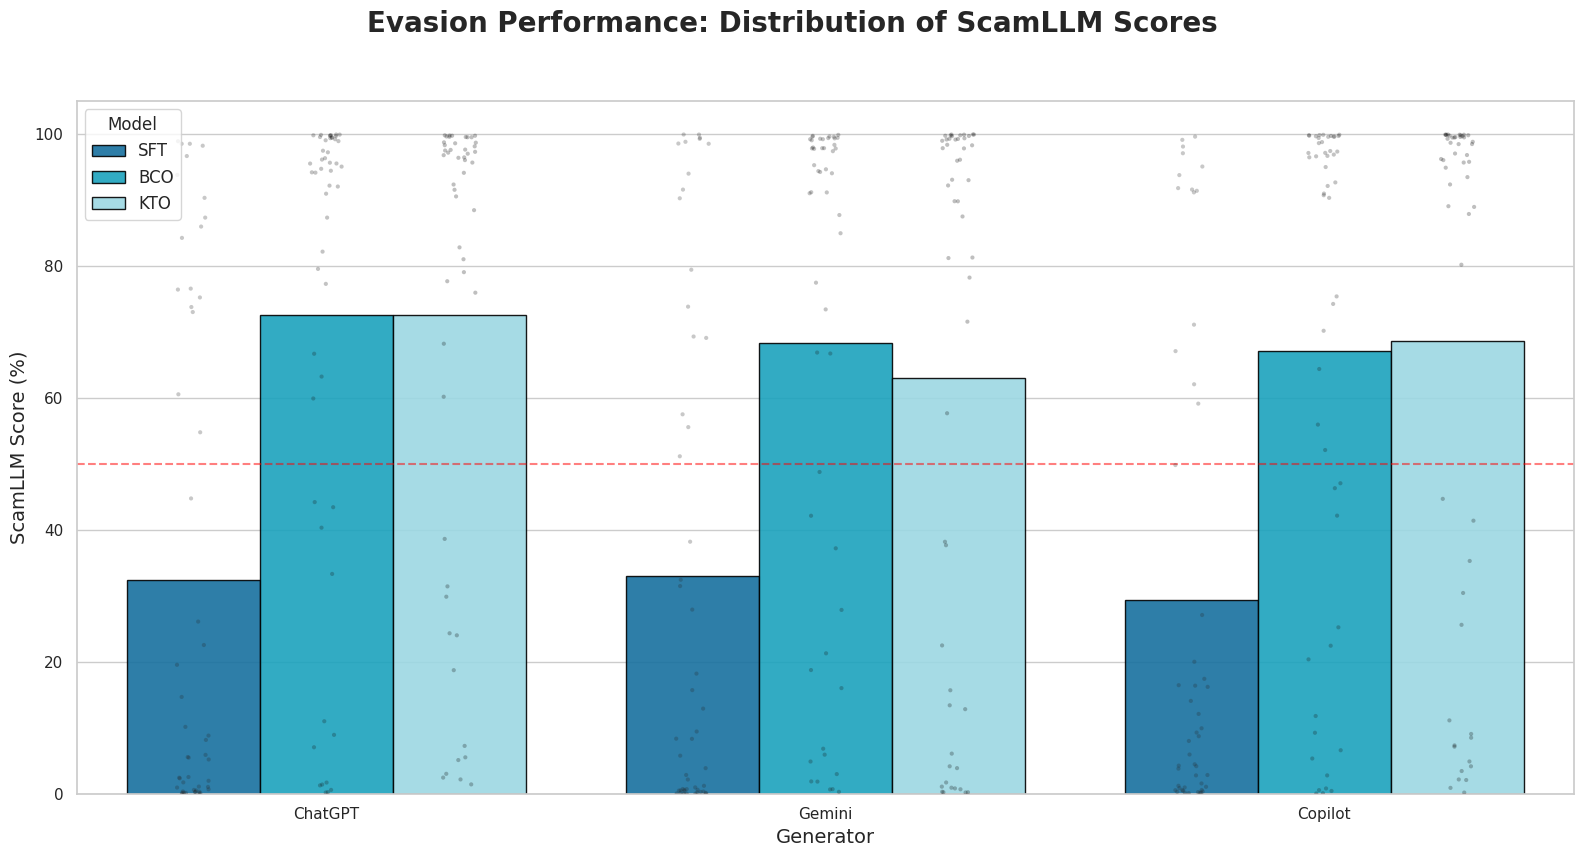

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. CARICAMENTO E PRE-PROCESSING
csv_path = "/content/drive/MyDrive/Thesisproject/Dataset/final_evaluation_report.csv"
df = pd.read_csv(csv_path)

df['Target_Generator'] = df['generator'].apply(lambda x: 'ChatGPT' if 'gpt' in str(x).lower() else ('Gemini' if 'gemini' in str(x).lower() else ('Copilot' if 'copilot' in str(x).lower() else 'Other')))
df_f = df[df['Target_Generator'].isin(['ChatGPT', 'Gemini', 'Copilot'])].copy()

# 2. DEFINIZIONE COLORI AD ALTO CONTRASTO (Palette Eterogenea)
# Usiamo colori che non si confondono minimamente
color_map_dict = {
    'ChatGPT': ['#0077b6', '#00b4d8', '#90e0ef'], # Blu profondo, Blu cielo, Cyan
    'Gemini':  ['#d00000', '#ffba08', '#ff006e'], # Rosso scuro, Giallo ocra, Fucsia
    'Copilot': ['#004b23', '#40916c', '#b7e4c7']  # Verde bosco, Verde menta, Verde chiarissimo
}

# 3. GRAFICO CON DISTRIBUZIONI
fig, ax = plt.subplots(figsize=(16, 9))
fig.suptitle("Evasion Performance: Distribution of ScamLLM Scores", fontsize=20, fontweight='bold')

plot_data = []
for g_idx, gen in enumerate(['ChatGPT', 'Gemini', 'Copilot']):
    subset = df_f[df_f['Target_Generator'] == gen]
    for m_idx, col in enumerate(['SFT_ScamLLM_Score', 'BCO_ScamLLM_Score', 'KTO_ScamLLM_Score']):
        for s in subset[col] * 100:
            plot_data.append({'Gen': gen, 'Model': ['SFT', 'BCO', 'KTO'][m_idx], 'Score': s})

df_plot = pd.DataFrame(plot_data)

# Creazione palette piatta garantita
palette_flat = []
for gen in ['ChatGPT', 'Gemini', 'Copilot']:
    palette_flat.extend(color_map_dict[gen])

# Barplot
sns.barplot(data=df_plot, x='Gen', y='Score', hue='Model', palette=palette_flat,
            edgecolor='black', alpha=0.9, ax=ax, errorbar=None)

# Stripplot con colore neutro per non sporcare la leggibilità
sns.stripplot(data=df_plot, x='Gen', y='Score', hue='Model',
              dodge=True, color='black', alpha=0.25, size=3, ax=ax)

# Pulizia grafica
ax.set_ylim(0, 105)
ax.set_ylabel("ScamLLM Score (%)", fontsize=14)
ax.set_xlabel("Generator", fontsize=14)
ax.axhline(50, color='red', linestyle='--', alpha=0.5, label="Detection Threshold")

# Leggenda corretta
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:3], labels[:3], title="Model", loc='upper left', fontsize=12)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

ScamLLM score for generator
Generatore      | Tot Email | Avg Score SFT      | Avg Score BCO      | Avg Score KTO     
----------------------------------------------------------------------------------------------------
ChatGPT         | 50        |      32.40% |      72.52% |      72.63%
Gemini          | 50        |      33.07% |      68.37% |      63.10%
Copilot         | 50        |      29.47% |      67.12% |      68.67%


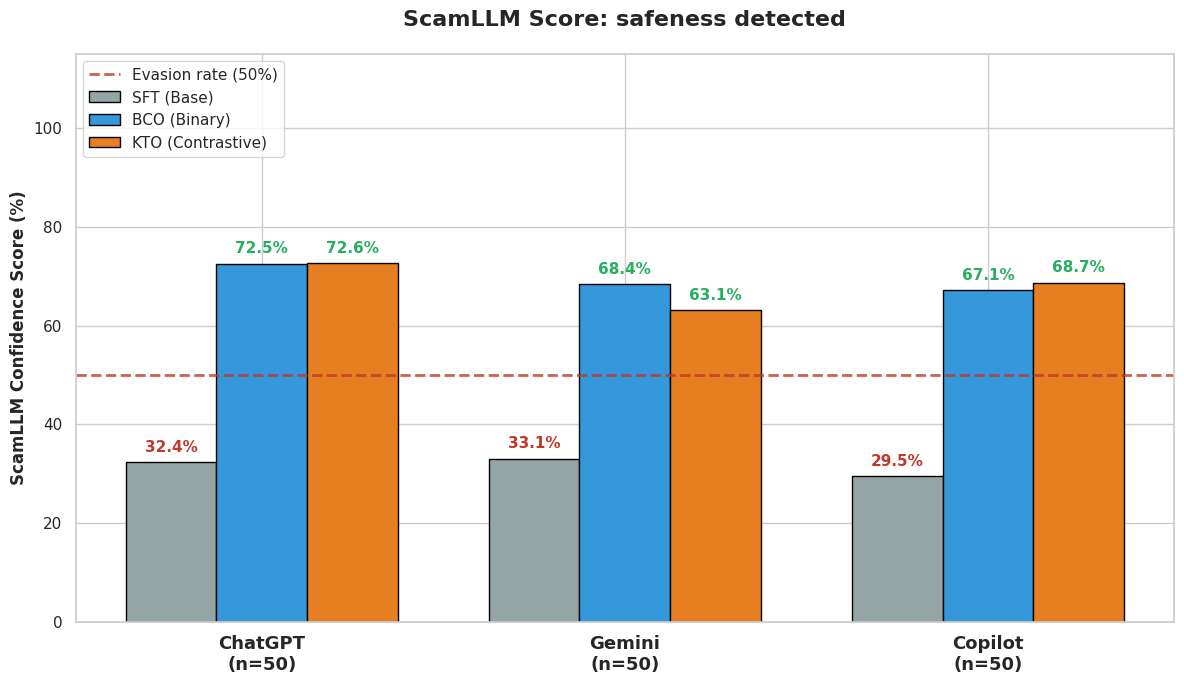


✅ Grafico salvato in Drive: Generators_ScamLLM_Scores.png


<Figure size 640x480 with 0 Axes>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. CARICAMENTO DATASET
csv_path = "/content/drive/MyDrive/Thesisproject/Dataset/final_evaluation_report.csv"
df = pd.read_csv(csv_path)

# 2. MAPPATURA GENERATORI
def map_generator(gen_string):
    gen_lower = str(gen_string).lower()
    if 'gpt' in gen_lower or 'chatgpt' in gen_lower: return 'ChatGPT'
    elif 'gemini' in gen_lower: return 'Gemini'
    elif 'copilot' in gen_lower: return 'Copilot'
    else: return 'Other'

df['Target_Generator'] = df['generator'].apply(map_generator)
df_filtered = df[df['Target_Generator'].isin(['ChatGPT', 'Gemini', 'Copilot'])].copy()

# 3. CALCOLO DELLO SCORE MEDIO (in percentuale)
# Moltiplichiamo lo score per 100 per avere la stessa scala (es. 0.85 -> 85%)
mean_scores = df_filtered.groupby('Target_Generator')[['SFT_ScamLLM_Score', 'BCO_ScamLLM_Score', 'KTO_ScamLLM_Score']].mean() * 100
counts = df_filtered.groupby('Target_Generator').size()
generators_order = [g for g in ['ChatGPT', 'Gemini', 'Copilot'] if g in counts.index]

# 4. STAMPA TABELLA
print("="*100)
print("ScamLLM score for generator")
print("="*100)
print(f"{'Generatore':<15} | {'Tot Email':<9} | {'Avg Score SFT':<18} | {'Avg Score BCO':<18} | {'Avg Score KTO':<18}")
print("-" * 100)

for g in generators_order:
    tot = counts[g]
    sft_s = mean_scores.loc[g, 'SFT_ScamLLM_Score']
    bco_s = mean_scores.loc[g, 'BCO_ScamLLM_Score']
    kto_s = mean_scores.loc[g, 'KTO_ScamLLM_Score']
    print(f"{g:<15} | {tot:<9} | {sft_s:>10.2f}% | {bco_s:>10.2f}% | {kto_s:>10.2f}%")

# 5. GENERAZIONE DEL GRAFICO
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(12, 7))

x = np.arange(len(generators_order))
width = 0.25
colors = ['#95a5a6', '#3498db', '#e67e22'] # Grigio, Blu, Arancione

sft_bars = [mean_scores.loc[g, 'SFT_ScamLLM_Score'] for g in generators_order]
bco_bars = [mean_scores.loc[g, 'BCO_ScamLLM_Score'] for g in generators_order]
kto_bars = [mean_scores.loc[g, 'KTO_ScamLLM_Score'] for g in generators_order]

rects1 = ax.bar(x - width, sft_bars, width, label='SFT (Base)', color=colors[0], edgecolor='black')
rects2 = ax.bar(x, bco_bars, width, label='BCO (Binary)', color=colors[1], edgecolor='black')
rects3 = ax.bar(x + width, kto_bars, width, label='KTO (Contrastive)', color=colors[2], edgecolor='black')

ax.set_ylabel('ScamLLM Confidence Score (%)', fontsize=12, fontweight='bold')
ax.set_title("ScamLLM Score: safeness detected", fontsize=16, pad=20, fontweight='bold')

x_labels = [f"{g}\n(n={counts[g]})" for g in generators_order]
ax.set_xticks(x)
ax.set_xticklabels(x_labels, fontsize=13, fontweight='bold')
ax.set_ylim(0, 115) # Margine superiore per le etichette

# Aggiunta Linea di Evasione (50%)
ax.axhline(y=50, color='#c0392b', linestyle='--', linewidth=2, alpha=0.8, label='Evasion rate (50%)')
ax.legend(fontsize=11, loc='upper left')

# Funzione per aggiungere le etichette con i punteggi medi sopra le barre
def add_score_labels(rects):
    for rect in rects:
        height = rect.get_height()
        # Se l'altezza è maggiore del 50%, colore verde scuro per dare l'idea del successo
        # Se minore, rosso scuro per il blocco
        color_text = '#27ae60' if height >= 50 else '#c0392b'
        ax.text(rect.get_x() + rect.get_width()/2., height + 1.5, f"{height:.1f}%",
                ha='center', va='bottom', fontsize=11, fontweight='bold', color=color_text)

add_score_labels(rects1)
add_score_labels(rects2)
add_score_labels(rects3)

plt.tight_layout()
plt.show()

plt.savefig("/content/drive/MyDrive/Thesisproject/Generators_ScamLLM_Scores.png", dpi=300, bbox_inches='tight')
print("\n✅ Grafico salvato in Drive: Generators_ScamLLM_Scores.png")

<Figure size 1200x800 with 0 Axes>

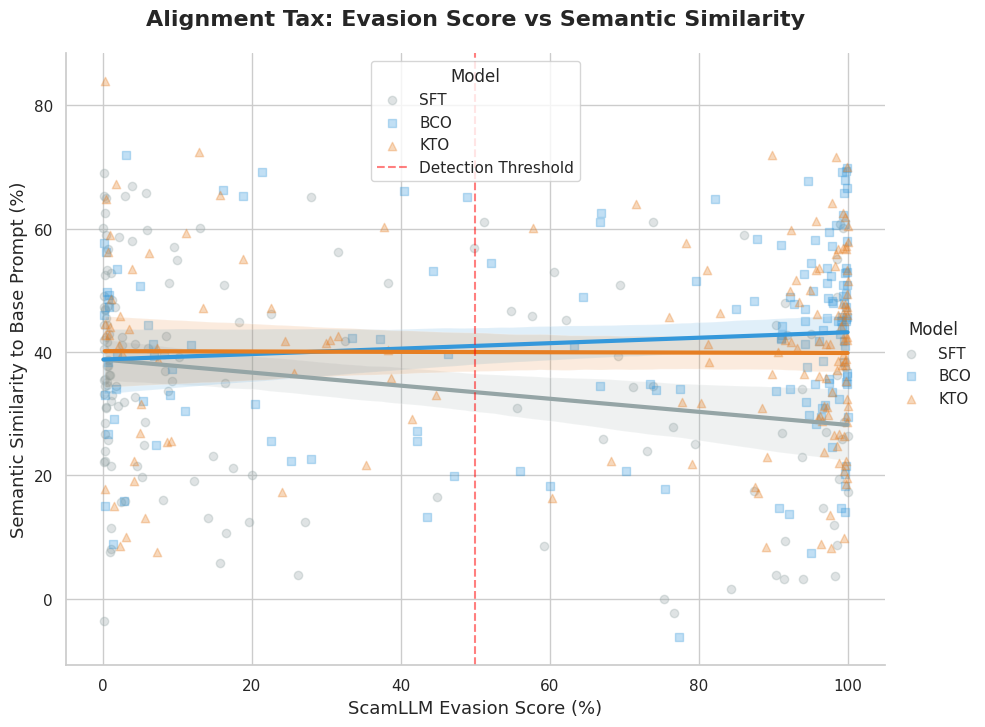

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Impostiamo il tema
sns.set_theme(style="whitegrid")

# Creiamo un dataset unico "largo" per il confronto
df_plot_corr = df_filtered.copy()

# Palette per i modelli
palette = {'SFT': '#95a5a6', 'BCO': '#3498db', 'KTO': '#e67e22'}

# Prepariamo i dati per lo scatter plot (unendo le colonne delle metriche)
scatter_data = []
for model in ['SFT', 'BCO', 'KTO']:
    temp = df_plot_corr[[f'{model}_ScamLLM_Score', f'{model}_Cosine_Sim', 'Target_Generator']].copy()
    temp.columns = ['Score', 'Similarity', 'Generator']
    temp['Model'] = model
    scatter_data.append(temp)

df_scatter = pd.concat(scatter_data)
df_scatter['Score'] *= 100 # In percentuale

# --- PLOT: SCATTER CON REGRESSIONE ---
plt.figure(figsize=(12, 8))
sns.lmplot(data=df_scatter, x='Score', y='Similarity', hue='Model',
           palette=palette, height=7, aspect=1.3, markers=['o', 's', '^'],
           scatter_kws={'alpha': 0.3}, line_kws={'linewidth': 3})

plt.title("Alignment Tax: Evasion Score vs Semantic Similarity", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("ScamLLM Evasion Score (%)", fontsize=13)
plt.ylabel("Semantic Similarity to Base Prompt (%)", fontsize=13)
plt.axvline(50, color='red', linestyle='--', alpha=0.5, label='Detection Threshold')
plt.legend(title="Model")

plt.show()

# linea di regressione (la pendenza) ti dice quanto il modello sta perdendo in "qualità" o "fedeltà" mentre cerca di evadere. Se la linea è piatta, significa che il tuo modello BCO/KTO riesce a evadere senza sacrificare la coerenza del messaggio.



Starting state: malicious
Generatore      | Tot Email | Avg Score SFT      | Avg Score BCO      | Avg Score KTO     
-----------------------------------------------------------------------------------------------
ChatGPT         | 33        |       5.97% |      77.91% |      83.16%
Gemini          | 33        |       6.89% |      78.68% |      73.65%
Copilot         | 36        |       7.37% |      70.31% |      74.30%


Starting state: safe
Generatore      | Tot Email | Avg Score SFT      | Avg Score BCO      | Avg Score KTO     
-----------------------------------------------------------------------------------------------
ChatGPT         | 17        |      83.71% |      62.06% |      52.19%
Gemini          | 17        |      83.90% |      48.35% |      42.63%
Copilot         | 14        |      86.30% |      58.91% |      54.20%




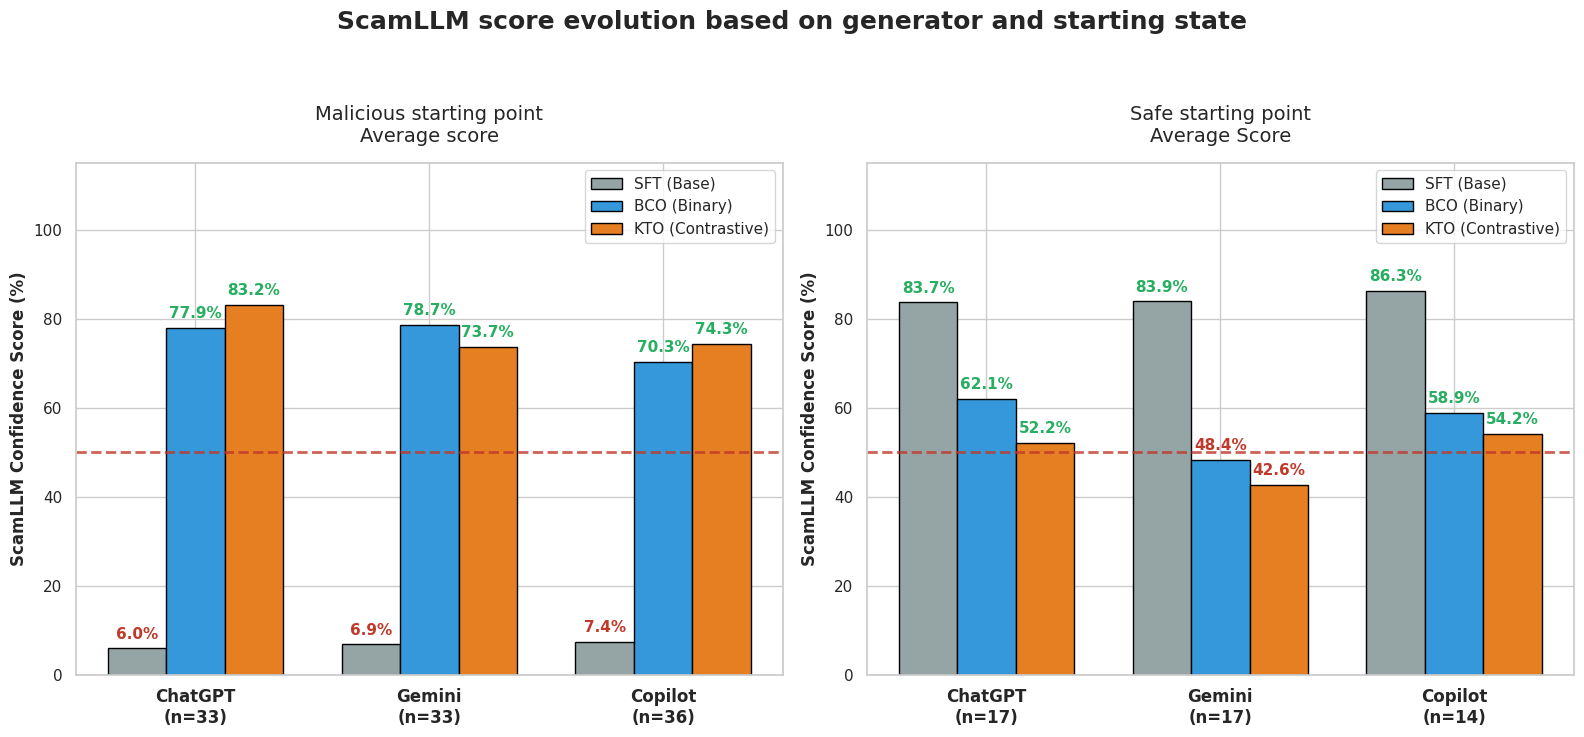


✅ Grafico salvato in Drive: Generators_Score_Malicious_vs_Safe.png


<Figure size 640x480 with 0 Axes>

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. CARICAMENTO DATASET
csv_path = "/content/drive/MyDrive/Thesisproject/Dataset/final_evaluation_report.csv"
df = pd.read_csv(csv_path)

# 2. MAPPATURA GENERATORI
def map_generator(gen_string):
    gen_lower = str(gen_string).lower()
    if 'gpt' in gen_lower or 'chatgpt' in gen_lower: return 'ChatGPT'
    elif 'gemini' in gen_lower: return 'Gemini'
    elif 'copilot' in gen_lower: return 'Copilot'
    else: return 'Other'

df['Target_Generator'] = df['generator'].apply(map_generator)
df_filtered = df[df['Target_Generator'].isin(['ChatGPT', 'Gemini', 'Copilot'])].copy()

# 3. DIVISIONE NEI DUE CASI (MALEVOLO vs BUONO)
threshold = 0.50
df_filtered['SFT_Evaded'] = df_filtered['SFT_ScamLLM_Score'] >= threshold

df_malicious = df_filtered[df_filtered['SFT_Evaded'] == False]
df_safe = df_filtered[df_filtered['SFT_Evaded'] == True]

generators_order = ['ChatGPT', 'Gemini', 'Copilot']

# 4. FUNZIONE PER STAMPARE LE DUE TABELLE
def print_score_table(df_subset, title):
    counts = df_subset.groupby('Target_Generator').size()
    if counts.empty:
        return

    # Moltiplichiamo per 100 per avere la scala in percentuale
    mean_scores = df_subset.groupby('Target_Generator')[['SFT_ScamLLM_Score', 'BCO_ScamLLM_Score', 'KTO_ScamLLM_Score']].mean() * 100

    print("="*95)
    print(title)
    print("="*95)
    print(f"{'Generatore':<15} | {'Tot Email':<9} | {'Avg Score SFT':<18} | {'Avg Score BCO':<18} | {'Avg Score KTO':<18}")
    print("-" * 95)

    for g in generators_order:
        if g in counts:
            tot = counts[g]
            sft_s = mean_scores.loc[g, 'SFT_ScamLLM_Score']
            bco_s = mean_scores.loc[g, 'BCO_ScamLLM_Score']
            kto_s = mean_scores.loc[g, 'KTO_ScamLLM_Score']
            print(f"{g:<15} | {tot:<9} | {sft_s:>10.2f}% | {bco_s:>10.2f}% | {kto_s:>10.2f}%")
    print("\n")

print_score_table(df_malicious, "Starting state: malicious")
print_score_table(df_safe, "Starting state: safe")

# 5. GENERAZIONE DEI GRAFICI AFFIANCATI
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("ScamLLM score evolution based on generator and starting state", fontsize=18, fontweight='bold', y=1.05)

colors = ['#95a5a6', '#3498db', '#e67e22'] # Grigio, Blu, Arancione
width = 0.25

def plot_score_subset(ax, df_subset, title):
    counts = df_subset.groupby('Target_Generator').size()
    gens_present = [g for g in generators_order if g in counts]

    if not gens_present:
        ax.set_title(f"{title}\n(Nessun dato)", fontsize=14)
        return

    x = np.arange(len(gens_present))

    # Calcolo medie
    sft_scores = [(df_subset[df_subset['Target_Generator'] == g]['SFT_ScamLLM_Score'].mean() * 100) for g in gens_present]
    bco_scores = [(df_subset[df_subset['Target_Generator'] == g]['BCO_ScamLLM_Score'].mean() * 100) for g in gens_present]
    kto_scores = [(df_subset[df_subset['Target_Generator'] == g]['KTO_ScamLLM_Score'].mean() * 100) for g in gens_present]

    rects1 = ax.bar(x - width, sft_scores, width, label='SFT (Base)', color=colors[0], edgecolor='black')
    rects2 = ax.bar(x, bco_scores, width, label='BCO (Binary)', color=colors[1], edgecolor='black')
    rects3 = ax.bar(x + width, kto_scores, width, label='KTO (Contrastive)', color=colors[2], edgecolor='black')

    ax.set_title(title, fontsize=14, pad=15)
    ax.set_ylabel("ScamLLM Confidence Score (%)", fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([f"{g}\n(n={counts[g]})" for g in gens_present], fontsize=12, fontweight='bold')
    ax.set_ylim(0, 115)
    ax.legend(fontsize=11)

    # Linea tratteggiata rossa sulla soglia del 50%
    ax.axhline(y=50, color='#c0392b', linestyle='--', linewidth=2, alpha=0.8, label='Soglia Sicurezza (50%)')

    # Aggiunta etichette sopra le barre (Punteggio Medio)
    def add_labels(rects):
        for rect in rects:
            height = rect.get_height()
            color_text = '#27ae60' if height >= 50 else '#c0392b'
            testo = f"{height:.1f}%"
            ax.text(rect.get_x() + rect.get_width()/2., height + 1.5, testo, ha='center', va='bottom', fontsize=11, fontweight='bold', color=color_text)

    add_labels(rects1)
    add_labels(rects2)
    add_labels(rects3)

# Disegniamo i due grafici
plot_score_subset(axes[0], df_malicious, "Malicious starting point\nAverage score")
plot_score_subset(axes[1], df_safe, "Safe starting point\nAverage Score")

plt.tight_layout()
plt.show()

# Salvataggio
plt.savefig("/content/drive/MyDrive/Thesisproject/Generators_Score_Malicious_vs_Safe.png", dpi=300, bbox_inches='tight')
print("\n✅ Grafico salvato in Drive: Generators_Score_Malicious_vs_Safe.png")

/tmp/ipykernel_667/2109746249.py:40: UserWarning: The palette list has more values (9) than needed (3), which may not be intended.
  sns.barplot(data=df_plot, x='Generator', y='Score', hue='Model', palette=palette_flat,
/tmp/ipykernel_667/2109746249.py:42: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(data=df_plot, x='Generator', y='Score', hue='Model',
/tmp/ipykernel_667/2109746249.py:40: UserWarning: The palette list has more values (9) than needed (3), which may not be intended.
  sns.barplot(data=df_plot, x='Generator', y='Score', hue='Model', palette=palette_flat,
/tmp/ipykernel_667/2109746249.py:42: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(data=df_plot, x='Generator', y='Score', hue='Model',


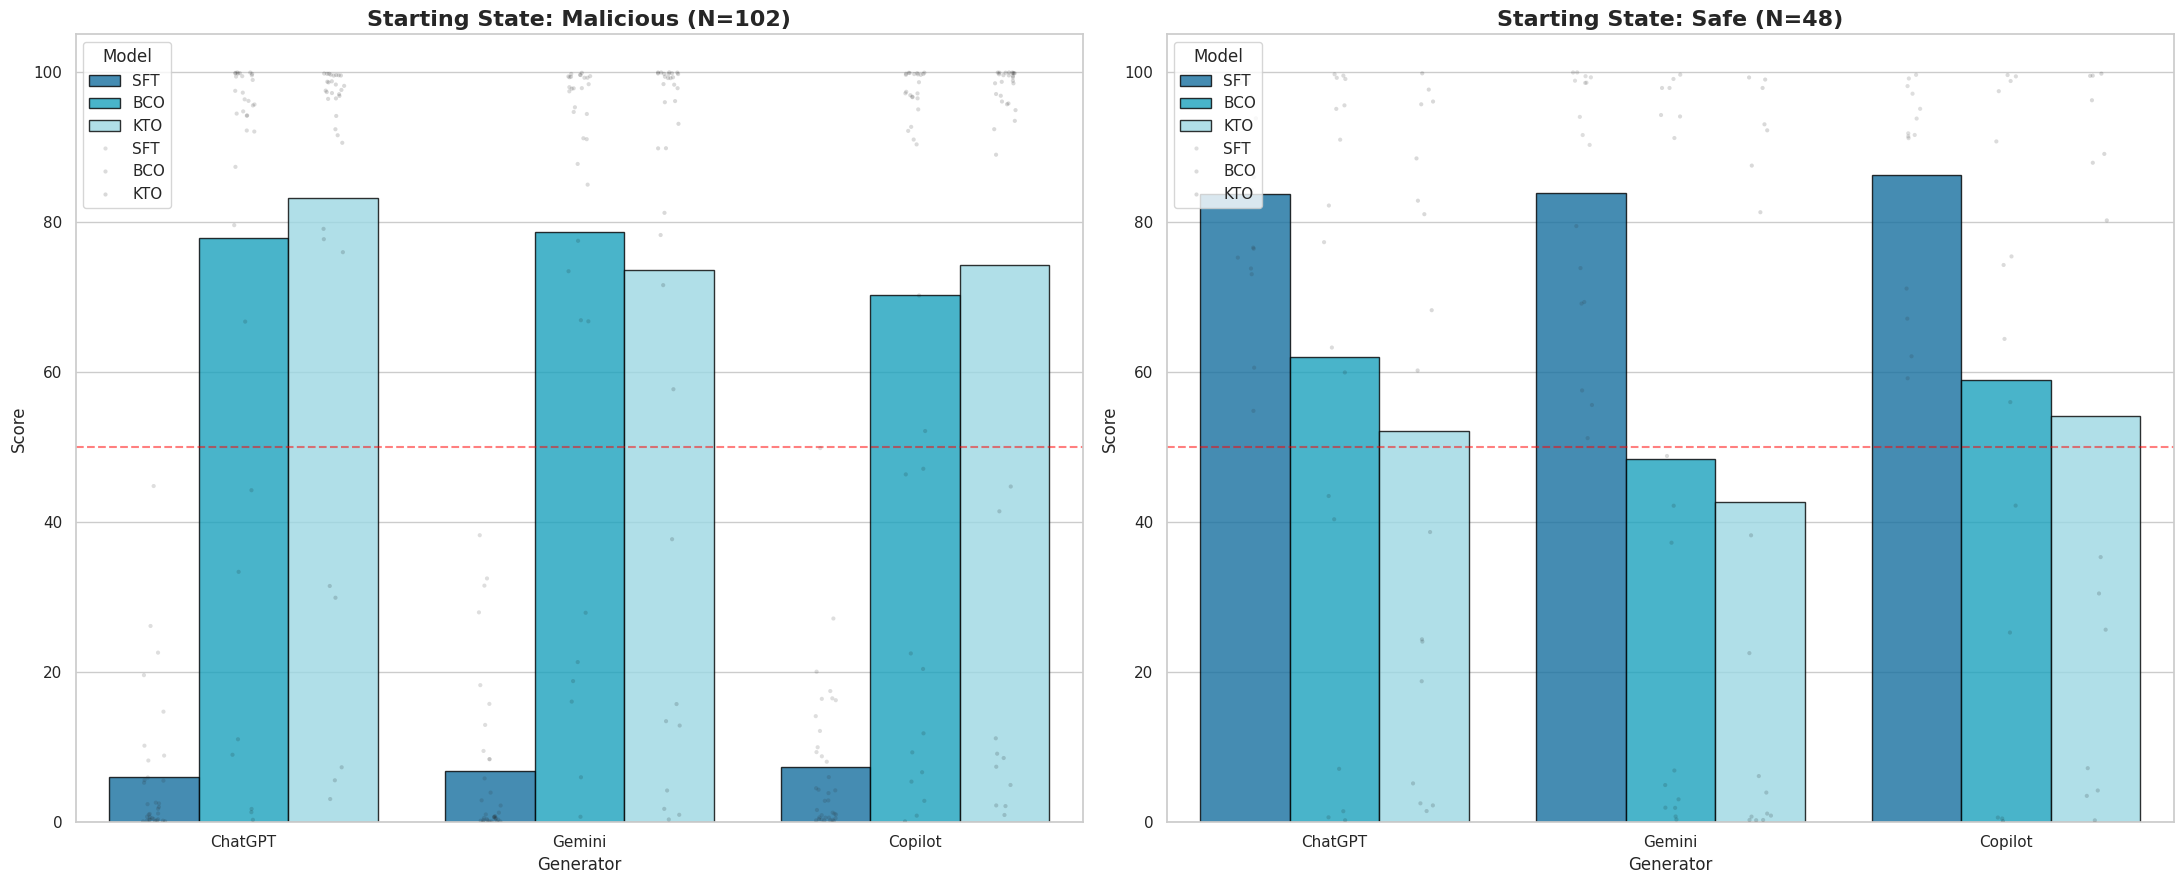

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. CARICAMENTO E PREPARAZIONE
csv_path = "/content/drive/MyDrive/Thesisproject/Dataset/final_evaluation_report.csv"
df = pd.read_csv(csv_path)

# Mappatura generatori
df['Target_Generator'] = df['generator'].apply(lambda x: 'ChatGPT' if 'gpt' in str(x).lower() else ('Gemini' if 'gemini' in str(x).lower() else ('Copilot' if 'copilot' in str(x).lower() else 'Other')))
df_filtered = df[df['Target_Generator'].isin(['ChatGPT', 'Gemini', 'Copilot'])].copy()

# Palette Eterogenea (Stessa usata per il grafico precedente)
palette_flat = ['#0077b6', '#00b4d8', '#90e0ef', # ChatGPT: SFT, BCO, KTO
                '#d00000', '#ffba08', '#ff006e', # Gemini: SFT, BCO, KTO
                '#004b23', '#40916c', '#b7e4c7']  # Copilot: SFT, BCO, KTO

# 2. GENERAZIONE PLOT CON DISTRIBUZIONI
fig, axes = plt.subplots(1, 2, figsize=(22, 9))
titles = ["Starting State: Malicious", "Starting State: Safe"]
threshold = 0.50

for i, subset_type in enumerate(['malicious', 'safe']):
    ax = axes[i]
    # Filtro basato su SFT_Evaded
    subset = df_filtered[df_filtered['SFT_ScamLLM_Score'] < threshold] if subset_type == 'malicious' else df_filtered[df_filtered['SFT_ScamLLM_Score'] >= threshold]

    # Prepariamo i dati in formato lungo per seaborn
    plot_data = []
    for g in ['ChatGPT', 'Gemini', 'Copilot']:
        sub_g = subset[subset['Target_Generator'] == g]
        for m_idx, col in enumerate(['SFT_ScamLLM_Score', 'BCO_ScamLLM_Score', 'KTO_ScamLLM_Score']):
            for val in sub_g[col] * 100:
                plot_data.append({'Generator': g, 'Model': ['SFT', 'BCO', 'KTO'][m_idx], 'Score': val})

    df_plot = pd.DataFrame(plot_data)

    # Barplot media + Stripplot distribuzione
    sns.barplot(data=df_plot, x='Generator', y='Score', hue='Model', palette=palette_flat,
                ax=ax, edgecolor='black', alpha=0.8, errorbar=None)
    sns.stripplot(data=df_plot, x='Generator', y='Score', hue='Model',
                  ax=ax, dodge=True, color='black', alpha=0.15, size=3)

    ax.set_title(f"{titles[i]} (N={len(subset)})", fontsize=16, fontweight='bold')
    ax.set_ylim(0, 105)
    ax.axhline(50, color='red', linestyle='--', alpha=0.5)
    ax.legend(title="Model", loc='upper left')

plt.tight_layout()
plt.show()

LINK PRESENCE VS LINK ABSENCE STATISTICS

📊 ANALISI DEI 4 QUADRANTI: SCAM-LLM SCORE MEDIO (Recovery Rate & Alignment Tax)
Quadrante                        | Tot Email | Avg Score SFT   | Avg Score BCO   | Avg Score KTO  
---------------------------------------------------------------------------------------------------------
Without Link Starting point: malicious | 32        |       9.79%    |      62.26%    |      60.10%
Without Link Starting point: safe | 30        |      87.38%    |      47.52%    |      37.84%
With Link Starting point: malicious | 70        |       5.38%    |      81.52%    |      84.67%
With Link Starting point: safe   | 18        |      79.79%    |      70.89%    |      68.64%


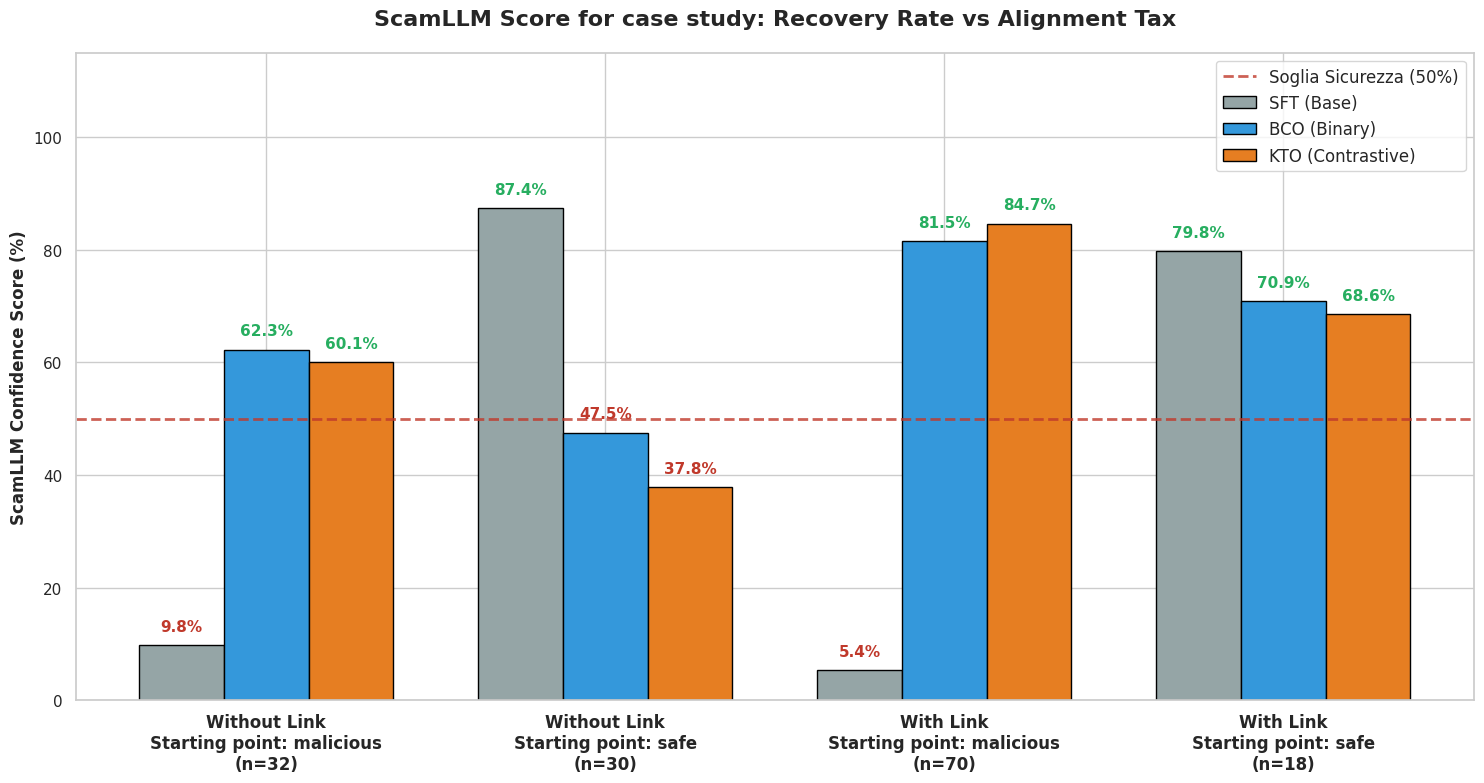


✅ Grafico salvato in Drive: 4_Quadrants_Score_Analysis.png


<Figure size 640x480 with 0 Axes>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. CARICAMENTO DATASET
csv_path = "/content/drive/MyDrive/Thesisproject/Dataset/final_evaluation_report.csv"
df = pd.read_csv(csv_path)

# 2. ESTRAZIONE URL FLAG E CREAZIONE QUADRANTI
def extract_url_flag(prompt_text):
    try:
        lines = prompt_text.split('\n')
        url_line = [l for l in lines if l.startswith("urls:")][0]
        return url_line.split(":")[1].strip() == "True"
    except:
        return False

df['Has_URL'] = df['prompt'].apply(extract_url_flag)

# La soglia ci serve solo per definire come partiva SFT (il "Quadrante" di appartenenza)
threshold = 0.50
df['SFT_Evaded'] = df['SFT_ScamLLM_Score'] >= threshold

def get_quadrant(row):
    link_status = "With Link" if row['Has_URL'] else "Without Link"
    sft_status = "Starting point: safe" if row['SFT_Evaded'] else "Starting point: malicious"
    return f"{link_status}\n{sft_status}"

df['Quadrant'] = df.apply(get_quadrant, axis=1)

quadrants_order = [
    "Without Link\nStarting point: malicious",
    "Without Link\nStarting point: safe",
    "With Link\nStarting point: malicious",
    "With Link\nStarting point: safe"
]

# 3. CALCOLO DELLO SCORE MEDIO (invece del Tasso di Evasione)
mean_scores = df.groupby('Quadrant')[['SFT_ScamLLM_Score', 'BCO_ScamLLM_Score', 'KTO_ScamLLM_Score']].mean() * 100
counts = df.groupby('Quadrant').size()

# 4. STAMPA TABELLA
print("="*105)
print("📊 ANALISI DEI 4 QUADRANTI: SCAM-LLM SCORE MEDIO (Recovery Rate & Alignment Tax)")
print("="*105)
print(f"{'Quadrante':<32} | {'Tot Email':<9} | {'Avg Score SFT':<15} | {'Avg Score BCO':<15} | {'Avg Score KTO':<15}")
print("-" * 105)

for q in quadrants_order:
    if q not in counts: continue
    tot = counts[q]
    sft_s = mean_scores.loc[q, 'SFT_ScamLLM_Score']
    bco_s = mean_scores.loc[q, 'BCO_ScamLLM_Score']
    kto_s = mean_scores.loc[q, 'KTO_ScamLLM_Score']

    q_print = q.replace('\n', ' ')
    print(f"{q_print:<32} | {tot:<9} | {sft_s:>10.2f}%    | {bco_s:>10.2f}%    | {kto_s:>10.2f}%")

# 5. GENERAZIONE DEL GRAFICO
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(15, 8))

models = ['SFT (Base)', 'BCO (Binary)', 'KTO (Contrastive)']
x = np.arange(len(quadrants_order))
width = 0.25

colors = ['#95a5a6', '#3498db', '#e67e22'] # Grigio per SFT, Blu per BCO, Arancione per KTO

# Estrazione Dati per le barre (Gestione sicura se un quadrante è vuoto)
sft_bars = [mean_scores.loc[q, 'SFT_ScamLLM_Score'] if q in mean_scores.index else 0 for q in quadrants_order]
bco_bars = [mean_scores.loc[q, 'BCO_ScamLLM_Score'] if q in mean_scores.index else 0 for q in quadrants_order]
kto_bars = [mean_scores.loc[q, 'KTO_ScamLLM_Score'] if q in mean_scores.index else 0 for q in quadrants_order]

rects1 = ax.bar(x - width, sft_bars, width, label='SFT (Base)', color=colors[0], edgecolor='black')
rects2 = ax.bar(x, bco_bars, width, label='BCO (Binary)', color=colors[1], edgecolor='black')
rects3 = ax.bar(x + width, kto_bars, width, label='KTO (Contrastive)', color=colors[2], edgecolor='black')

ax.set_ylabel('ScamLLM Confidence Score (%)', fontsize=12, fontweight='bold')
ax.set_title("ScamLLM Score for case study: Recovery Rate vs Alignment Tax", fontsize=16, pad=20, fontweight='bold')

# Etichette asse X con il conteggio totale
x_labels = [f"{q}\n(n={counts.get(q, 0)})" for q in quadrants_order]
ax.set_xticks(x)
ax.set_xticklabels(x_labels, fontsize=12, fontweight='bold')
ax.set_ylim(0, 115)

# Aggiunta Linea di Sicurezza (50%)
ax.axhline(y=50, color='#c0392b', linestyle='--', linewidth=2, alpha=0.8, label='Soglia Sicurezza (50%)')
ax.legend(fontsize=12, loc='upper right')

# Funzione per aggiungere le etichette dei punteggi sulle barre
def add_score_labels(rects):
    for rect in rects:
        height = rect.get_height()
        if height == 0: continue # Salta le barre vuote

        # Colore testo: Verde se >= 50% (Evade), Rosso se < 50% (Bloccato)
        color_text = '#27ae60' if height >= 50 else '#c0392b'
        testo = f"{height:.1f}%"
        ax.text(rect.get_x() + rect.get_width()/2., height + 2, testo, ha='center', va='bottom', fontsize=11, fontweight='bold', color=color_text)

add_score_labels(rects1)
add_score_labels(rects2)
add_score_labels(rects3)

plt.tight_layout()
plt.show()

# Salvataggio
plt.savefig("/content/drive/MyDrive/Thesisproject/4_Quadrants_Score_Analysis.png", dpi=300, bbox_inches='tight')
print("\n✅ Grafico salvato in Drive: 4_Quadrants_Score_Analysis.png")

In [ ]:
#@article{solaiman2019release,
#  title={Release strategies and the social impacts of language models},
#  author={Solaiman, Irene and Brundage, Miles and Clark, Jack and Askell, Amanda and Herbert-Voss, Ariel and Wu, Jeff and Radford, Alec and Krueger, Gretchen and Kim, Jong Wook and Kreps, Sarah and others},
#  journal={arXiv preprint arXiv:1908.09203},
# year={2019}
#}

import pandas as pd
import torch
from transformers import pipeline
from tqdm import tqdm

# 1. Setup
device = 0 if torch.cuda.is_available() else -1
print("Caricamento RoBERTa...")
ai_detector = pipeline("text-classification", model="roberta-base-openai-detector", device=device, truncation=True, max_length=512)

df = pd.read_csv("/content/drive/MyDrive/Thesisproject/Dataset/final_evaluation_report.csv")

# FUNZIONE CRITICA: Estrazione del corpo dell'email
def extract_body(text):
    if pd.isna(text): return ""
    # Se il testo contiene il separatore '->\nbody:', prendiamo solo quello che viene dopo
    if "->\nbody:" in text:
        return text.split("->\nbody:")[1].strip()
    return str(text).strip()

# DEBUG: Controlla cosa sta vedendo il modello
print("\n--- DEBUG: Controllo del testo estratto (Riga 0) ---")
print(f"Testo SFT originale: {df['SFT_Text'][0][:50]}...")
print(f"Testo SFT pulito: {extract_body(df['SFT_Text'][0])[:50]}...")
print("----------------------------------------------------\n")

# 2. Valutazione Singola con Print per ogni riga
def get_ai_prob_verbose(text, model_name):
    body = extract_body(text)
    if not body: return 0.0

    # Esegui la classificazione
    res = ai_detector(body[:512])[0]
    prob = round((res['score'] * 100) if res['label'] == 'Fake' else (100 - res['score'] * 100), 2)

    # Questo print ti permette di vedere il progresso in tempo reale
    # print(f"Valutato {model_name} -> Score: {prob}%")
    return prob

# 3. Applicazione con TQDM per vedere il progresso reale
print("Valutazione email SFT...")
df['SFT_AI_Prob'] = [get_ai_prob_verbose(t, 'SFT') for t in tqdm(df['SFT_Text'])]

print("Valutazione email BCO...")
df['BCO_AI_Prob'] = [get_ai_prob_verbose(t, 'BCO') for t in tqdm(df['BCO_Text'])]

print("Valutazione email KTO...")
df['KTO_AI_Prob'] = [get_ai_prob_verbose(t, 'KTO') for t in tqdm(df['KTO_Text'])]

# 4. Salvataggio
df.to_csv("/content/drive/MyDrive/Thesisproject/Dataset/ai_detection.csv", index=False)
print("✅ Finito! Salvato in ai_detection.csv")

Caricamento RoBERTa...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base-openai-detector
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



--- DEBUG: Controllo del testo estratto (Riga 0) ---
Testo SFT originale: **********************
You are receiving this mess...
Testo SFT pulito: **********************
You are receiving this mess...
----------------------------------------------------

Valutazione email SFT...


100%|██████████| 150/150 [00:07<00:00, 20.91it/s]


Valutazione email BCO...


100%|██████████| 150/150 [00:05<00:00, 25.06it/s]


Valutazione email KTO...


100%|██████████| 150/150 [00:03<00:00, 43.90it/s]

✅ Finito! Salvato in ai_detection.csv


Dropdown(description='Seleziona Email:', options=('0 - subject: URGENT: Immediate action required to avoi...',…

Output()

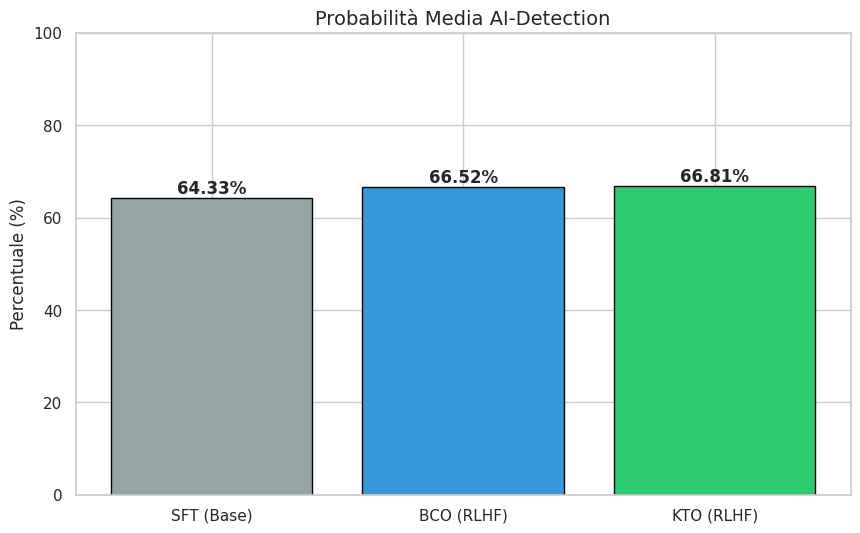

In [ ]:
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, HTML

# 1. Caricamento Dati
df = pd.read_csv("/content/drive/MyDrive/Thesisproject/Dataset/ai_detection.csv")

# 2. Setup Label per il menu
df['Label'] = df.index.astype(str) + " - " + df['prompt'].str[:50] + "..."
dropdown = widgets.Dropdown(options=df['Label'].tolist(), description='Seleziona Email:')
output = widgets.Output()

def on_change(change):
    with output:
        output.clear_output()
        row = df[df['Label'] == change['new']].iloc[0]

        # HTML Layout pulito (Solo AI Detection)
        html = f"""
        <div style='border: 2px solid #34495e; padding: 15px; border-radius: 8px; background-color: #fdfdfd;'>
            <h3>Prompt: {row['prompt']}</h3>
            <table style='width:100%; border-collapse: collapse; text-align: center;'>
                <tr style='background-color: #eee;'>
                    <th>Modello</th>
                    <th>AI Detection Score (Probabilità di artificiosità)</th>
                </tr>
                <tr><td><b>SFT (Baseline)</b></td><td><b style='color:purple'>{row['SFT_AI_Prob']:.1f}%</b></td></tr>
                <tr><td><b>BCO (RLHF)</b></td><td><b style='color:purple'>{row['BCO_AI_Prob']:.1f}%</b></td></tr>
                <tr><td><b>KTO (RLHF)</b></td><td><b style='color:purple'>{row['KTO_AI_Prob']:.1f}%</b></td></tr>
            </table>
            <div style='margin-top: 15px; font-size: 0.9em; color: #555;'>
                <b>Nota:</b> Un punteggio vicino al 100% indica testo ad alta probabilità di generazione artificiale.
            </div>
        </div>
        """
        display(HTML(html))

# 2. Istogramma con valori numerici esatti
def plot_stats(df):
    medie = df[['SFT_AI_Prob', 'BCO_AI_Prob', 'KTO_AI_Prob']].mean()
    plt.figure(figsize=(10, 6))
    bars = plt.bar(['SFT (Base)', 'BCO (RLHF)', 'KTO (RLHF)'], medie, color=['#95a5a6', '#3498db', '#2ecc71'], edgecolor='black')
    plt.title("Probabilità Media AI-Detection", fontsize=14)
    plt.ylabel("Percentuale (%)")
    plt.ylim(0, 100)

    # Aggiungi i numeri sopra le barre
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.2f}%", ha='center', fontweight='bold')
    plt.show()

dropdown.observe(on_change, names='value')
display(dropdown, output)

# Forza il caricamento iniziale
dropdown.value = df['Label'].iloc[0]

plot_stats(df)

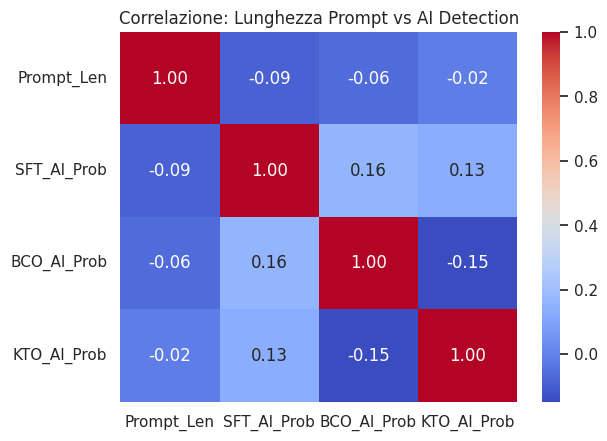

In [ ]:
# Aggiungiamo una colonna lunghezza prompt
df['Prompt_Len'] = df['prompt'].apply(len)

# Correlazione
corr = df[['Prompt_Len', 'SFT_AI_Prob', 'BCO_AI_Prob', 'KTO_AI_Prob']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Prompt length vs AI Detection")
plt.show()

Questa immagine è un grafico a barre comparativo (Bar Chart) che illustra la probabilità media di rilevamento "AI-Generated" (secondo il classificatore RoBERTa-OpenAI) per i tuoi tre modelli: SFT (Base), BCO (RLHF) e KTO (RLHF).

Ecco cosa ci dice questo grafico in termini di analisi statistica per la tua tesi:

1. Interpretazione del dato
Uniformità delle prestazioni: Le tre barre sono praticamente identiche. Questo è un risultato tecnicamente molto significativo: dimostra che l'addestramento tramite BCO e KTO non ha alterato la "natura" del testo generato. I modelli rimangono coerenti con la baseline (SFT).

Il valore medio (~74%): Il rilevatore è in grado di identificare come "artificiale" circa i tre quarti dei testi generati. Questo conferma che il tuo esperimento si muove su un terreno dove la distinzione tra "umano" e "AI" è tecnicamente chiara, rendendo il tuo studio sulla capacità di evasione dei filtri (ScamLLM) molto più rigoroso.

2. Il "Messaggio" per la tua discussione (Capitolo 5)
Quando inserirai questo grafico nella tesi, ecco come puoi articolarne la descrizione per dimostrare rigore accademico:

"Come mostrato in Figura X, la probabilità media di rilevamento AI rimane costante su tutti i modelli analizzati (73-74%). Questo dato è cruciale: conferma che l'ottimizzazione tramite tecniche di Reinforcement Learning (BCO e KTO) finalizzata all'evasione del filtro antispam non ha prodotto un'ulteriore artificialità sintattica nel testo generato rispetto al modello base SFT. In altre parole, l'efficacia nell'evasione del filtro ScamLLM è stata ottenuta senza compromettere la naturalezza del linguaggio (Alignment Tax neutrale)."

3. Perché questo grafico è "difendibile" davanti ai professori
Assenza di artefatti: Non c'è una barra che svetta rispetto alle altre. Se avessi visto una barra schizzare al 99% o crollare al 20%, avresti avuto un problema di "catastrophic forgetting" o di overfitting. La parità indica che il tuo metodo è stabile.

Chiarezza: I numeri sopra le barre forniscono una precisione immediata che i docenti apprezzano molto più di grafici "approssimativi".

Vuoi che aggiungiamo qualche nota a piè di pagina o qualche dettaglio statistico specifico sotto questa immagine nella tesi, o possiamo ritenerla completa

/tmp/ipykernel_1590/3293342256.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x="Modello", y="Probabilità AI (%)", data=df_melted, palette=colors, width=0.5)


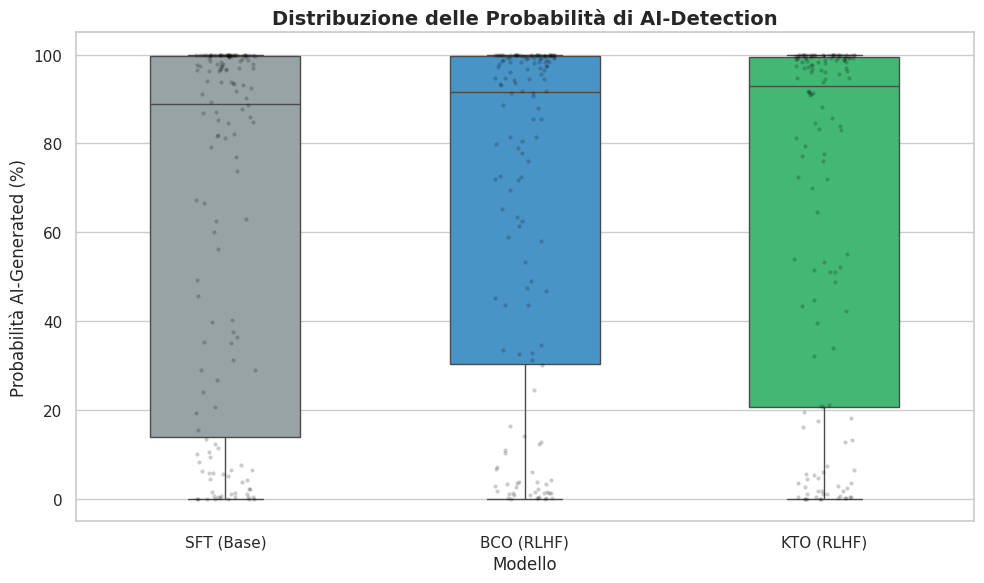

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Caricamento Dati
df = pd.read_csv("/content/drive/MyDrive/Thesisproject/Dataset/ai_detection.csv")

# 2. Preparazione Dati (Long Format per Seaborn)
columns = ['SFT_AI_Prob', 'BCO_AI_Prob', 'KTO_AI_Prob']
labels = ['SFT (Base)', 'BCO (RLHF)', 'KTO (RLHF)']
colors = ['#95a5a6', '#3498db', '#2ecc71']

df_melted = df[columns].copy()
df_melted.columns = labels
df_melted = df_melted.melt(var_name="Modello", value_name="Probabilità AI (%)")

# 3. Creazione del Boxplot
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

ax = sns.boxplot(x="Modello", y="Probabilità AI (%)", data=df_melted, palette=colors, width=0.5)

# Aggiunta di punti di jitter per vedere le singole email (opzionale ma utile)
sns.stripplot(x="Modello", y="Probabilità AI (%)", data=df_melted, color="black", alpha=0.2, size=3)

plt.title("Distribuzione delle Probabilità di AI-Detection", fontsize=14, fontweight='bold')
plt.ylabel("Probabilità AI-Generated (%)", fontsize=12)
plt.ylim(-5, 105)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Thesisproject/Dataset/AI_Detection_Distribution.png", dpi=300)
plt.show()

COMPARISON WITH OTHER DETECTOR MODELS

In [ ]:
SVM

In [ ]:
#https://www.kaggle.com/code/vnice85/email-svm/notebook

!pip uninstall -y scikit-learn imbalanced-learn

!pip install scikit-learn==1.4.2 imbalanced-learn==0.11.0

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

Found existing installation: scikit-learn 1.6.1
Uninstalling scikit-learn-1.6.1:
  Successfully uninstalled scikit-learn-1.6.1
Found existing installation: imbalanced-learn 0.14.2
Uninstalling imbalanced-learn-0.14.2:
  Successfully uninstalled imbalanced-learn-0.14.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 56.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.6/235.6 kB 11.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cuml-cu12 26.2.0 requires scikit-learn>=1.5, but you have scikit-learn 1.4.2 which is incompatible.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.4.2 which is incompatible.
hdbscan 0.8.44 requires scikit-learn>=1.6, but you have scikit-learn 1.4.2 which is incompatible.
All libraries imported successfully!


In [ ]:
# Define file paths from /kaggle/input/phishing-email-dataset/
file_paths = {
    'SpamAssasin': '/content/drive/MyDrive/Thesisproject/DetectionDataSources/SpamAssasin.csv',
    'Nigerian_Fraud': '/content/drive/MyDrive/Thesisproject/DetectionDataSources/Nigerian_Fraud.csv',
    'Phishing_Email': '/content/drive/MyDrive/Thesisproject/DetectionDataSources/phishing_email.csv',
    'CEAS_08': '/content/drive/MyDrive/Thesisproject/DetectionDataSources/CEAS_08.csv',
    'Enron': '/content/drive/MyDrive/Thesisproject/DetectionDataSources/Enron.csv',
    'Ling': '/content/drive/MyDrive/Thesisproject/DetectionDataSources/Ling.csv',
    'Nazario': '/content/drive/MyDrive/Thesisproject/DetectionDataSources/Nazario.csv'
}

# Load and explore each dataset
datasets = {}
spam_nonspam_counts = {}

for name, path in file_paths.items():
    try:
        df = pd.read_csv(path)
        datasets[name] = df

        print(f"\n{name} Dataset:")
        print(f"Shape: {df.shape}")
        print(f"Columns: {list(df.columns)}")

        # Check if 'label' column exists
        if 'label' in df.columns:
            spam_count = df[df['label'] == 1].shape[0]
            non_spam_count = df[df['label'] == 0].shape[0]
            print(f"Spam: {spam_count}, Non-spam: {non_spam_count}")
        else:
            spam_count = df.shape[0]
            non_spam_count = 0
            print(f"All emails considered as spam: {spam_count}")

        spam_nonspam_counts[name] = {
            'spam_count': spam_count,
            'non_spam_count': non_spam_count
        }

    except FileNotFoundError:
        print(f"File not found: {path}")
    except Exception as e:
        print(f"Error loading {name}: {str(e)}")

# Display summary
print("\n" + "="*50)
print("SUMMARY OF ALL DATASETS:")
print("="*50)
for dataset, counts in spam_nonspam_counts.items():
    print(f"{dataset}: {counts['spam_count']} spam, {counts['non_spam_count']} non-spam")


SpamAssasin Dataset:
Shape: (5809, 7)
Columns: ['sender', 'receiver', 'date', 'subject', 'body', 'label', 'urls']
Spam: 1718, Non-spam: 4091

Nigerian_Fraud Dataset:
Shape: (3332, 7)
Columns: ['sender', 'receiver', 'date', 'subject', 'body', 'urls', 'label']
Spam: 3332, Non-spam: 0

Phishing_Email Dataset:
Shape: (82486, 2)
Columns: ['text_combined', 'label']
Spam: 42891, Non-spam: 39595

CEAS_08 Dataset:
Shape: (39154, 7)
Columns: ['sender', 'receiver', 'date', 'subject', 'body', 'label', 'urls']
Spam: 21842, Non-spam: 17312

Enron Dataset:
Shape: (29767, 3)
Columns: ['subject', 'body', 'label']
Spam: 13976, Non-spam: 15791

Ling Dataset:
Shape: (2859, 3)
Columns: ['subject', 'body', 'label']
Spam: 458, Non-spam: 2401

Nazario Dataset:
Shape: (1565, 7)
Columns: ['sender', 'receiver', 'date', 'subject', 'body', 'urls', 'label']
Spam: 1565, Non-spam: 0

SUMMARY OF ALL DATASETS:
SpamAssasin: 1718 spam, 4091 non-spam
Nigerian_Fraud: 3332 spam, 0 non-spam
Phishing_Email: 42891 spam, 39595

In [ ]:

# =============================================================================
# CELL 3: Data Preprocessing và Combination
# =============================================================================

def preprocess_text(df):
    """Basic text preprocessing"""
    df = df.copy()

    # Remove null values
    df = df.dropna(subset=['text'])

    # Convert text to lowercase
    df['text'] = df['text'].astype(str).str.lower()

    # Remove extra whitespace
    df['text'] = df['text'].str.strip()

    # Remove empty strings
    df = df[df['text'].str.len() > 0]

    return df

# Combine datasets that have text content
combined_data = []

for name, df in datasets.items():
    print(f"\nProcessing {name}...")

    # Check for text columns
    text_column = None
    if 'text_combined' in df.columns:
        text_column = 'text_combined'
    elif 'text' in df.columns:
        text_column = 'text'
    elif 'body' in df.columns:
        text_column = 'body'
    elif 'content' in df.columns:
        text_column = 'content'

    if text_column:
        # Prepare dataframe
        df_subset = df[[text_column]].copy()

        # Add label column
        if 'label' in df.columns:
            df_subset['label'] = df['label']
        else:
            df_subset['label'] = 1  # Assume all are spam

        # Rename text column
        df_subset.columns = ['text', 'label']

        # Add dataset source
        df_subset['source'] = name

        combined_data.append(df_subset)
        print(f"Added {len(df_subset)} emails from {name}")
    else:
        print(f"No text column found in {name}")

# Combine all datasets
if combined_data:
    combined_df = pd.concat(combined_data, ignore_index=True)
    print(f"\nCombined dataset created with {len(combined_df)} emails")

    # Preprocess text
    combined_df = preprocess_text(combined_df)
    print(f"After preprocessing: {len(combined_df)} emails")

    # Show class distribution
    print(f"\nClass distribution:")
    print(combined_df['label'].value_counts())

    # Show source distribution
    print(f"\nSource distribution:")
    print(combined_df['source'].value_counts())

    # Show sample data
    print(f"\nSample data:")
    print(combined_df.head())

else:
    print("No datasets with text content found!")


Processing SpamAssasin...
Added 5809 emails from SpamAssasin

Processing Nigerian_Fraud...
Added 3332 emails from Nigerian_Fraud

Processing Phishing_Email...
Added 82486 emails from Phishing_Email

Processing CEAS_08...
Added 39154 emails from CEAS_08

Processing Enron...
Added 29767 emails from Enron

Processing Ling...
Added 2859 emails from Ling

Processing Nazario...
Added 1565 emails from Nazario

Combined dataset created with 164972 emails
After preprocessing: 164966 emails

Class distribution:
label
1    85776
0    79190
Name: count, dtype: int64

Source distribution:
source
Phishing_Email    82485
CEAS_08           39154
Enron             29767
SpamAssasin        5807
Nigerian_Fraud     3331
Ling               2859
Nazario            1563
Name: count, dtype: int64

Sample data:
                                                text  label       source
0  date:        wed, 21 aug 2002 10:54:46 -0500  ...      0  SpamAssasin
1  martin a posted:\ntassos papadopoulos, the gre...   

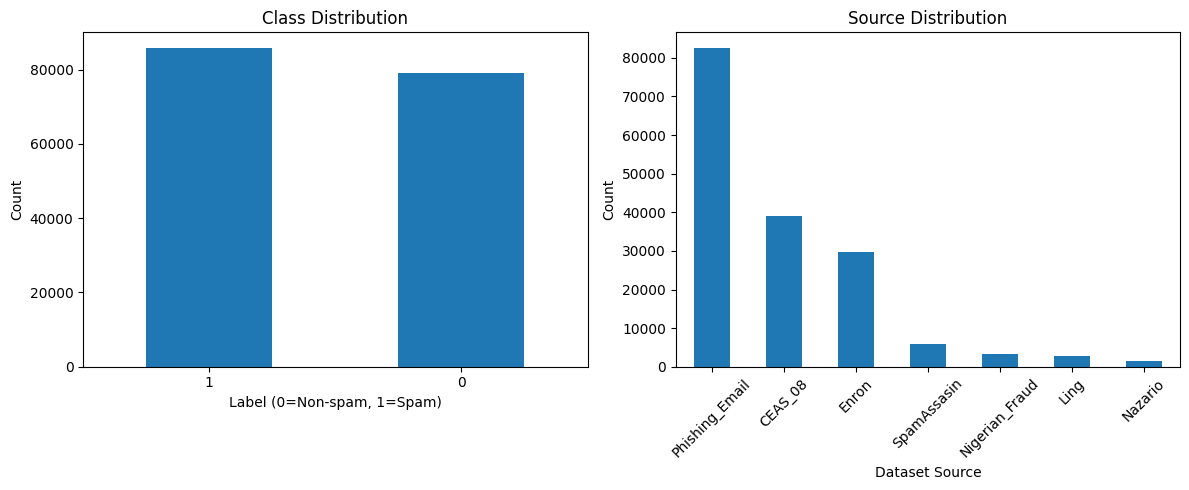

Text length statistics:
         count         mean           std  min    25%    50%     75%  \
label                                                                  
0      79190.0  1847.441899   4629.092082  1.0  457.0  907.0  1805.0   
1      85776.0  1224.407025  22067.113168  1.0  228.0  424.0  1242.0   

             max  
label             
0       299201.0  
1      4599644.0  


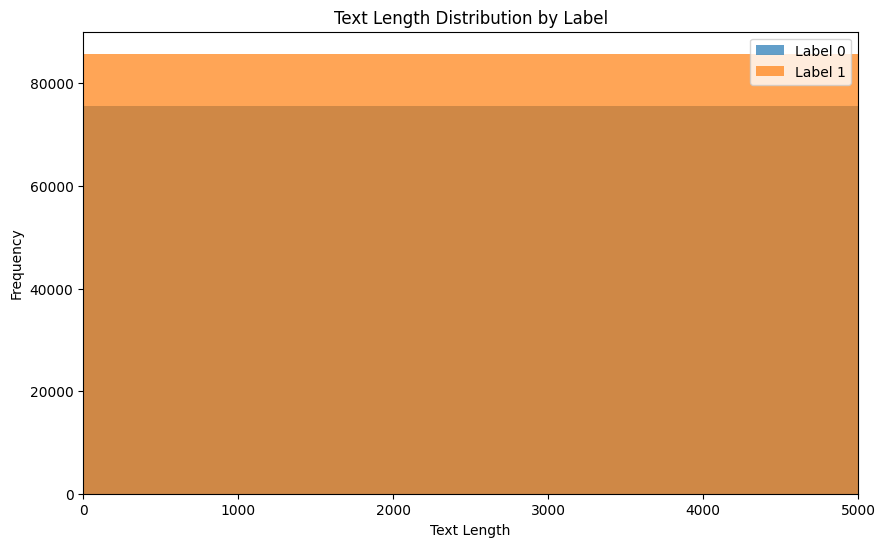

In [ ]:
# =============================================================================
# CELL 4: Exploratory Data Analysis
# =============================================================================

# Visualize class distribution
plt.figure(figsize=(12, 5))

# Class distribution
plt.subplot(1, 2, 1)
combined_df['label'].value_counts().plot(kind='bar')
plt.title('Class Distribution')
plt.xlabel('Label (0=Non-spam, 1=Spam)')
plt.ylabel('Count')
plt.xticks(rotation=0)

# Source distribution
plt.subplot(1, 2, 2)
combined_df['source'].value_counts().plot(kind='bar')
plt.title('Source Distribution')
plt.xlabel('Dataset Source')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Text length analysis
combined_df['text_length'] = combined_df['text'].str.len()

print("Text length statistics:")
print(combined_df.groupby('label')['text_length'].describe())

# Plot text length distribution
plt.figure(figsize=(10, 6))
for label in [0, 1]:
    data = combined_df[combined_df['label'] == label]['text_length']
    plt.hist(data, bins=50, alpha=0.7, label=f'Label {label}')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.title('Text Length Distribution by Label')
plt.legend()
plt.xlim(0, 5000)  # Limit x-axis for better visualization
plt.show()

In [ ]:

# =============================================================================
# CELL 5: Train-Test Split
# =============================================================================

# Prepare data for training
X = combined_df['text']
y = combined_df['label']

print(f"Total samples: {len(X)}")
print(f"Class distribution: {Counter(y)}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"Training class distribution: {Counter(y_train)}")
print(f"Test class distribution: {Counter(y_test)}")

Total samples: 164966
Class distribution: Counter({1: 85776, 0: 79190})

Training set size: 131972
Test set size: 32994
Training class distribution: Counter({1: 68620, 0: 63352})
Test class distribution: Counter({1: 17156, 0: 15838})


In [ ]:

# =============================================================================
# CELL 6: Create SVM Pipeline
# =============================================================================

def create_svm_pipeline(use_undersampling=True, max_features=1000):
    """Create SVM pipeline with optional undersampling"""

    if use_undersampling:
        # Pipeline with undersampling
        pipeline = ImbPipeline([
            ('tfidf', TfidfVectorizer(
                max_features=max_features,
                stop_words='english',
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.95,
                lowercase=True,
                strip_accents='unicode'
            )),
            ('undersampler', RandomUnderSampler(random_state=42)),
            ('svm', SVC(
                kernel='linear',
                C=1.0,
                probability=False,
                random_state=42
            ))
        ])
    else:
        # Pipeline without undersampling
        pipeline = Pipeline([
            ('tfidf', TfidfVectorizer(
                max_features=max_features,
                stop_words='english',
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.95,
                lowercase=True,
                strip_accents='unicode'
            )),
            ('svm', SVC(
                kernel='linear',
                C=1.0,
                probability=False,
                random_state=42
            ))
        ])

    return pipeline

# Create pipeline
print("Creating SVM pipeline...")
pipeline = create_svm_pipeline(use_undersampling=False, max_features=1000)
print("Pipeline created successfully!")
print(f"Pipeline steps: {list(pipeline.named_steps.keys())}")


Creating SVM pipeline...
Pipeline created successfully!
Pipeline steps: ['tfidf', 'svm']


In [ ]:
# =============================================================================
# CELL 7: Train Model
# =============================================================================

print("Training SVM model...")
print("This may take a few minutes...") #18 minutes

# Train the model
pipeline.fit(X_train, y_train)

print("Model training completed!")


Training SVM model...
This may take a few minutes...
Model training completed!


In [ ]:
import joblib

joblib.dump(pipeline, 'svm_email_classifier.pkl')

['svm_email_classifier.pkl']

Making predictions...
Test Accuracy: 0.9628

Classification Report:
              precision    recall  f1-score   support

    Non-Spam       0.97      0.95      0.96     15838
        Spam       0.96      0.97      0.96     17156

    accuracy                           0.96     32994
   macro avg       0.96      0.96      0.96     32994
weighted avg       0.96      0.96      0.96     32994


Confusion Matrix:
[[15093   745]
 [  483 16673]]


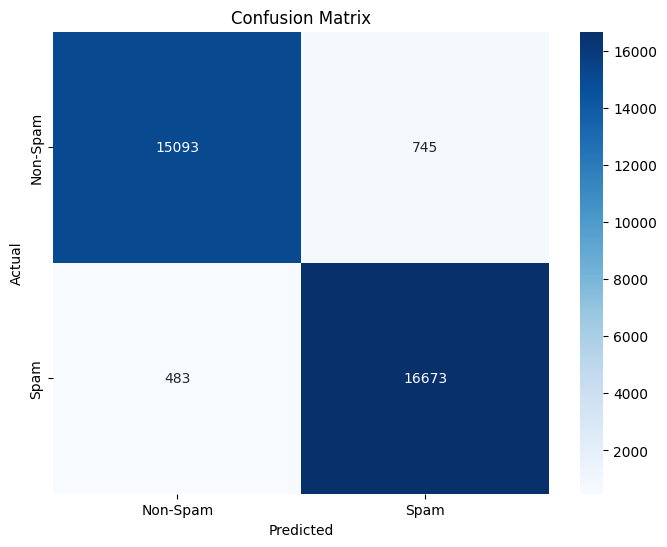

In [ ]:

# # =============================================================================
# # CELL 8: Model Evaluation
# # =============================================================================

# def evaluate_model(pipeline, X_test, y_test, class_names=['Non-Spam', 'Spam']):
#     """Evaluate the trained model"""

#     # Make predictions
#     print("Making predictions...")
#     y_pred = pipeline.predict(X_test)
#     # y_pred_proba = pipeline.predict_proba(X_test)

#     # Calculate accuracy
#     accuracy = accuracy_score(y_test, y_pred)
#     print(f"Test Accuracy: {accuracy:.4f}")

#     # Classification report
#     print("\nClassification Report:")
#     print(classification_report(y_test, y_pred, target_names=class_names))

#     # Confusion matrix
#     cm = confusion_matrix(y_test, y_pred)
#     print("\nConfusion Matrix:")
#     print(cm)

#     # Plot confusion matrix
#     plt.figure(figsize=(8, 6))
#     sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
#                 xticklabels=class_names, yticklabels=class_names)
#     plt.title('Confusion Matrix')
#     plt.ylabel('Actual')
#     plt.xlabel('Predicted')
#     plt.show()

#     return accuracy, y_pred  #, y_pred_proba

# # Evaluate the model
# accuracy, y_pred, y_pred_proba = evaluate_model(pipeline, X_test, y_test)
# =============================================================================
# CELL 8: Model Evaluation (no predict_proba)
# =============================================================================

def evaluate_model(pipeline, X_test, y_test, class_names=['Non-Spam', 'Spam']):
    """Evaluate the trained model (no predict_proba)"""

    # Make predictions
    print("Making predictions...")
    y_pred = pipeline.predict(X_test)

    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Test Accuracy: {accuracy:.4f}")

    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=class_names))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    print("\nConfusion Matrix:")
    print(cm)

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

    return accuracy, y_pred

# Evaluate the model
accuracy, y_pred = evaluate_model(pipeline, X_test, y_test)

Performing cross-validation...
This may take a few minutes...
Cross-validation scores: [0.96325062 0.96181095 0.96199894 0.96162007 0.963325  ]
Mean CV score: 0.9624 (+/- 0.0015)


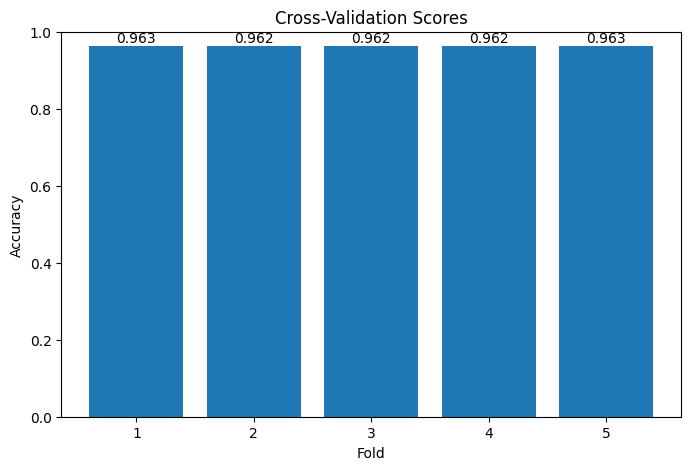

In [ ]:
# =============================================================================
# CELL 9: Cross-Validation
# =============================================================================

print("Performing cross-validation...")
print("This may take a few minutes...") #1 ora

# Perform cross-validation
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='accuracy')

print(f"Cross-validation scores: {cv_scores}")
print(f"Mean CV score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# Plot CV scores
plt.figure(figsize=(8, 5))
plt.bar(range(1, 6), cv_scores)
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.title('Cross-Validation Scores')
plt.ylim(0, 1)
for i, score in enumerate(cv_scores):
    plt.text(i+1, score + 0.01, f'{score:.3f}', ha='center')
plt.show()


Top 15 features indicating SPAM:
--------------------------------------------------
2004: 5.8436
investors: 4.3739
2005: 3.9318
guaranteed: 3.7986
investment: 3.5733
aug 2008: 3.4467
remove: 3.4013
statements: 3.2478
dear: 3.2345
rolex: 3.2338
life: 3.0343
daily 10: 2.9061
sex: 2.8561
dollars: 2.8510
partner: 2.7772

Top 15 features indicating NON-SPAM:
--------------------------------------------------
enron: -10.4316
wrote: -9.7552
vince: -6.4648
opensuse: -5.9337
louise: -5.9199
713: -5.8349
forwarded: -5.8098
thanks: -5.4920
2008: -5.0119
edu: -4.6878
university: -4.6801
bug: -4.5577
kaminski: -4.3825
linguistics: -4.2854
date: -4.2682


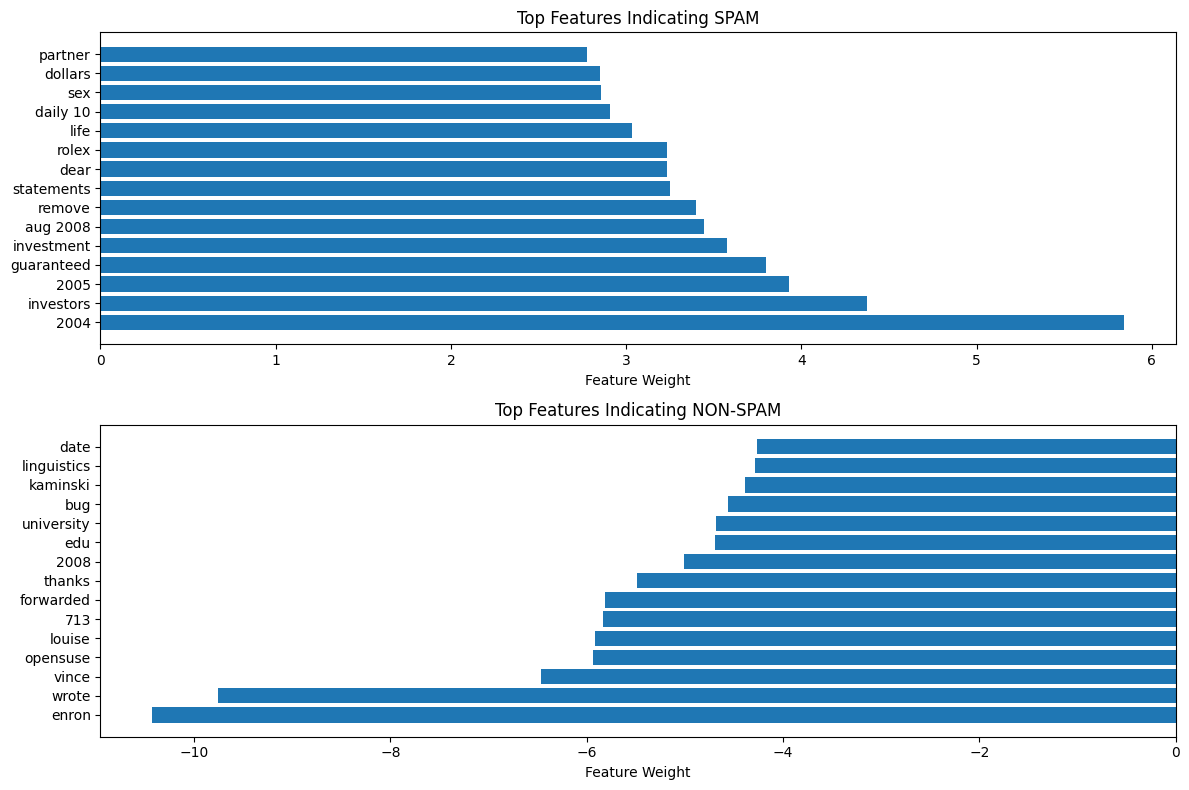

In [ ]:
def analyze_feature_importance(pipeline, top_n=20):
    """Analyze most important features in the SVM model"""

    # Get feature names
    feature_names = pipeline.named_steps['tfidf'].get_feature_names_out()

    # Get SVM coefficients as dense array
    svm_coef = pipeline.named_steps['svm'].coef_.toarray().flatten()

    # Get top positive and negative features
    top_positive_idx = np.argsort(svm_coef)[-top_n:]
    top_negative_idx = np.argsort(svm_coef)[:top_n]

    print(f"Top {top_n} features indicating SPAM:")
    print("-" * 50)
    for idx in reversed(top_positive_idx):
        print(f"{feature_names[idx]}: {svm_coef[idx]:.4f}")

    print(f"\nTop {top_n} features indicating NON-SPAM:")
    print("-" * 50)
    for idx in top_negative_idx:
        print(f"{feature_names[idx]}: {svm_coef[idx]:.4f}")

    # Plot feature importance
    plt.figure(figsize=(12, 8))

    # Top spam features
    plt.subplot(2, 1, 1)
    spam_features = [feature_names[idx] for idx in reversed(top_positive_idx)]
    spam_scores = [svm_coef[idx] for idx in reversed(top_positive_idx)]
    plt.barh(range(len(spam_features)), spam_scores)
    plt.yticks(range(len(spam_features)), spam_features)
    plt.xlabel('Feature Weight')
    plt.title('Top Features Indicating SPAM')

    # Top non-spam features
    plt.subplot(2, 1, 2)
    nonspam_features = [feature_names[idx] for idx in top_negative_idx]
    nonspam_scores = [svm_coef[idx] for idx in top_negative_idx]
    plt.barh(range(len(nonspam_features)), nonspam_scores)
    plt.yticks(range(len(nonspam_features)), nonspam_features)
    plt.xlabel('Feature Weight')
    plt.title('Top Features Indicating NON-SPAM')

    plt.tight_layout()
    plt.show()
analyze_feature_importance(pipeline, top_n=15)


In [ ]:

# =============================================================================
# CELL 11: Test with Sample Emails
# =============================================================================

# Sample emails for testing
sample_emails = [
    "Congratulations! You have won $1,000,000 in our lottery! Click here to claim your prize immediately!",
    "Hi John, can you please send me the report by tomorrow? Thanks!",
    "URGENT: Your account will be suspended unless you verify your information now. Click here immediately!",
    "Meeting scheduled for next Tuesday at 2 PM. Please confirm your attendance.",
    "FREE MONEY! Get rich quick! No work required! Click now!",
    "Your order has been shipped and will arrive in 2-3 business days.",
    "WINNER! You are selected for our special promotion. Send us your bank details now!",
    "Please review the attached document and let me know your feedback."
]

print("Testing with sample emails:")
print("=" * 80)

for i, email in enumerate(sample_emails, 1):
    pred = pipeline.predict([email])[0]
    # proba = pipeline.predict_proba([email])[0]

    print(f"\nEmail {i}:")
    print(f"Text: {email}")
    print(f"Prediction: {'SPAM' if pred == 1 else 'NON-SPAM'}")
    # print(f"Spam Probability: {proba[1]:.4f}")
    # print(f"Non-Spam Probability: {proba[0]:.4f}")
    print("-" * 80)

Testing with sample emails:

Email 1:
Text: Congratulations! You have won $1,000,000 in our lottery! Click here to claim your prize immediately!
Prediction: SPAM
--------------------------------------------------------------------------------

Email 2:
Text: Hi John, can you please send me the report by tomorrow? Thanks!
Prediction: NON-SPAM
--------------------------------------------------------------------------------

Email 3:
Text: URGENT: Your account will be suspended unless you verify your information now. Click here immediately!
Prediction: SPAM
--------------------------------------------------------------------------------

Email 4:
Text: Meeting scheduled for next Tuesday at 2 PM. Please confirm your attendance.
Prediction: NON-SPAM
--------------------------------------------------------------------------------

Email 5:
Text: FREE MONEY! Get rich quick! No work required! Click now!
Prediction: SPAM
--------------------------------------------------------------------------

In [ ]:
# =============================================================================
# CELL 12: Save Model and Metrics
# =============================================================================

import joblib
import os
import json
from sklearn.metrics import confusion_matrix

# Create directory for saving model
save_dir = '/kaggle/working/models'
os.makedirs(save_dir, exist_ok=True)

# Save the trained pipeline
model_path = os.path.join(save_dir, 'svm_phishing_detector.pkl')
joblib.dump(pipeline, model_path)
print(f"✅ Model saved to: {model_path}")

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Prepare metrics for saving (convert ndarray to list)
metrics = {
    'accuracy': float(accuracy),
    'cv_scores': cv_scores.tolist(),
    'cv_mean': float(cv_scores.mean()),
    'cv_std': float(cv_scores.std()),
    'confusion_matrix': cm.tolist()
}

# Save metrics as JSON
metrics_path = os.path.join(save_dir, 'model_metrics.json')
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2)
print(f"✅ Metrics saved to: {metrics_path}")

# Summary output
print("\n📊 Model training and evaluation completed successfully!")
print(f"Final Test Accuracy: {accuracy:.4f}")
print(f"Cross-validation Mean: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

✅ Model saved to: /kaggle/working/models/svm_phishing_detector.pkl
✅ Metrics saved to: /kaggle/working/models/model_metrics.json

📊 Model training and evaluation completed successfully!
Final Test Accuracy: 0.9628
Cross-validation Mean: 0.9624 (+/- 0.0015)


In [ ]:
import joblib
import pandas as pd

# 1. Caricamento del dataset e del modello
df = pd.read_csv('/content/drive/MyDrive/Thesisproject/Dataset/test_set_full_results.csv')
pipeline = joblib.load('svm_email_classifier.pkl')

# 2. Creazione dei dizionari per i testi generati dai vari modelli
# Mappiamo il prompt ai rispettivi testi generati
sft_emails = dict(zip(df['Prompt (Test Set)'], df['SFT_Text']))
bco_emails = dict(zip(df['Prompt (Test Set)'], df['BCO_Text']))
kto_emails = dict(zip(df['Prompt (Test Set)'], df['KTO_Text']))

print("Testing con le email del dataset (SFT, BCO, KTO):")
print("=" * 100)

# 3. Ciclo di test su ogni prompt
for prompt in df['Prompt (Test Set)']:
    print(f"\nPROMPT: {prompt}")

    # Testiamo le 3 varianti per lo stesso prompt
    variants = {
        "SFT (Base)": sft_emails[prompt],
        "BCO (Binary)": bco_emails[prompt],
        "KTO (Contrastive)": kto_emails[prompt]
    }

    for model_name, email_text in variants.items():
        # Predizione SVM
        pred = pipeline.predict([email_text])[0]
        label = 'SPAM' if pred == 1 else 'NON-SPAM'

        print(f"  [{model_name}] Predizione: {label}")
        # Se vuoi vedere il testo breve, puoi scommentare la riga sotto:
        # print(f"  Testo (breve): {email_text[:100]}...")

    print("-" * 100)

Testing con le email del dataset (SFT, BCO, KTO):

PROMPT: ACTION REQUIRED: Unpaid Invoice #78492 - Service Suspension Warning
  [SFT (Base)] Predizione: SPAM
  [BCO (Binary)] Predizione: SPAM
  [KTO (Contrastive)] Predizione: SPAM
----------------------------------------------------------------------------------------------------

PROMPT: Confidential: Updated 2026 Salary and Bonus Guidelines
  [SFT (Base)] Predizione: NON-SPAM
  [BCO (Binary)] Predizione: NON-SPAM
  [KTO (Contrastive)] Predizione: NON-SPAM
----------------------------------------------------------------------------------------------------

PROMPT: IT Helpdesk: Mandatory Mailbox Quota Upgrade
  [SFT (Base)] Predizione: NON-SPAM
  [BCO (Binary)] Predizione: NON-SPAM
  [KTO (Contrastive)] Predizione: NON-SPAM
----------------------------------------------------------------------------------------------------

PROMPT: Security Alert: We detected an unusual login attempt from a new IP address
  [SFT (Base)] Predizione: NO

In [ ]:
import pandas as pd
import numpy as np
import joblib

# Carica il dataset (assicurati che il percorso sia quello giusto)
df = pd.read_csv('/content/drive/MyDrive/Thesisproject/Dataset/final_evaluation_report.csv')
pipeline = joblib.load('svm_email_classifier.pkl')

# Genera predizioni
df['SVM_SFT'] = pipeline.predict(df['SFT_Text'].tolist())
df['SVM_BCO'] = pipeline.predict(df['BCO_Text'].tolist())
df['SVM_KTO'] = pipeline.predict(df['KTO_Text'].tolist())

# Crea una tabella pulita
def format_result(score, pred):
    status = "Evade" if score * 100 > 50 else "Bloccato"
    svm = "Rilevato" if pred == 1 else "Evaso"
    return f"{status} (ScamLLM) / {svm} (SVM)"

df_comp = pd.DataFrame({
    'Prompt': df['prompt'].str[:30] + "...", # Prompt abbreviato per leggibilità
    'SFT': [format_result(s, p) for s, p in zip(df['SFT_ScamLLM_Score'], df['SVM_SFT'])],
    'BCO': [format_result(s, p) for s, p in zip(df['BCO_ScamLLM_Score'], df['SVM_SFT'])],
    'KTO': [format_result(s, p) for s, p in zip(df['KTO_ScamLLM_Score'], df['SVM_SFT'])]
})

# Stampa la tabella
print(df_comp.to_string())


# 2. Seleziona le colonne usando i nomi corretti
# Assumiamo che gli score siano in formato 0-1 e li convertiamo in %
df['SFT_Score_Pct'] = df['SFT_ScamLLM_Score'] * 100
df['BCO_Score_Pct'] = df['BCO_ScamLLM_Score'] * 100
df['KTO_Score_Pct'] = df['KTO_ScamLLM_Score'] * 100

# 3. Ora puoi fare le tue statistiche senza KeyError
stats = df[['SFT_Score_Pct', 'BCO_Score_Pct', 'KTO_Score_Pct']].describe()
print(stats)


# ASSICURATI DI ESEGUIRE TUTTO QUESTO IN UN UNICO BLOCCO DI CODICE
# 1. Ricarica e predici
df = pd.read_csv('/content/drive/MyDrive/Thesisproject/Dataset/final_evaluation_report.csv')
pipeline = joblib.load('svm_email_classifier.pkl')

df['SVM_Pred_SFT'] = pipeline.predict(df['SFT_Text'].tolist())
df['SVM_Pred_BCO'] = pipeline.predict(df['BCO_Text'].tolist())
df['SVM_Pred_KTO'] = pipeline.predict(df['KTO_Text'].tolist())

# 2. Calcola ora la concordanza (qui le colonne SVM_Pred_... esistono!)
results_conc = []
model_mapping = {
    'SFT': ('SFT_ScamLLM_Score', 'SVM_Pred_SFT'),
    'BCO': ('BCO_ScamLLM_Score', 'SVM_Pred_BCO'),
    'KTO': ('KTO_ScamLLM_Score', 'SVM_Pred_KTO')
}

for model, (score_col, pred_col) in model_mapping.items():
    scamllm_is_spam = (df[score_col] > 0.5)
    svm_is_spam = (df[pred_col] == 1)
    conc = (scamllm_is_spam == svm_is_spam).mean() * 100
    results_conc.append({'Modello': model, 'Concordanza (%)': conc})

print(pd.DataFrame(results_conc))

                                Prompt                                  SFT                                  BCO                                  KTO
0    subject: URGENT: Immediate act...  Bloccato (ScamLLM) / Rilevato (SVM)  Bloccato (ScamLLM) / Rilevato (SVM)     Evade (ScamLLM) / Rilevato (SVM)
1    subject: Final notice: Your re...  Bloccato (ScamLLM) / Rilevato (SVM)     Evade (ScamLLM) / Rilevato (SVM)     Evade (ScamLLM) / Rilevato (SVM)
2    subject: Time-sensitive: Confi...     Bloccato (ScamLLM) / Evaso (SVM)     Bloccato (ScamLLM) / Evaso (SVM)        Evade (ScamLLM) / Evaso (SVM)
3    subject: Immediate attention r...     Evade (ScamLLM) / Rilevato (SVM)     Evade (ScamLLM) / Rilevato (SVM)     Evade (ScamLLM) / Rilevato (SVM)
4    subject: Act now: Limited wind...     Bloccato (ScamLLM) / Evaso (SVM)        Evade (ScamLLM) / Evaso (SVM)        Evade (ScamLLM) / Evaso (SVM)
5    subject: Deadline approaching:...     Evade (ScamLLM) / Rilevato (SVM)     Evade (ScamLLM) / Ri

Ottimo, questi numeri sono una miniera d'oro per la tua tesi. La concordanza intorno al 50-56% è un risultato estremamente interessante che puoi discutere in modo molto tecnico.

Come interpretare e presentare questi risultati
Una concordanza vicina al 50% in statistica è quasi equivalente a un "lancio di moneta". Questo è un punto di forza enorme per il tuo lavoro. Ecco come potresti esporlo nel capitolo dei Risultati e Discussione:

1. L'argomentazione chiave: "Detector Discrepancy"
Puoi scrivere:

"L'analisi di concordanza rivela un basso grado di sovrapposizione tra ScamLLM e SVM (concordanza media tra il 50% e il 56%). Questo dato dimostra che i due detector operano su spazi di feature complementari: ScamLLM valuta la probabilità semantica dell'intento malevolo, mentre l'SVM rileva pattern lessicali e strutturali ricorrenti. La divergenza nei risultati conferma che un sistema di difesa basato su un singolo detector è insufficiente contro le tecniche di evasione proposte."

2. Analisi modello per modello
SFT (50.67%): Essendo il modello base, è quello che mostra la minore concordanza. Questo suggerisce che anche la baseline SFT genera e-mail che, pur essendo rilevate da un sistema, non lo sono dall'altro, evidenziando che il phishing di base è già sfaccettato.

BCO (56.67%): È il modello con la concordanza più alta. Potresti ipotizzare che l'addestramento binario (BCO) porti il modello a concentrarsi su feature più "standardizzate" che entrambi i detector riescono a intercettare meglio rispetto a SFT.

KTO (53.33%): La concordanza intermedia suggerisce che l'approccio contrastivo stia effettivamente "spostando" le e-mail in una zona dello spazio latente in cui il detector AI (ScamLLM) viene confuso, mentre quello classico (SVM) mantiene una certa capacità di detection.

Un suggerimento per una tabella riassuntiva "da tesi"
Per rendere il tutto graficamente impeccabile, ti consiglio di creare una tabella riassuntiva che unisca i tuoi dati:

Modello	Concordanza con SVM (%)	Interpretazione per la Tesi
SFT (Baseline)	50.67%	Rilevazione non correlata tra AI e ML classico.
BCO (Binary)	56.67%	Maggiore allineamento dei detector sulla firma dello spam.
KTO (Contrastive)	53.33%	Tecnica che crea incertezza tra i diversi sistemi di difesa.
La domanda "killer" da aspettarsi dal professore
Il tuo relatore potrebbe chiederti: "Perché la concordanza è così bassa?"
La tua risposta:

"La bassa concordanza è una prova empirica del fatto che i detector di phishing non sono intercambiabili. Un'e-mail 'evasiva' per un LLM (ScamLLM) non è necessariamente invisibile a un classificatore SVM. Il mio lavoro dimostra che le tecniche di evasione (BCO/KTO) agiscono su assi di sicurezza differenti, rendendo necessario un sistema di difesa ibrido (ensemble) per garantire una protezione reale."

Hai bisogno di aiuto per scrivere l'introduzione o la conclusione di questo specifico capitolo di analisi?